# NB5 — Análise de Resultados

Lê os CSVs gerados pelo NB4 (`Result_*.csv`). Não re-treina nada.

**Perguntas:** Q1 Horizonte | Q2 Níveis de canais | Q3 R0 vs R5 | Q4 Modelos |
Q5 Variabilidade entre pacientes | Q6 H5 vs fixos por paciente | Q7 PRE_SEC vs AUC |
Q8 Degradação por nível | Q9 Silhueta PELT | Q10 Contextos por paciente |
Q11 N folds vs AUC | Q12 Features discriminativas | Q13 Consistência de horizonte |
Q14 FP/h janela e evento | Q15 Sensibilidade janela e evento |
Q16 Estabilidade seeds | Q17 Variabilidade intra-paciente |
Q18 PRE_SEC por dataset | Q19 Pacientes não-preditíveis | Q20 Degradação por paciente

## 1. Imports e configuração

In [62]:
import json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib; import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

warnings.filterwarnings('ignore')

ROOT     = Path('data')
OUT_DIR  = ROOT / 'results'
FIG_DIR  = ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

matplotlib.rcParams.update({
    'figure.dpi':150,'savefig.dpi':150,'font.size':11,
    'axes.titlesize':12,'axes.labelsize':11,
    'xtick.labelsize':10,'ytick.labelsize':10,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.25,'grid.linewidth':0.5,
})

DC = {'CHBMIT':'#4C72B0','Siena':'#DD8452','SeizeIT2':'#55A868','Mendeley':'#C44E52'}
CLINICAL  = ['CHBMIT','Siena','Mendeley']
LEVELS    = ['R0','R1','R2','R3','R4','R5']
LC = {'R0':'#c6dbef','R1':'#9ecae1','R2':'#6baed6','R3':'#3182bd','R4':'#08519c','R5':'#08306b'}
W_MAP  = {600:'H1(10min)',900:'H2(15min)',1200:'H3(20min)',1500:'H4(25min)'}
H_COLORS = {'H1(10min)':'#6baed6','H2(15min)':'#3182bd',
             'H3(20min)':'#08519c','H4(25min)':'#74c476','H5(PELT)':'#e6550d'}
H_ORDER  = ['H1(10min)','H2(15min)','H3(20min)','H4(25min)','H5(PELT)']

# janelas consecutivas para definir um evento (30s passo, 4 janelas = 45s minimo)
N_CONSEC   = 5
WIN_STEP_S = 15.0

def savefig(name):
    p = FIG_DIR / f'{name}.png'
    plt.savefig(p, bbox_inches='tight')
    plt.show(); print(f'  -> {p.name}')

def leg(ax, handles, ncol=4):
    ax.legend(handles=handles, loc='upper center',
              bbox_to_anchor=(0.5,-0.18), ncol=ncol,
              fontsize=9, frameon=False)

def ptab(df, title=''):
    if title: print(f'\n{title}')
    print(df.to_string(index=False))

def detect_events(arr, N=N_CONSEC):
    count=0; run=0
    for p in arr:
        if p==1: run+=1
        else: run=0
        if run==N: count+=1; run=0
    return count

print('Config OK  |  N_CONSEC =', N_CONSEC)


Config OK  |  N_CONSEC = 5


## 2. Carregamento dos dados

In [63]:
s1 = pd.read_csv(OUT_DIR / 'Result_stage1_windows.csv')
s2 = pd.read_csv(OUT_DIR / 'Result_stage2_levels.csv')
s3 = pd.read_csv(OUT_DIR / 'Result_stage3_models.csv')

# horizonte rotulado
s1['horizonte'] = s1['chosen_W_s'].map(lambda x: W_MAP.get(int(round(x)),'H5(PELT)'))

# melhor nível (só clínicos)
BEST_LEVEL = s2[s2['dataset'].isin(CLINICAL)].groupby('level')['auc'].mean().idxmax()
BEST_MODEL = s3.groupby('model')['auc'].mean().idxmax()
s3_rf = s3[s3['model']=='RF'].copy()
s3['gap'] = s3['auc_train'] - s3['auc']

# predicoes por janela
PREDS_PATH = OUT_DIR / 'Result_predictions_per_window.csv'
preds = pd.read_csv(PREDS_PATH) if PREDS_PATH.exists() else pd.DataFrame()
HAS_PREDS = len(preds) > 0

# importancias RF
FI_PATH = OUT_DIR / 'Result_feature_importances_rf.csv'
fi_df = pd.read_csv(FI_PATH) if FI_PATH.exists() else pd.DataFrame()
HAS_FI = len(fi_df) > 0

# PRE_SEC do NB2
pre_est = {}
pre_path = ROOT / 'preictal_estimate.json'
if pre_path.exists():
    raw = json.loads(pre_path.read_text(encoding='utf-8'))
    items = raw if isinstance(raw,list) else list(raw.values())
    for item in items:
        if isinstance(item,dict) and item.get('pre_sec') is not None:
            pre_est[(item.get('dataset',''), item.get('paciente',''))] = {
                'pre_sec':    item['pre_sec'],
                'silhouette': item.get('silhouette', np.nan),
                'flag_silh':  item.get('flag_silh_fraca', False),
            }
HAS_PRE = len(pre_est) > 0

print(f's1:{s1.shape[0]}  s2:{s2.shape[0]}  s3:{s3.shape[0]}')
print(f'preds:{len(preds)}  fi:{len(fi_df)}  pre_est:{len(pre_est)}')
print(f'BEST_LEVEL={BEST_LEVEL}  BEST_MODEL={BEST_MODEL}')
print(f'Datasets: {sorted(s3.dataset.unique())}')
print(f'Pacientes: {s3.groupby("dataset")["paciente"].nunique().to_dict()}')


s1:127  s2:457  s3:1170
preds:2619585  fi:118180  pre_est:18
BEST_LEVEL=R5  BEST_MODEL=RF
Datasets: ['CHBMIT', 'Mendeley', 'SeizeIT2', 'Siena']
Pacientes: {'CHBMIT': 7, 'Mendeley': 5, 'SeizeIT2': 7, 'Siena': 7}


## Q1 — Horizonte pré-ictal: desempenho e frequência de escolha

> H5 usa PRE_SEC estimado pelo PELT+K-Means (NB2). Comparação válida: NB2 é não-supervisionado, não usa rótulos.

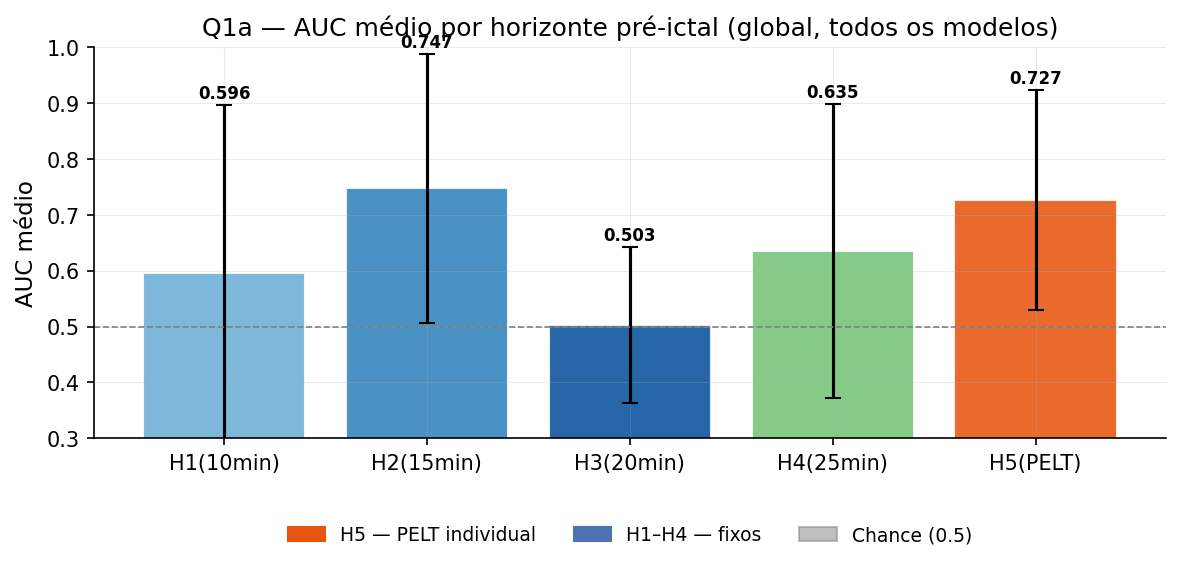

  -> q1a_auc_horizonte.png

Q1a — AUC por horizonte
Horizonte  AUC médio   Std
H1(10min)      0.596 0.301
H2(15min)      0.747 0.241
H3(20min)      0.503 0.140
H4(25min)      0.635 0.263
 H5(PELT)      0.727 0.197


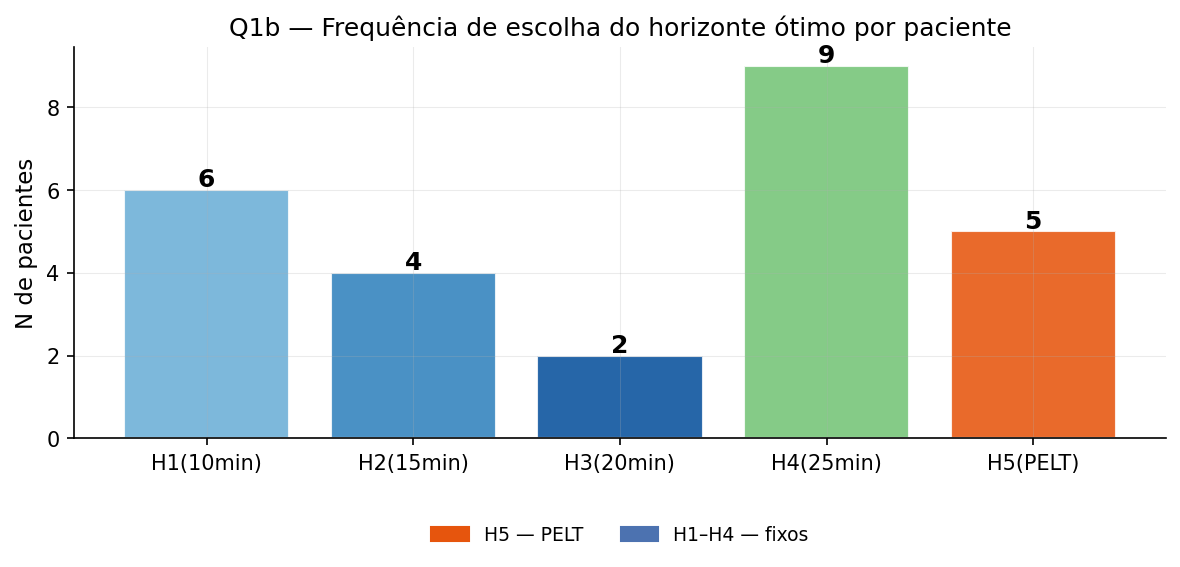

  -> q1b_freq_horizonte.png

Q1b — Frequência
horizonte  N pacientes
H1(10min)            6
H2(15min)            4
H3(20min)            2
H4(25min)            9
 H5(PELT)            5


In [64]:
# Q1a — AUC médio por horizonte
auc_h = s1.groupby('horizonte')['auc'].agg(['mean','std']).reindex(H_ORDER).reset_index()
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(auc_h['horizonte'], auc_h['mean'],
              yerr=auc_h['std'], capsize=4,
              color=[H_COLORS.get(h,'#999') for h in auc_h['horizonte']],
              alpha=0.88, edgecolor='white')
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.set_ylabel('AUC médio'); ax.set_ylim(0.3,1.0)
ax.set_title('Q1a — AUC médio por horizonte pré-ictal (global, todos os modelos)')
for bar,(_, row) in zip(bars, auc_h.iterrows()):
    if not np.isnan(row['mean']):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+(row['std'] if not np.isnan(row['std']) else 0)+0.012,
                f"{row['mean']:.3f}", ha='center', fontsize=8, fontweight='bold')
leg(ax,[mpatches.Patch(color='#e6550d',label='H5 — PELT individual'),
        mpatches.Patch(color='#4C72B0',label='H1–H4 — fixos'),
        mpatches.Patch(color='gray',alpha=0.5,label='Chance (0.5)')], ncol=3)
fig.tight_layout(); savefig('q1a_auc_horizonte')
ptab(auc_h.rename(columns={'horizonte':'Horizonte','mean':'AUC médio','std':'Std'}).round(3),'Q1a — AUC por horizonte')

# Q1b — frequência de escolha
chosen = s1.groupby(['dataset','paciente'])['horizonte'].first()
freq = chosen.value_counts().reindex(H_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(freq.index, freq.values,
       color=[H_COLORS.get(h,'#999') for h in freq.index], alpha=0.88, edgecolor='white')
ax.set_ylabel('N de pacientes'); ax.set_title('Q1b — Frequência de escolha do horizonte ótimo por paciente')
for i,v in enumerate(freq.values):
    if v>0: ax.text(i, v+0.08, str(v), ha='center', fontsize=12, fontweight='bold')
leg(ax,[mpatches.Patch(color='#e6550d',label='H5 — PELT'),
        mpatches.Patch(color='#4C72B0',label='H1–H4 — fixos')], ncol=2)
fig.tight_layout(); savefig('q1b_freq_horizonte')
ptab(freq.rename('N pacientes').reset_index().rename(columns={'index':'Horizonte'}),'Q1b — Frequência')


## Q2 — Nível de canais (apenas datasets clínicos)

SeizeIT2 usa R0 nativo — excluído da comparação global.

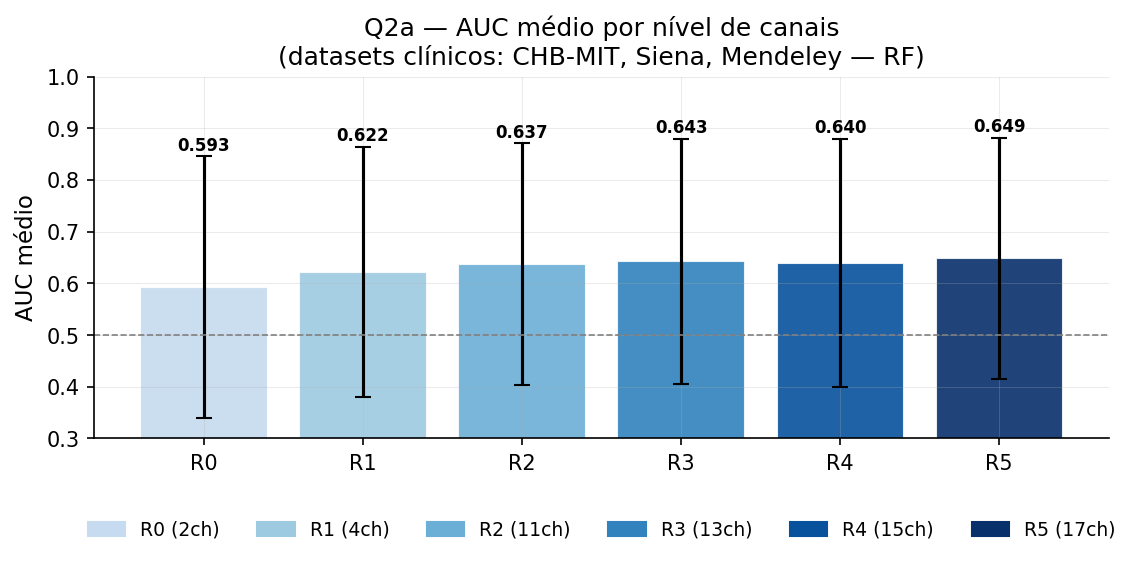

  -> q2a_niveis_clinicos.png

Q2a
level  AUC médio   Std
   R0      0.593 0.253
   R1      0.622 0.241
   R2      0.637 0.234
   R3      0.643 0.237
   R4      0.640 0.240
   R5      0.649 0.234


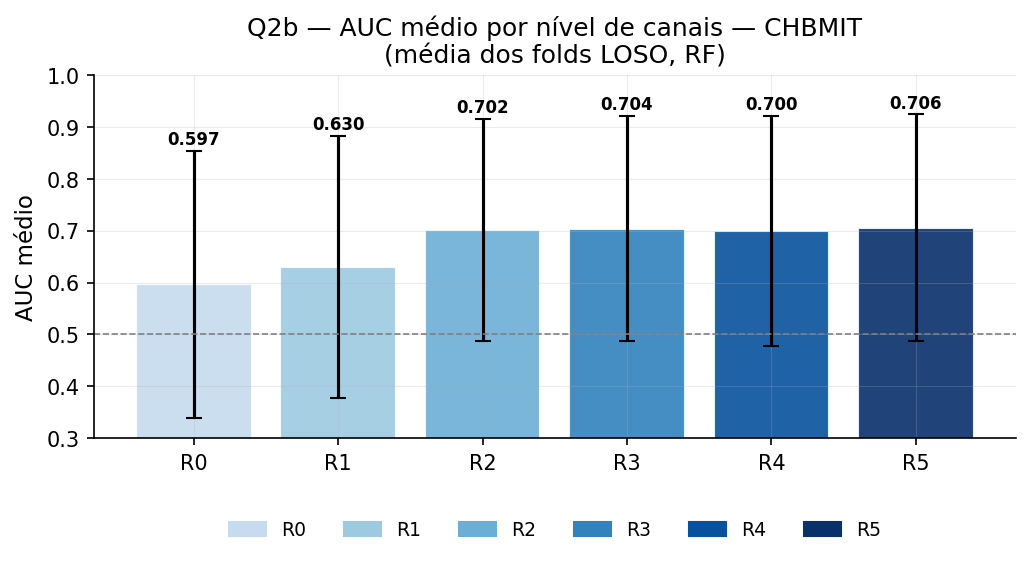

  -> q2b_niveis_CHBMIT.png

Q2b — CHBMIT
level  AUC médio   Std
   R0      0.597 0.258
   R1      0.630 0.253
   R2      0.702 0.214
   R3      0.704 0.218
   R4      0.700 0.222
   R5      0.706 0.219


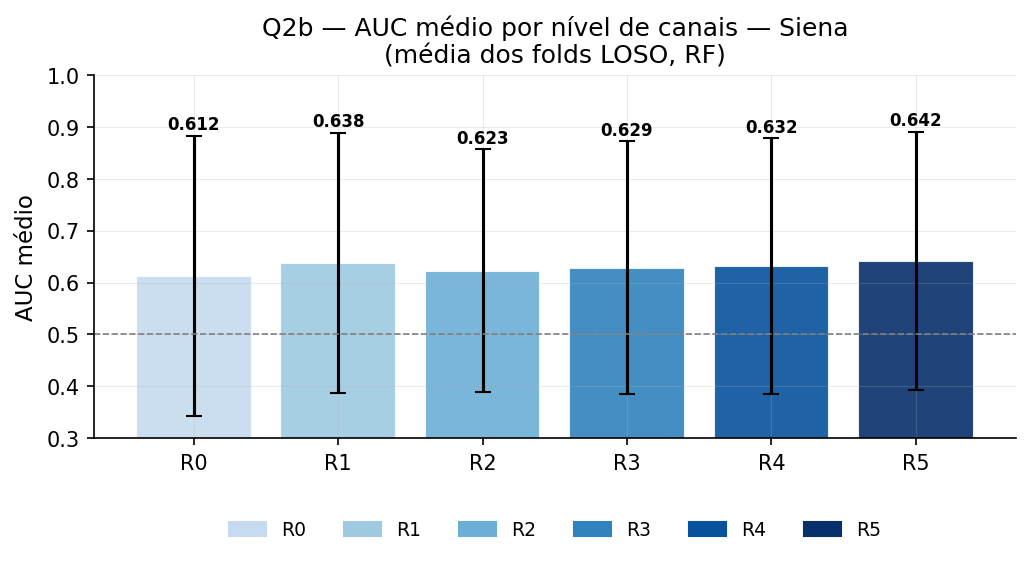

  -> q2b_niveis_Siena.png

Q2b — Siena
level  AUC médio   Std
   R0      0.612 0.271
   R1      0.638 0.251
   R2      0.623 0.234
   R3      0.629 0.244
   R4      0.632 0.247
   R5      0.642 0.249


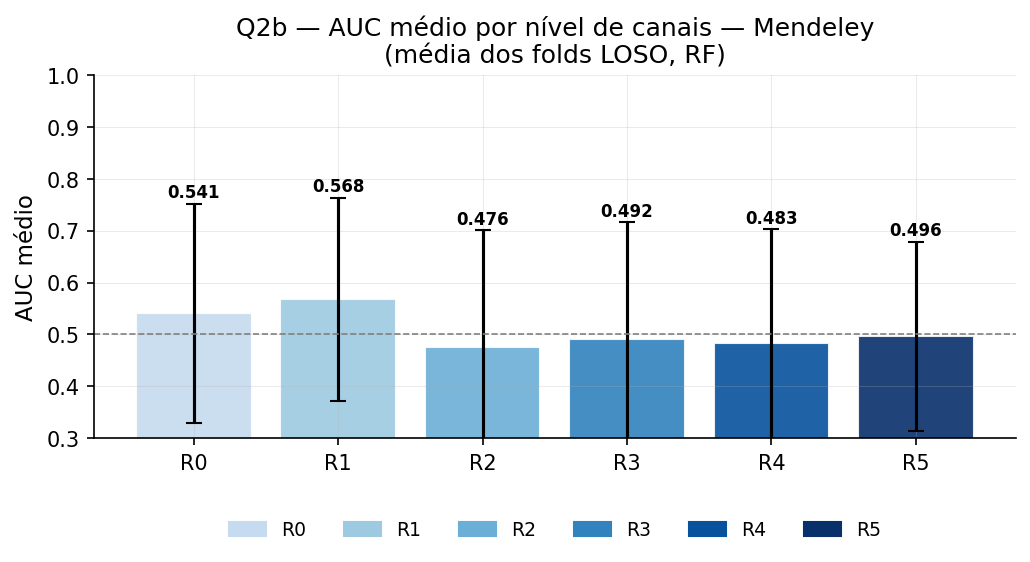

  -> q2b_niveis_Mendeley.png

Q2b — Mendeley
level  AUC médio   Std
   R0      0.541 0.211
   R1      0.568 0.196
   R2      0.476 0.225
   R3      0.492 0.224
   R4      0.483 0.219
   R5      0.496 0.183


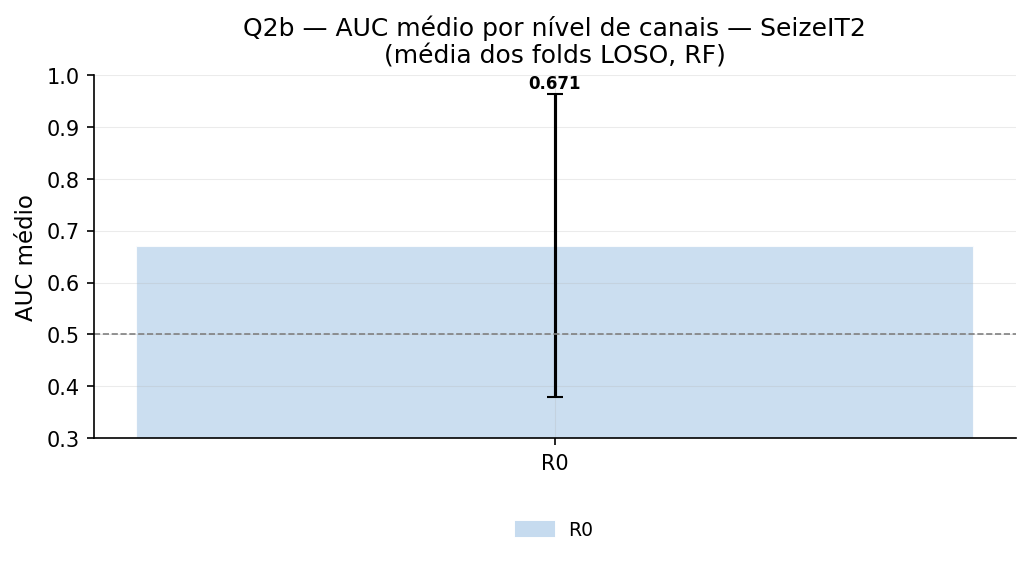

  -> q2b_niveis_SeizeIT2.png

Q2b — SeizeIT2
level  AUC médio   Std
   R0      0.671 0.292
   R1        NaN   NaN
   R2        NaN   NaN
   R3        NaN   NaN
   R4        NaN   NaN
   R5        NaN   NaN


In [65]:
# Q2a — global clínicos
s2_clin = s2[s2['dataset'].isin(CLINICAL)]
auc_lv = s2_clin.groupby('level')['auc'].agg(['mean','std']).reindex(LEVELS)
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(auc_lv.index, auc_lv['mean'], yerr=auc_lv['std'], capsize=4,
              color=[LC[l] for l in auc_lv.index], alpha=0.9, edgecolor='white')
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.set_ylabel('AUC médio'); ax.set_ylim(0.3,1.0)
ax.set_title('Q2a — AUC médio por nível de canais\n(datasets clínicos: CHB-MIT, Siena, Mendeley — RF)')
for i,(lvl,row) in enumerate(auc_lv.iterrows()):
    if not np.isnan(row['mean']):
        ax.text(i, row['mean']+row['std']+0.012, f"{row['mean']:.3f}", ha='center', fontsize=8, fontweight='bold')
leg(ax,[mpatches.Patch(color=LC[l],label=f'{l} ({[2,4,11,13,15,17][i]}ch)')
        for i,l in enumerate(LEVELS)], ncol=6)
fig.tight_layout(); savefig('q2a_niveis_clinicos')
ptab(auc_lv.rename(columns={'mean':'AUC médio','std':'Std'}).round(3).reset_index(),'Q2a')

# Q2b — por dataset
for ds in CLINICAL + ['SeizeIT2']:
    sub = s2[s2['dataset']==ds].groupby('level')['auc'].agg(['mean','std']).reindex(LEVELS)
    if sub['mean'].isna().all(): continue
    fig, ax = plt.subplots(figsize=(7,4))
    bars = ax.bar(sub.index, sub['mean'], yerr=sub['std'], capsize=4,
                  color=[LC[l] for l in sub.index], alpha=0.9, edgecolor='white')
    ax.axhline(0.5, color='gray', lw=0.8, ls='--')
    ax.set_ylabel('AUC médio'); ax.set_ylim(0.3,1.0)
    ax.set_title(f'Q2b — AUC médio por nível de canais — {ds}\n(média dos folds LOSO, RF)')
    for i,(lvl,row) in enumerate(sub.iterrows()):
        if not np.isnan(row['mean']):
            ax.text(i, row['mean']+row['std']+0.012, f"{row['mean']:.3f}", ha='center', fontsize=8, fontweight='bold')
    leg(ax,[mpatches.Patch(color=LC[l],label=f'{l}') for l in LEVELS if not sub.loc[l,'mean'] != sub.loc[l,'mean']], ncol=6)
    fig.tight_layout(); savefig(f'q2b_niveis_{ds}')
    ptab(sub.rename(columns={'mean':'AUC médio','std':'Std'}).round(3).reset_index(),f'Q2b — {ds}')


## Q3 — AUC R0 vs R5 por dataset

Azul claro = R0 (2ch), azul escuro = R5 (17ch). SeizeIT2 em cinza (R0 nativo).

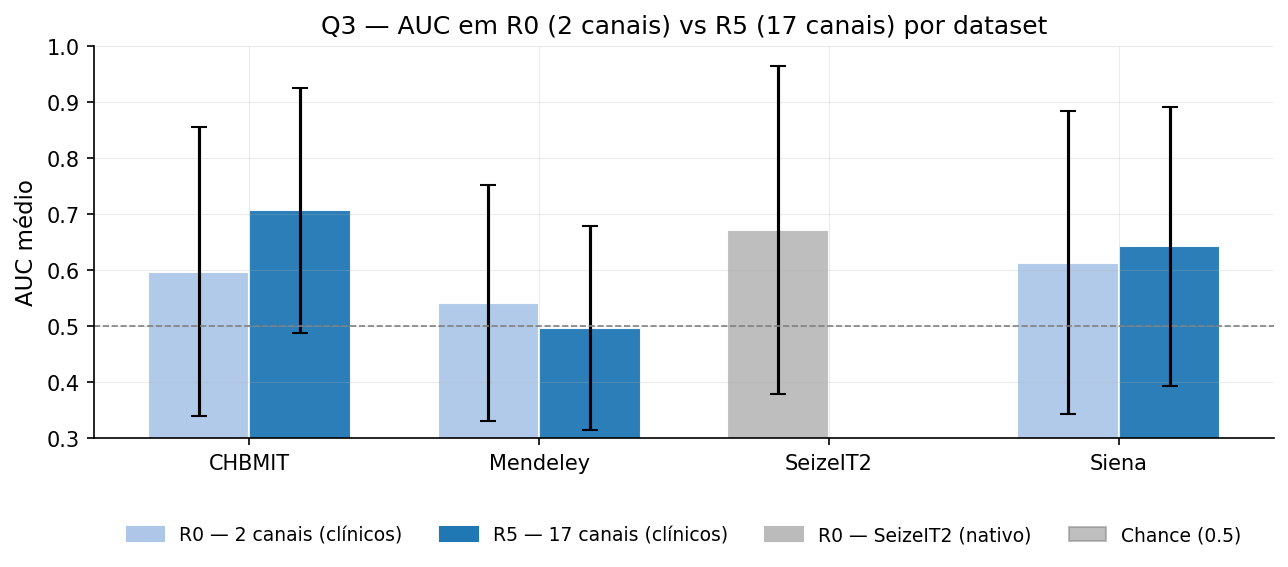

  -> q3_r0_vs_r5.png

Q3 — R0 vs R5
 Dataset  R0 AUC  R0 Std  R5 AUC  R5 Std  Queda R5-R0
  CHBMIT   0.597   0.258   0.706   0.219        0.109
Mendeley   0.541   0.211   0.496   0.183       -0.045
SeizeIT2   0.671   0.292     NaN     NaN          NaN
   Siena   0.612   0.271   0.642   0.249        0.030


In [66]:
datasets_q3 = sorted(s2['dataset'].unique())
auc_r0 = s2[s2['level']=='R0'].groupby('dataset')['auc'].agg(['mean','std']).reindex(datasets_q3)
auc_r5 = s2[s2['level']=='R5'].groupby('dataset')['auc'].agg(['mean','std']).reindex(datasets_q3)
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(datasets_q3)); w = 0.35
for i,ds in enumerate(datasets_q3):
    c0 = '#aec7e8' if ds!='SeizeIT2' else '#bbbbbb'
    c5 = '#1f77b4' if ds!='SeizeIT2' else '#888888'
    r0m,r0s = auc_r0.loc[ds,'mean'], auc_r0.loc[ds,'std']
    r5m,r5s = auc_r5.loc[ds,'mean'], auc_r5.loc[ds,'std']
    ax.bar(x[i]-w/2, r0m, w, yerr=r0s if not np.isnan(r0s) else 0,
           capsize=4, color=c0, edgecolor='white', alpha=0.95)
    if not np.isnan(r5m):
        ax.bar(x[i]+w/2, r5m, w, yerr=r5s if not np.isnan(r5s) else 0,
               capsize=4, color=c5, edgecolor='white', alpha=0.95)
    if ds=='SeizeIT2':
        ax.annotate('*R0 nativo', xy=(x[i], r0m+(r0s or 0)+0.04), ha='center', fontsize=8, color='#555')
ax.set_xticks(x); ax.set_xticklabels(datasets_q3)
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.set_ylabel('AUC médio'); ax.set_ylim(0.3,1.0)
ax.set_title('Q3 — AUC em R0 (2 canais) vs R5 (17 canais) por dataset')
leg(ax,[mpatches.Patch(color='#aec7e8',label='R0 — 2 canais (clínicos)'),
        mpatches.Patch(color='#1f77b4',label='R5 — 17 canais (clínicos)'),
        mpatches.Patch(color='#bbbbbb',label='R0 — SeizeIT2 (nativo)'),
        mpatches.Patch(color='gray',alpha=0.5,label='Chance (0.5)')], ncol=4)
fig.tight_layout(); savefig('q3_r0_vs_r5')
t3 = pd.DataFrame({'Dataset':datasets_q3,
    'R0 AUC':auc_r0['mean'].values, 'R0 Std':auc_r0['std'].values,
    'R5 AUC':auc_r5['mean'].values, 'R5 Std':auc_r5['std'].values}).round(3)
t3['Queda R5-R0'] = (t3['R5 AUC']-t3['R0 AUC']).round(3)
ptab(t3,'Q3 — R0 vs R5')


## Q4 — Qual modelo performa melhor?

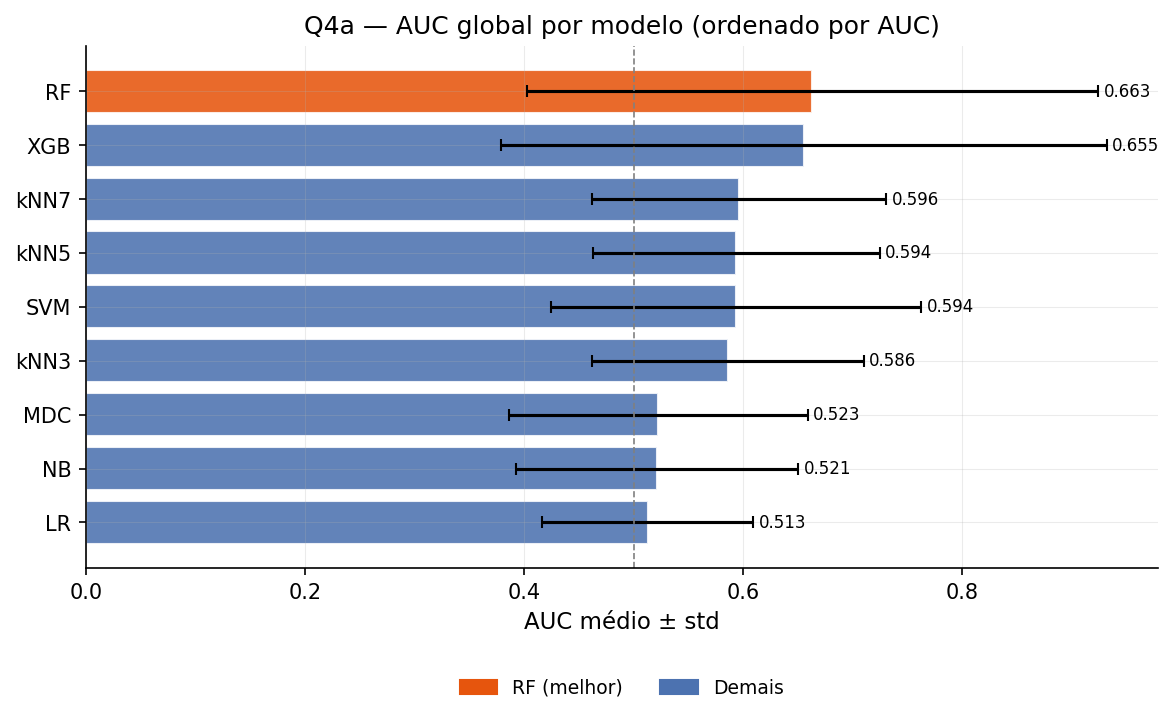

  -> q4a_auc_modelos.png


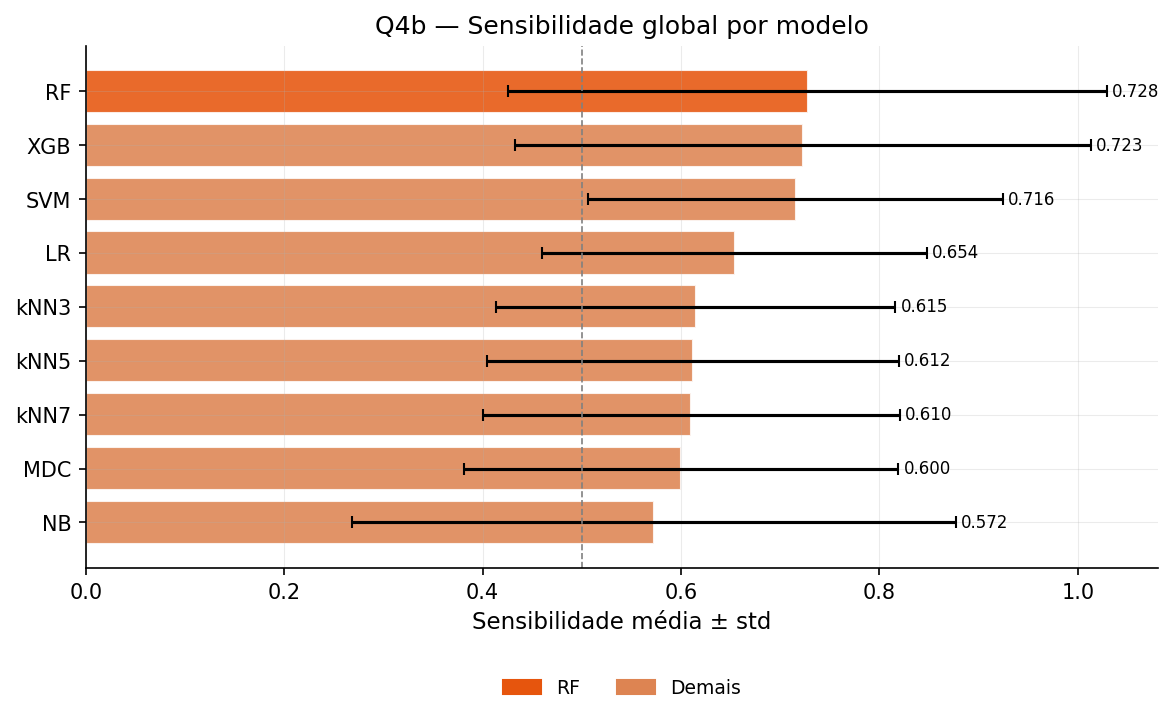

  -> q4b_sens_modelos.png

Q4 — AUC e Sensibilidade por modelo
Modelo  AUC médio  AUC Std  Sensibilidade
    RF      0.663    0.261          0.728
   XGB      0.655    0.276          0.723
  kNN7      0.596    0.134          0.610
  kNN5      0.594    0.131          0.612
   SVM      0.594    0.169          0.716
  kNN3      0.586    0.124          0.615
   MDC      0.523    0.136          0.600
    NB      0.521    0.129          0.572
    LR      0.513    0.096          0.654


In [67]:
auc_mod = s3.groupby('model')['auc'].agg(['mean','std']).sort_values('mean')
sens_mod = s3.groupby('model')['sensitivity'].mean().reindex(auc_mod.index)
colors_m = ['#e6550d' if m==BEST_MODEL else '#4C72B0' for m in auc_mod.index]

# AUC global
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(auc_mod.index, auc_mod['mean'], xerr=auc_mod['std'], capsize=3,
        color=colors_m, alpha=0.88, edgecolor='white')
ax.axvline(0.5, color='gray', lw=0.8, ls='--')
ax.set_xlabel('AUC médio ± std')
ax.set_title('Q4a — AUC global por modelo (ordenado por AUC)')
for i,(m,row) in enumerate(auc_mod.iterrows()):
    ax.text(row['mean']+row['std']+0.005, i, f"{row['mean']:.3f}", va='center', fontsize=8)
leg(ax,[mpatches.Patch(color='#e6550d',label=f'{BEST_MODEL} (melhor)'),
        mpatches.Patch(color='#4C72B0',label='Demais')], ncol=2)
fig.tight_layout(); savefig('q4a_auc_modelos')

# Sensibilidade global
sens_mod2 = s3.groupby('model')['sensitivity'].agg(['mean','std']).sort_values('mean')
colors_s = ['#e6550d' if m==BEST_MODEL else '#DD8452' for m in sens_mod2.index]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(sens_mod2.index, sens_mod2['mean'], xerr=sens_mod2['std'], capsize=3,
        color=colors_s, alpha=0.88, edgecolor='white')
ax.axvline(0.5, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Sensibilidade média ± std')
ax.set_title('Q4b — Sensibilidade global por modelo')
for i,(m,row) in enumerate(sens_mod2.iterrows()):
    ax.text(row['mean']+row['std']+0.005, i, f"{row['mean']:.3f}", va='center', fontsize=8)
leg(ax,[mpatches.Patch(color='#e6550d',label=f'{BEST_MODEL}'),
        mpatches.Patch(color='#DD8452',label='Demais')], ncol=2)
fig.tight_layout(); savefig('q4b_sens_modelos')

t4 = pd.DataFrame({
    'Modelo': auc_mod.index,
    'AUC médio': auc_mod['mean'].values, 'AUC Std': auc_mod['std'].values,
    'Sensibilidade': sens_mod.values}).sort_values('AUC médio',ascending=False).round(3)
ptab(t4,'Q4 — AUC e Sensibilidade por modelo')


## Q5 — Variabilidade entre pacientes (AUC e Sensibilidade)

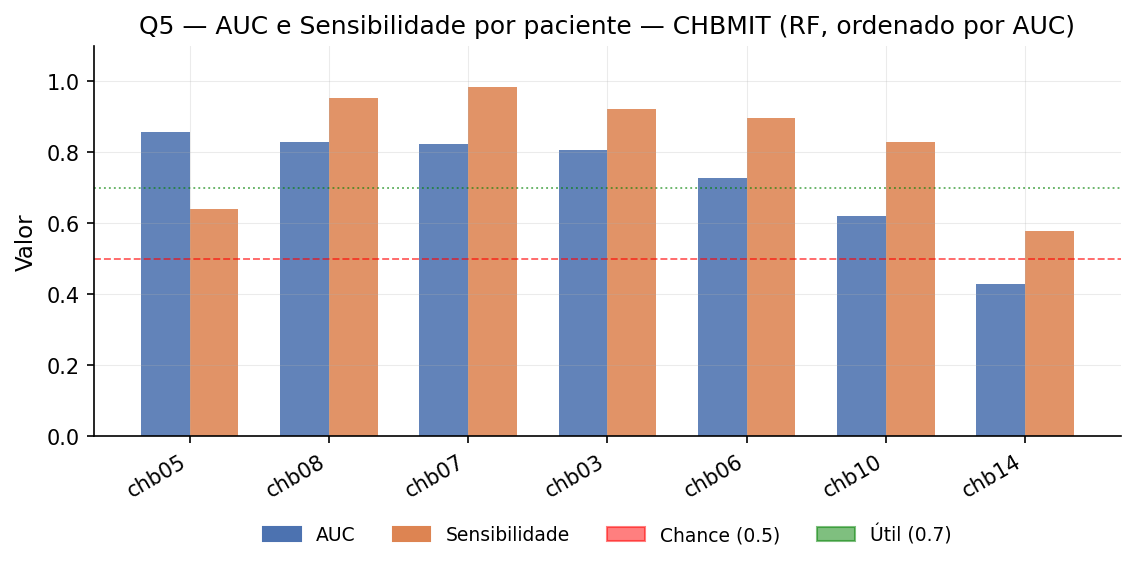

  -> q5_auc_sens_CHBMIT.png

Q5 — CHBMIT
Paciente   AUC  Sensibilidade
   chb05 0.858          0.641
   chb08 0.830          0.954
   chb07 0.823          0.983
   chb03 0.807          0.921
   chb06 0.727          0.896
   chb10 0.622          0.829
   chb14 0.430          0.578


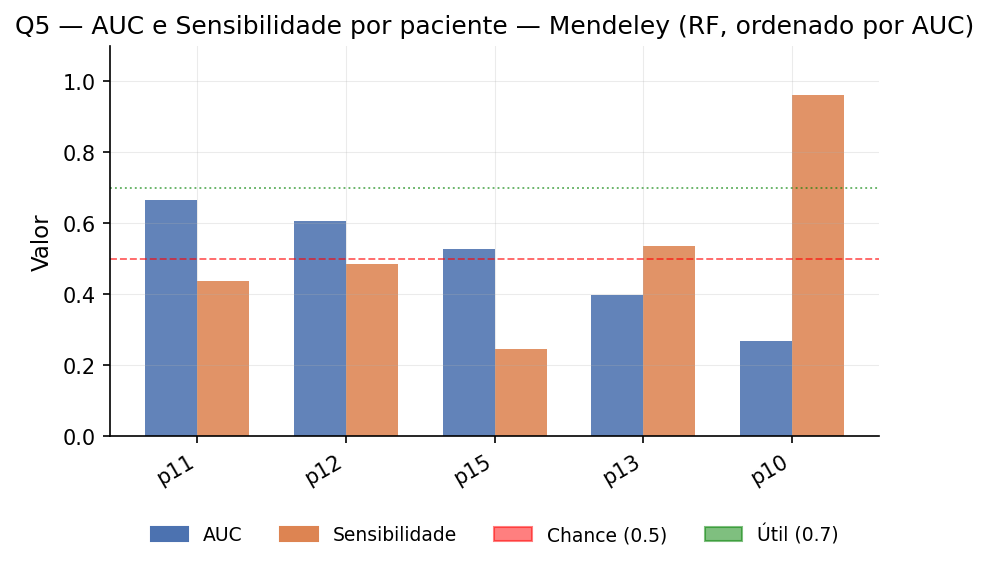

  -> q5_auc_sens_Mendeley.png

Q5 — Mendeley
Paciente   AUC  Sensibilidade
     p11 0.665          0.438
     p12 0.607          0.487
     p15 0.528          0.247
     p13 0.398          0.537
     p10 0.268          0.962


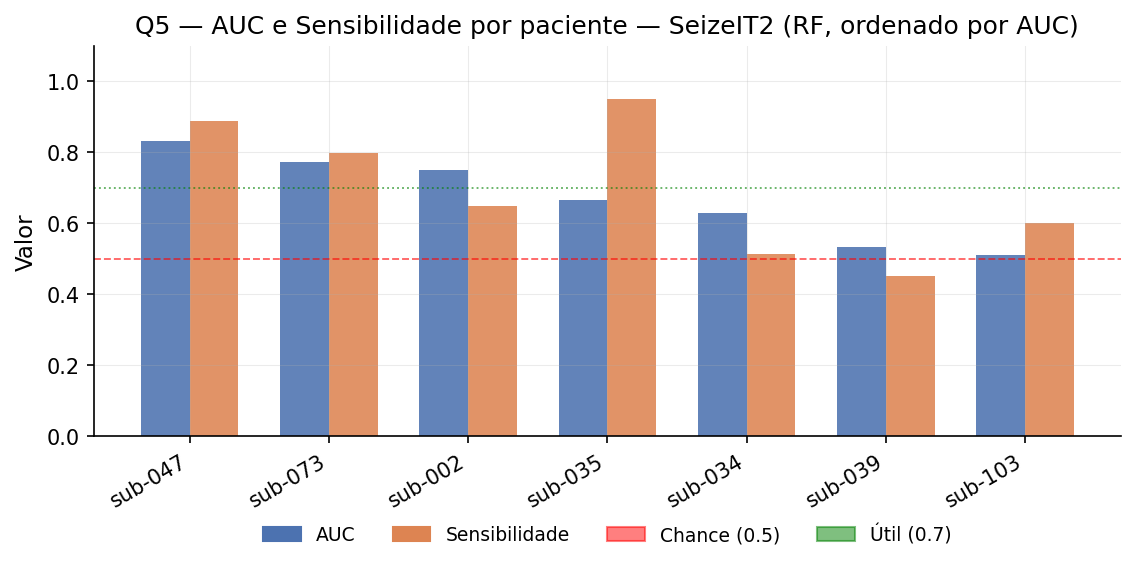

  -> q5_auc_sens_SeizeIT2.png

Q5 — SeizeIT2
Paciente   AUC  Sensibilidade
 sub-047 0.833          0.888
 sub-073 0.772          0.798
 sub-002 0.749          0.648
 sub-035 0.666          0.951
 sub-034 0.630          0.514
 sub-039 0.534          0.453
 sub-103 0.510          0.601


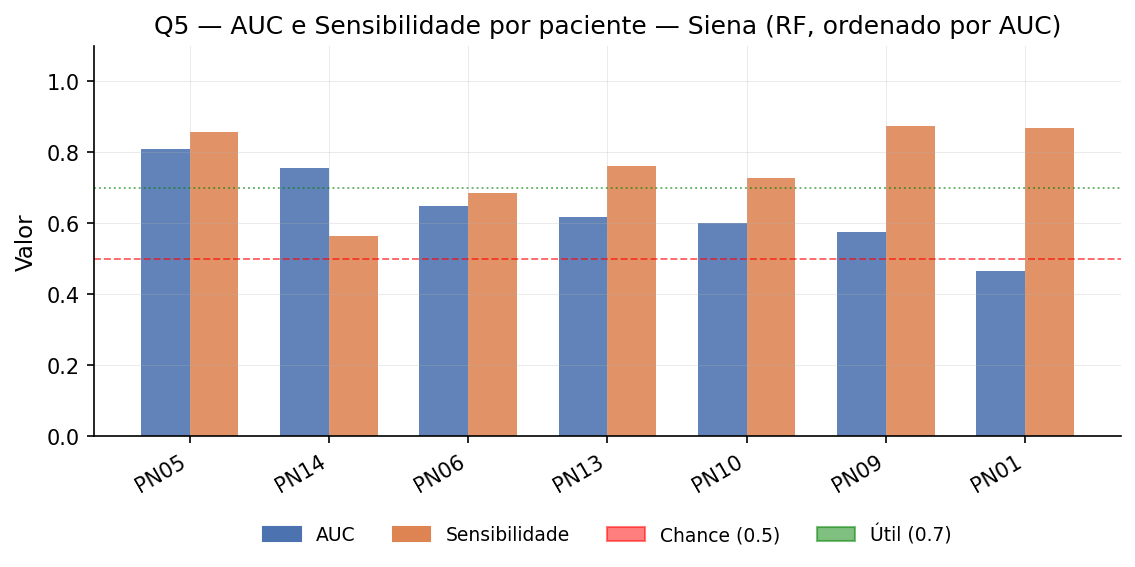

  -> q5_auc_sens_Siena.png

Q5 — Siena
Paciente   AUC  Sensibilidade
    PN05 0.808          0.858
    PN14 0.757          0.564
    PN06 0.649          0.686
    PN13 0.618          0.762
    PN10 0.601          0.727
    PN09 0.576          0.875
    PN01 0.464          0.869


In [68]:
for ds in sorted(s3_rf['dataset'].unique()):
    sub = s3_rf[s3_rf['dataset']==ds]
    auc_pp  = sub.groupby('paciente')['auc'].mean().sort_values(ascending=False)
    sens_pp = sub.groupby('paciente')['sensitivity'].mean().reindex(auc_pp.index)
    pats = auc_pp.index.tolist()
    x = np.arange(len(pats)); w = 0.35
    fig, ax = plt.subplots(figsize=(max(6,len(pats)*1.1),4))
    ax.bar(x-w/2, auc_pp.values,  w, label='AUC',           color='#4C72B0', alpha=0.88)
    ax.bar(x+w/2, sens_pp.values, w, label='Sensibilidade', color='#DD8452', alpha=0.88)
    ax.axhline(0.5, color='red',   lw=0.9, ls='--', alpha=0.6)
    ax.axhline(0.7, color='green', lw=0.9, ls=':',  alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(pats, rotation=30, ha='right')
    ax.set_ylabel('Valor'); ax.set_ylim(0,1.1)
    ax.set_title(f'Q5 — AUC e Sensibilidade por paciente — {ds} (RF, ordenado por AUC)')
    leg(ax,[mpatches.Patch(color='#4C72B0',label='AUC'),
            mpatches.Patch(color='#DD8452',label='Sensibilidade'),
            mpatches.Patch(color='red',alpha=0.5,label='Chance (0.5)'),
            mpatches.Patch(color='green',alpha=0.5,label='Útil (0.7)')], ncol=4)
    fig.tight_layout(); savefig(f'q5_auc_sens_{ds}')
    t5 = pd.DataFrame({'Paciente':pats,'AUC':auc_pp.values,'Sensibilidade':sens_pp.values}).round(3)
    ptab(t5, f'Q5 — {ds}')


## Q6 — H5 (PELT) vs horizontes fixos por paciente

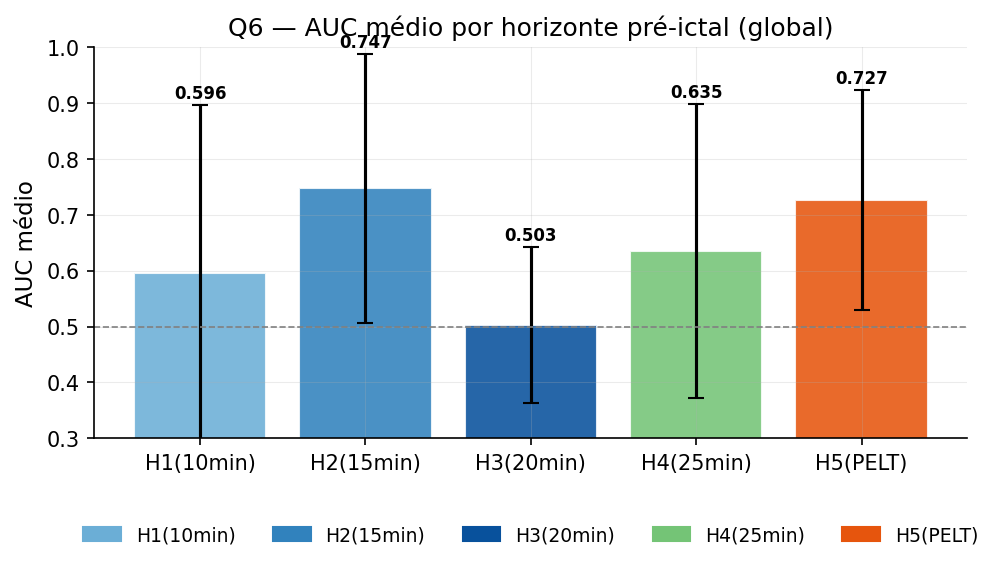

  -> q6_global.png

Q6 — Global
horizonte  AUC médio   Std
H1(10min)      0.596 0.301
H2(15min)      0.747 0.241
H3(20min)      0.503 0.140
H4(25min)      0.635 0.263
 H5(PELT)      0.727 0.197


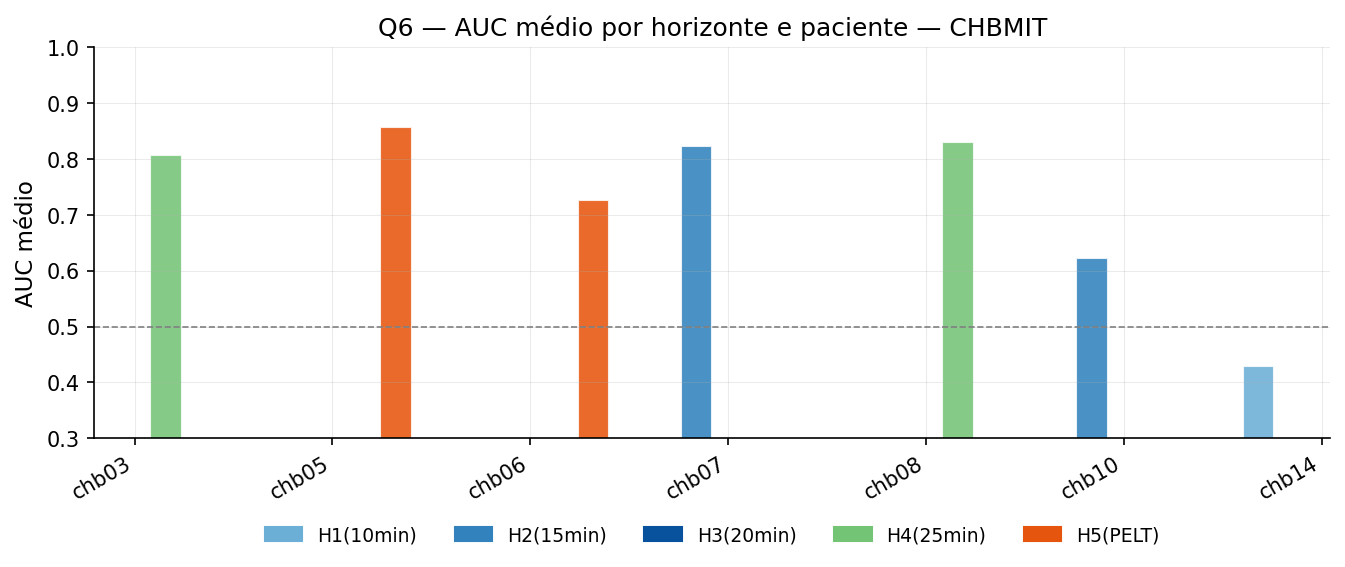

  -> q6_horizonte_CHBMIT.png

Q6 — CHBMIT
paciente  H1(10min)  H2(15min)  H3(20min)  H4(25min)  H5(PELT)
   chb03        NaN        NaN        NaN      0.807       NaN
   chb05        NaN        NaN        NaN        NaN     0.858
   chb06        NaN        NaN        NaN        NaN     0.727
   chb07        NaN      0.823        NaN        NaN       NaN
   chb08        NaN        NaN        NaN      0.830       NaN
   chb10        NaN      0.622        NaN        NaN       NaN
   chb14       0.43        NaN        NaN        NaN       NaN


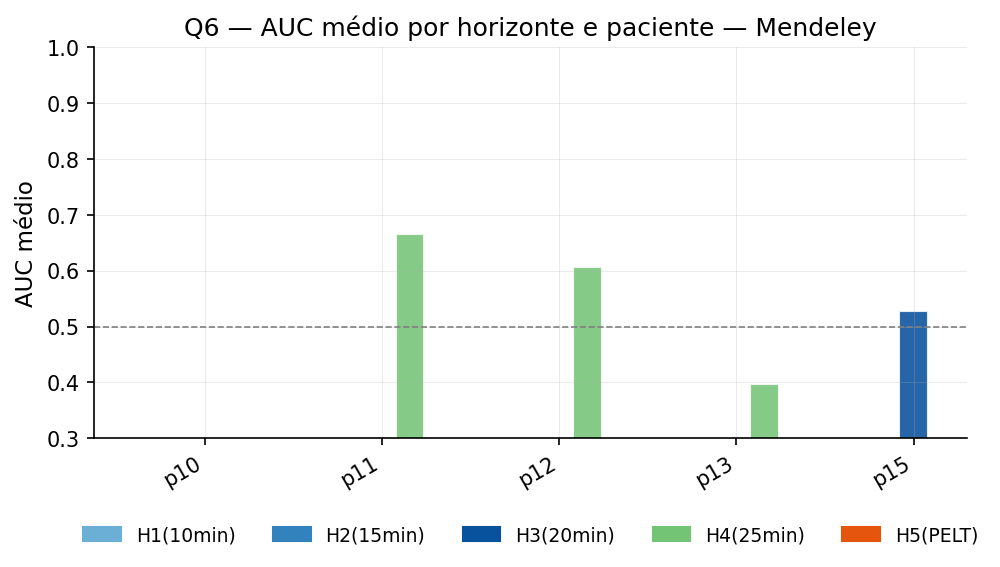

  -> q6_horizonte_Mendeley.png

Q6 — Mendeley
paciente  H1(10min)  H2(15min)  H3(20min)  H4(25min)  H5(PELT)
     p10      0.268        NaN        NaN        NaN       NaN
     p11        NaN        NaN        NaN      0.665       NaN
     p12        NaN        NaN        NaN      0.607       NaN
     p13        NaN        NaN        NaN      0.398       NaN
     p15        NaN        NaN      0.528        NaN       NaN


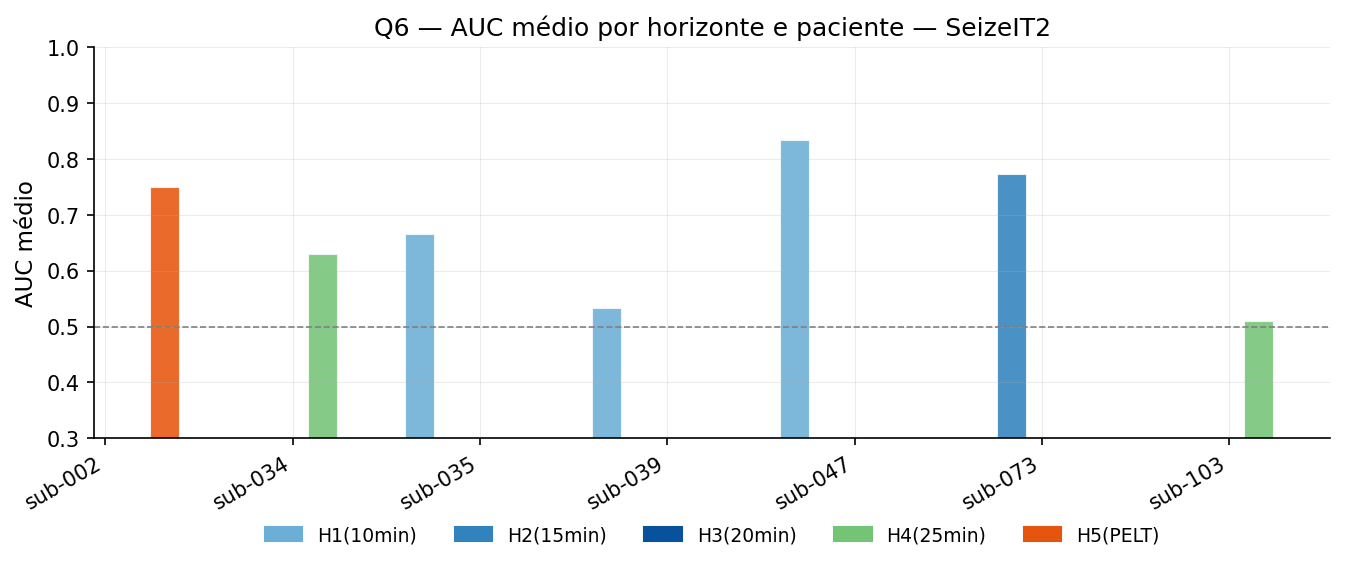

  -> q6_horizonte_SeizeIT2.png

Q6 — SeizeIT2
paciente  H1(10min)  H2(15min)  H3(20min)  H4(25min)  H5(PELT)
 sub-002        NaN        NaN        NaN        NaN     0.749
 sub-034        NaN        NaN        NaN       0.63       NaN
 sub-035      0.666        NaN        NaN        NaN       NaN
 sub-039      0.534        NaN        NaN        NaN       NaN
 sub-047      0.833        NaN        NaN        NaN       NaN
 sub-073        NaN      0.772        NaN        NaN       NaN
 sub-103        NaN        NaN        NaN       0.51       NaN


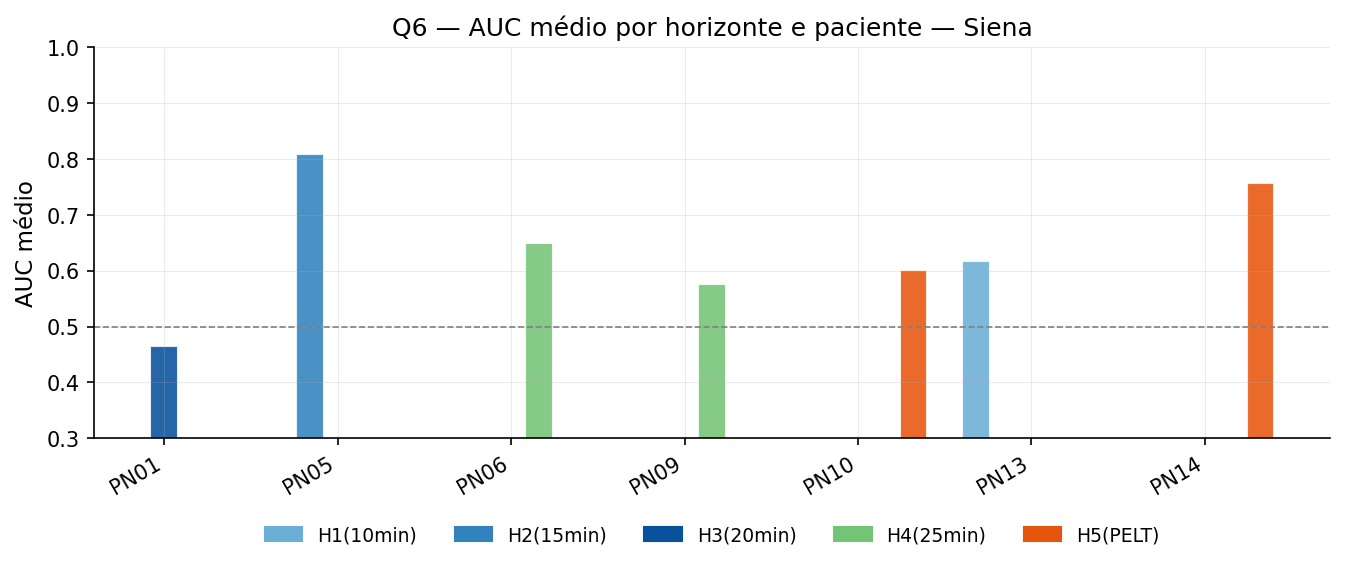

  -> q6_horizonte_Siena.png

Q6 — Siena
paciente  H1(10min)  H2(15min)  H3(20min)  H4(25min)  H5(PELT)
    PN01        NaN        NaN      0.464        NaN       NaN
    PN05        NaN      0.808        NaN        NaN       NaN
    PN06        NaN        NaN        NaN      0.649       NaN
    PN09        NaN        NaN        NaN      0.576       NaN
    PN10        NaN        NaN        NaN        NaN     0.601
    PN13      0.618        NaN        NaN        NaN       NaN
    PN14        NaN        NaN        NaN        NaN     0.757


In [69]:
H6 = ['H1(10min)','H2(15min)','H3(20min)','H4(25min)','H5(PELT)']
HC6 = {'H1(10min)':'#6baed6','H2(15min)':'#3182bd','H3(20min)':'#08519c',
        'H4(25min)':'#74c476','H5(PELT)':'#e6550d'}

# Global
auc_h6 = s1.groupby('horizonte')['auc'].agg(['mean','std']).reindex(H6)
fig, ax = plt.subplots(figsize=(7,4))
bars = ax.bar(auc_h6.index, auc_h6['mean'], yerr=auc_h6['std'], capsize=4,
              color=[HC6.get(h,'#999') for h in auc_h6.index], alpha=0.88, edgecolor='white')
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.set_ylabel('AUC médio'); ax.set_ylim(0.3,1.0)
ax.set_title('Q6 — AUC médio por horizonte pré-ictal (global)')
for bar,(_, row) in zip(bars, auc_h6.iterrows()):
    if not np.isnan(row['mean']):
        ax.text(bar.get_x()+bar.get_width()/2,
                row['mean']+(row['std'] or 0)+0.012,
                f"{row['mean']:.3f}", ha='center', fontsize=8, fontweight='bold')
leg(ax,[mpatches.Patch(color=HC6[h],label=h) for h in H6], ncol=5)
fig.tight_layout(); savefig('q6_global')
ptab(auc_h6.rename(columns={'mean':'AUC médio','std':'Std'}).round(3).reset_index(),'Q6 — Global')

# Por dataset: barras agrupadas por paciente, uma barra por horizonte
for ds in sorted(s1['dataset'].unique()):
    sub_ds = s1[s1['dataset']==ds]
    pats_ds = sorted(sub_ds['paciente'].unique())
    pt = sub_ds.groupby(['paciente','horizonte'])['auc'].mean().unstack('horizonte')
    pt = pt.reindex(pats_ds).reindex(columns=H6)
    n_h = len(H6); x = np.arange(len(pats_ds)); w = 0.8/n_h
    fig, ax = plt.subplots(figsize=(max(7,len(pats_ds)*1.3),4))
    for j,h in enumerate(H6):
        if h in pt.columns:
            ax.bar(x + j*w - (n_h-1)*w/2, pt[h].values, w,
                   label=h, color=HC6.get(h,'#999'), alpha=0.88, edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels(pats_ds, rotation=30, ha='right')
    ax.axhline(0.5, color='gray', lw=0.8, ls='--')
    ax.set_ylabel('AUC médio'); ax.set_ylim(0.3,1.0)
    ax.set_title(f'Q6 — AUC médio por horizonte e paciente — {ds}')
    leg(ax,[mpatches.Patch(color=HC6[h],label=h) for h in H6], ncol=5)
    fig.tight_layout(); savefig(f'q6_horizonte_{ds}')
    ptab(pt.round(3).reset_index(), f'Q6 — {ds}')


## Q7 — PRE_SEC estimado correlaciona com AUC?

Cada ponto = 1 paciente. Cor = dataset. Linha tracejada = tendência linear. PRE_SEC maior significa que o PELT detectou transição mais cedo — isso melhora o AUC?

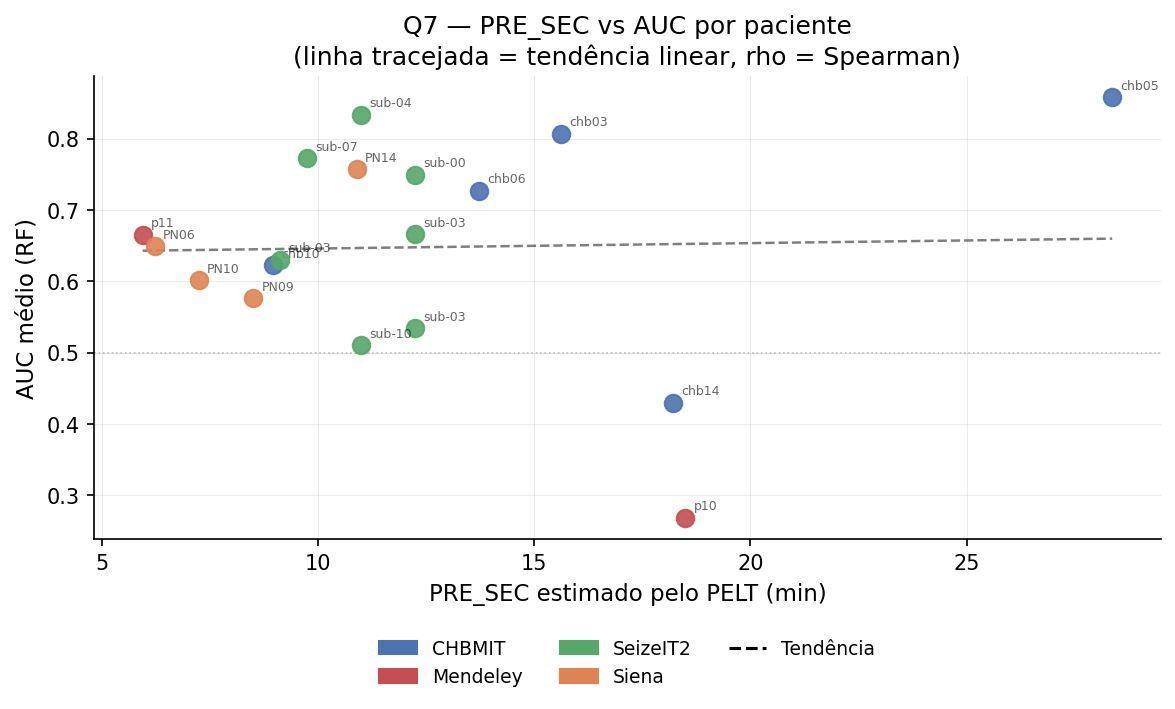

  -> q7a_presec_auc.png

Q7 — AUC
 dataset paciente  pre_sec_min   auc
  CHBMIT    chb03       15.617 0.807
  CHBMIT    chb05       28.367 0.858
  CHBMIT    chb06       13.733 0.727
  CHBMIT    chb10        8.967 0.622
  CHBMIT    chb14       18.217 0.430
Mendeley      p10       18.492 0.268
Mendeley      p11        5.950 0.665
SeizeIT2  sub-002       12.250 0.749
SeizeIT2  sub-034        9.125 0.630
SeizeIT2  sub-035       12.250 0.666
SeizeIT2  sub-039       12.250 0.534
SeizeIT2  sub-047       11.000 0.833
SeizeIT2  sub-073        9.750 0.772
SeizeIT2  sub-103       11.000 0.510
   Siena     PN06        6.233 0.649
   Siena     PN09        8.500 0.576
   Siena     PN10        7.250 0.601
   Siena     PN14       10.900 0.757


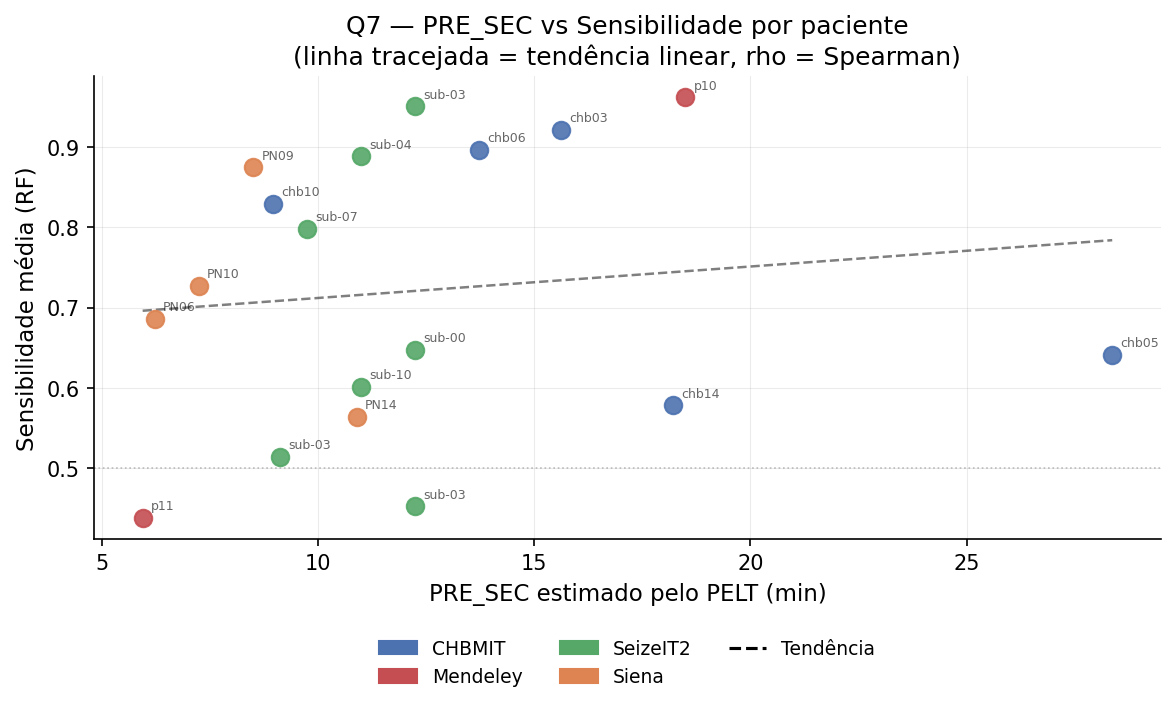

  -> q7b_presec_sens.png

Q7 — Sensibilidade
 dataset paciente  pre_sec_min  sensitivity
  CHBMIT    chb03       15.617        0.921
  CHBMIT    chb05       28.367        0.641
  CHBMIT    chb06       13.733        0.896
  CHBMIT    chb10        8.967        0.829
  CHBMIT    chb14       18.217        0.578
Mendeley      p10       18.492        0.962
Mendeley      p11        5.950        0.438
SeizeIT2  sub-002       12.250        0.648
SeizeIT2  sub-034        9.125        0.514
SeizeIT2  sub-035       12.250        0.951
SeizeIT2  sub-039       12.250        0.453
SeizeIT2  sub-047       11.000        0.888
SeizeIT2  sub-073        9.750        0.798
SeizeIT2  sub-103       11.000        0.601
   Siena     PN06        6.233        0.686
   Siena     PN09        8.500        0.875
   Siena     PN10        7.250        0.727
   Siena     PN14       10.900        0.564


In [70]:
if HAS_PRE:
    auc_pp = s3_rf.groupby(['dataset','paciente'])['auc'].mean().reset_index()
    sens_pp = s3_rf.groupby(['dataset','paciente'])['sensitivity'].mean().reset_index()
    for metric, df_m, col, ylabel, fname in [
        ('AUC',          auc_pp,  'auc',         'AUC médio (RF)',           'q7a_presec_auc'),
        ('Sensibilidade', sens_pp, 'sensitivity', 'Sensibilidade média (RF)', 'q7b_presec_sens'),
    ]:
        df_m = df_m.copy()
        df_m['pre_sec_min'] = df_m.apply(
            lambda r: pre_est.get((r['dataset'],r['paciente']),{}).get('pre_sec',np.nan)/60, axis=1)
        df_m = df_m.dropna(subset=['pre_sec_min'])
        fig, ax = plt.subplots(figsize=(8,5))
        for ds in sorted(df_m['dataset'].unique()):
            s = df_m[df_m['dataset']==ds]
            ax.scatter(s['pre_sec_min'], s[col], color=DC.get(ds,'gray'),
                       label=ds, s=70, alpha=0.9, zorder=3)
            for _,row in s.iterrows():
                ax.annotate(row['paciente'][:6],(row['pre_sec_min'],row[col]),
                            fontsize=6, alpha=0.6, xytext=(4,4), textcoords='offset points')
        if len(df_m) >= 3:
            rho,pval = stats.spearmanr(df_m['pre_sec_min'], df_m[col])
            mb,bb = np.polyfit(df_m['pre_sec_min'], df_m[col], 1)
            xs = np.linspace(df_m['pre_sec_min'].min(), df_m['pre_sec_min'].max(), 50)
            ax.plot(xs, mb*xs+bb, 'k--', lw=1.2, alpha=0.5,
                    label=f'Tendência linear (rho={rho:.2f}, p={pval:.3f})')
        ax.axhline(0.5, color='gray', lw=0.8, ls=':', alpha=0.5)
        ax.set_xlabel('PRE_SEC estimado pelo PELT (min)')
        ax.set_ylabel(ylabel)
        ax.set_title(f'Q7 — PRE_SEC vs {metric} por paciente\n'
                     f'(linha tracejada = tendência linear, rho = Spearman)')
        leg(ax,[mpatches.Patch(color=DC.get(d,'gray'),label=d)
                for d in sorted(df_m['dataset'].unique())]+
               [plt.Line2D([0],[0],color='k',ls='--',label='Tendência')], ncol=3)
        fig.tight_layout(); savefig(fname)
        ptab(df_m[['dataset','paciente','pre_sec_min',col]].round(3), f'Q7 — {metric}')
else:
    print('preictal_estimate.json nao encontrado em data/')


## Q8 — Degradação de AUC ao reduzir canais (um gráfico por dataset clínico)

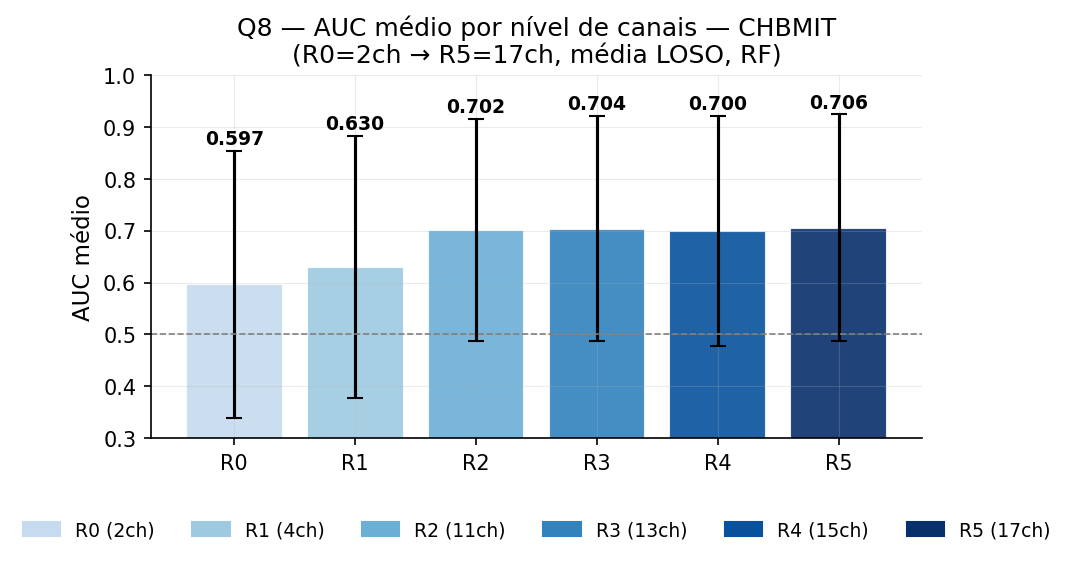

  -> q8_degradacao_CHBMIT.png

Q8 — CHBMIT
level  AUC médio   Std
   R0      0.597 0.258
   R1      0.630 0.253
   R2      0.702 0.214
   R3      0.704 0.218
   R4      0.700 0.222
   R5      0.706 0.219


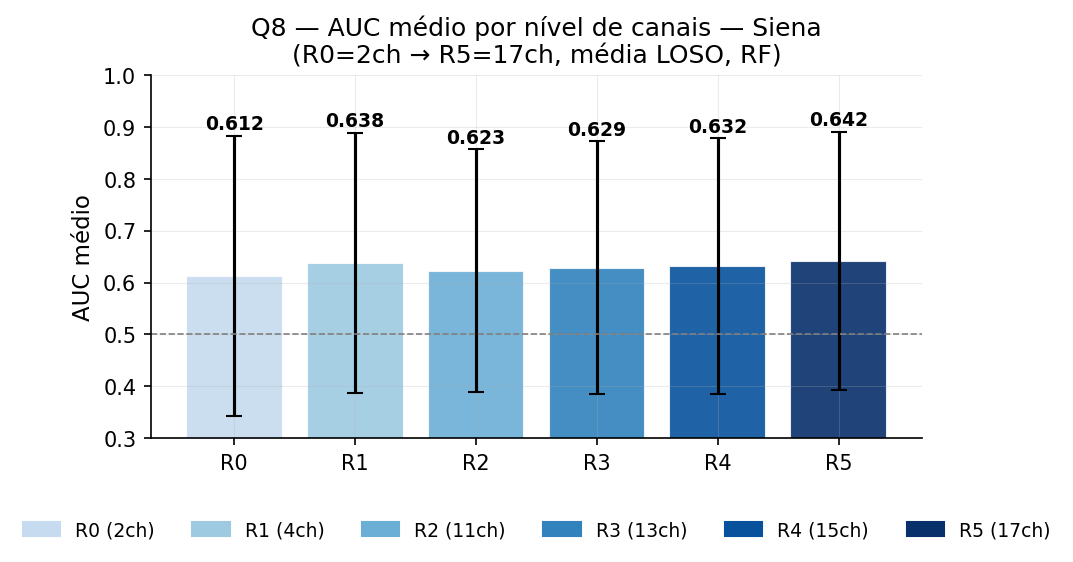

  -> q8_degradacao_Siena.png

Q8 — Siena
level  AUC médio   Std
   R0      0.612 0.271
   R1      0.638 0.251
   R2      0.623 0.234
   R3      0.629 0.244
   R4      0.632 0.247
   R5      0.642 0.249


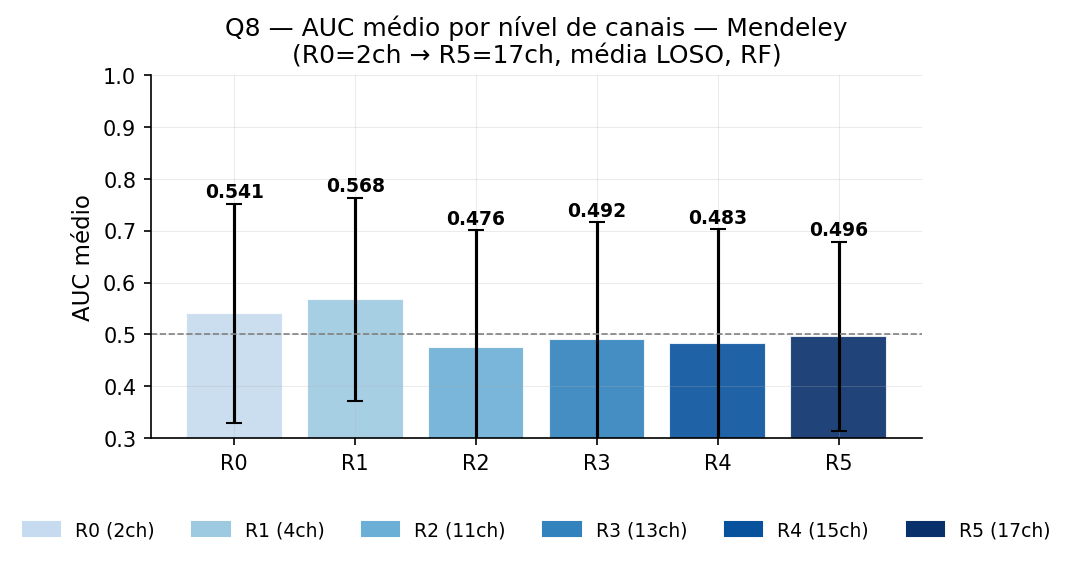

  -> q8_degradacao_Mendeley.png

Q8 — Mendeley
level  AUC médio   Std
   R0      0.541 0.211
   R1      0.568 0.196
   R2      0.476 0.225
   R3      0.492 0.224
   R4      0.483 0.219
   R5      0.496 0.183


In [71]:
for ds in CLINICAL:
    sub = s2[s2['dataset']==ds].groupby('level')['auc'].agg(['mean','std']).reindex(LEVELS)
    if sub['mean'].isna().all(): continue
    fig, ax = plt.subplots(figsize=(7,4))
    bars = ax.bar(sub.index, sub['mean'], yerr=sub['std'], capsize=4,
                  color=[LC[l] for l in sub.index], alpha=0.9, edgecolor='white')
    ax.axhline(0.5, color='gray', lw=0.8, ls='--')
    ax.set_ylabel('AUC médio'); ax.set_ylim(0.3,1.0)
    ax.set_title(f'Q8 — AUC médio por nível de canais — {ds}\n(R0=2ch → R5=17ch, média LOSO, RF)')
    for i,(l,row) in enumerate(sub.iterrows()):
        if not np.isnan(row['mean']):
            ax.text(i, row['mean']+row['std']+0.012, f"{row['mean']:.3f}",
                    ha='center', fontsize=9, fontweight='bold')
    n_ch = [2,4,11,13,15,17]
    leg(ax,[mpatches.Patch(color=LC[l],label=f'{l} ({n_ch[i]}ch)')
            for i,l in enumerate(LEVELS)], ncol=6)
    fig.tight_layout(); savefig(f'q8_degradacao_{ds}')
    ptab(sub.rename(columns={'mean':'AUC médio','std':'Std'}).round(3).reset_index(), f'Q8 — {ds}')


## Q9 — Qualidade do PELT (silhueta) impacta o AUC do H5?

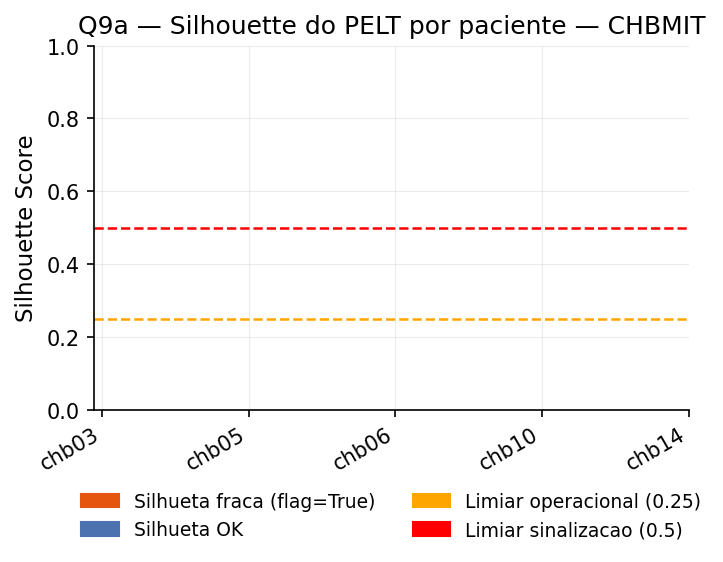

  -> q9a_silhueta_CHBMIT.png


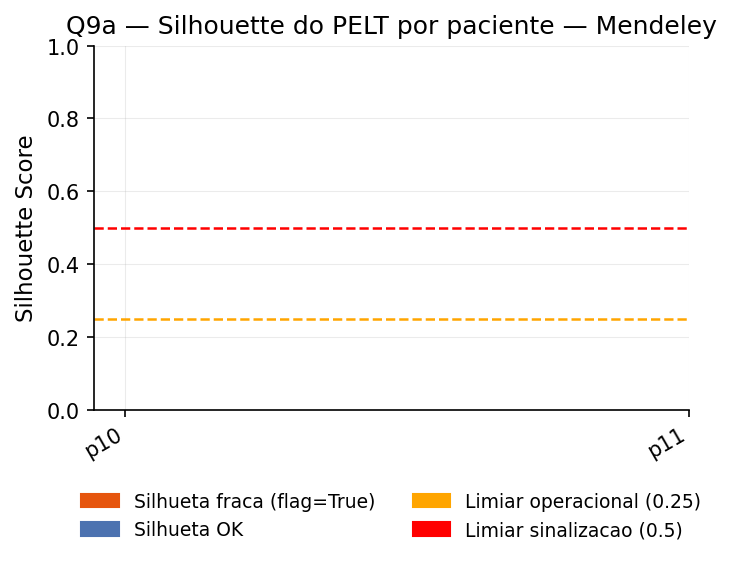

  -> q9a_silhueta_Mendeley.png


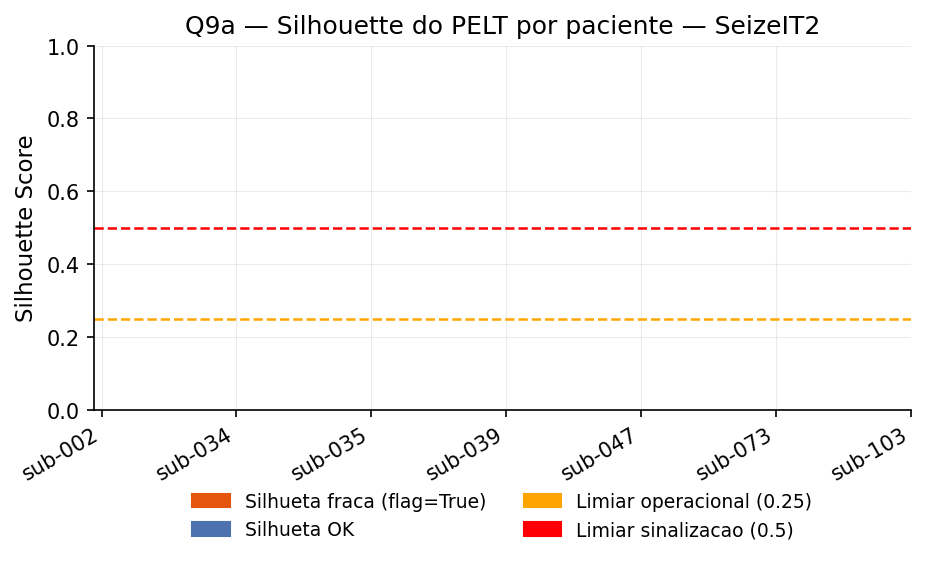

  -> q9a_silhueta_SeizeIT2.png


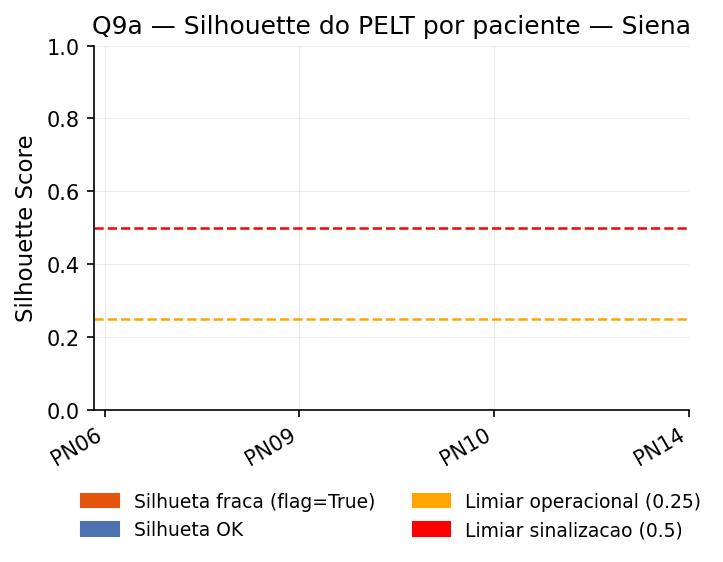

  -> q9a_silhueta_Siena.png

Q9a — Silhouette
 dataset paciente  silh  flag
  CHBMIT    chb03   NaN False
  CHBMIT    chb05   NaN  True
  CHBMIT    chb06   NaN  True
  CHBMIT    chb10   NaN  True
  CHBMIT    chb14   NaN  True
Mendeley      p10   NaN  True
Mendeley      p11   NaN False
SeizeIT2  sub-002   NaN False
SeizeIT2  sub-034   NaN False
SeizeIT2  sub-035   NaN False
SeizeIT2  sub-039   NaN False
SeizeIT2  sub-047   NaN False
SeizeIT2  sub-073   NaN False
SeizeIT2  sub-103   NaN False
   Siena     PN06   NaN False
   Siena     PN09   NaN  True
   Siena     PN10   NaN False
   Siena     PN14   NaN False


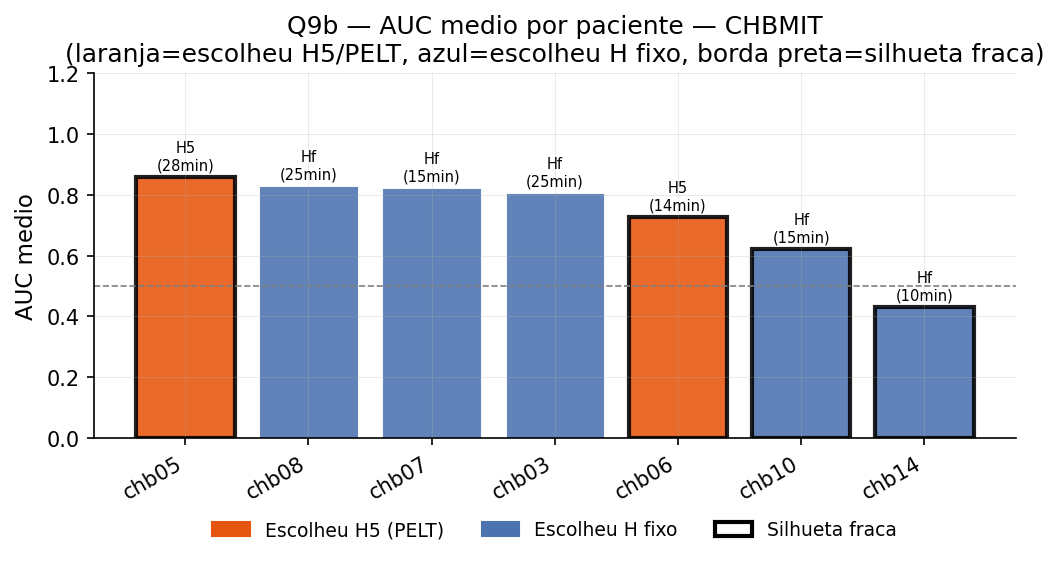

  -> q9b_auc_CHBMIT.png


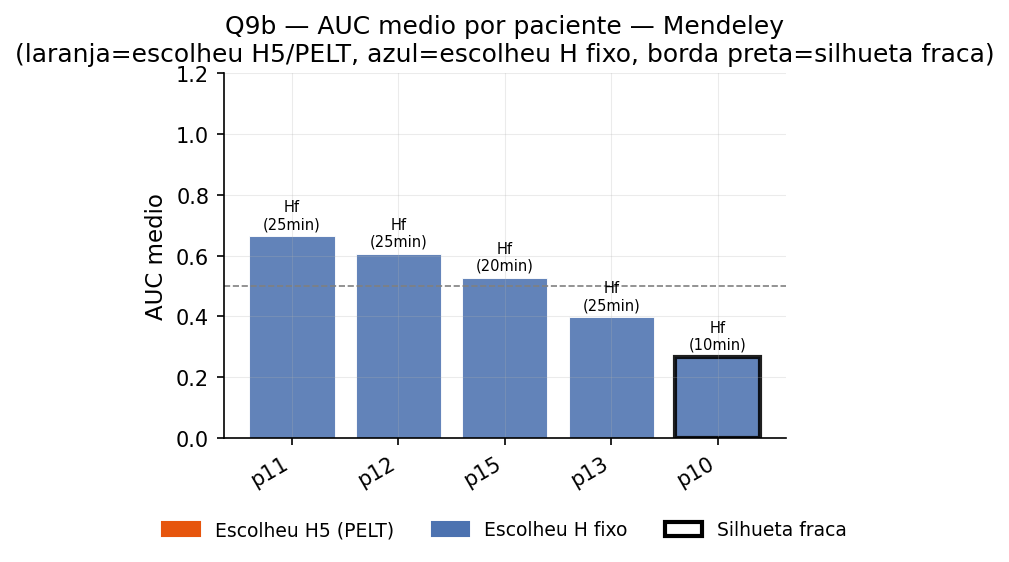

  -> q9b_auc_Mendeley.png


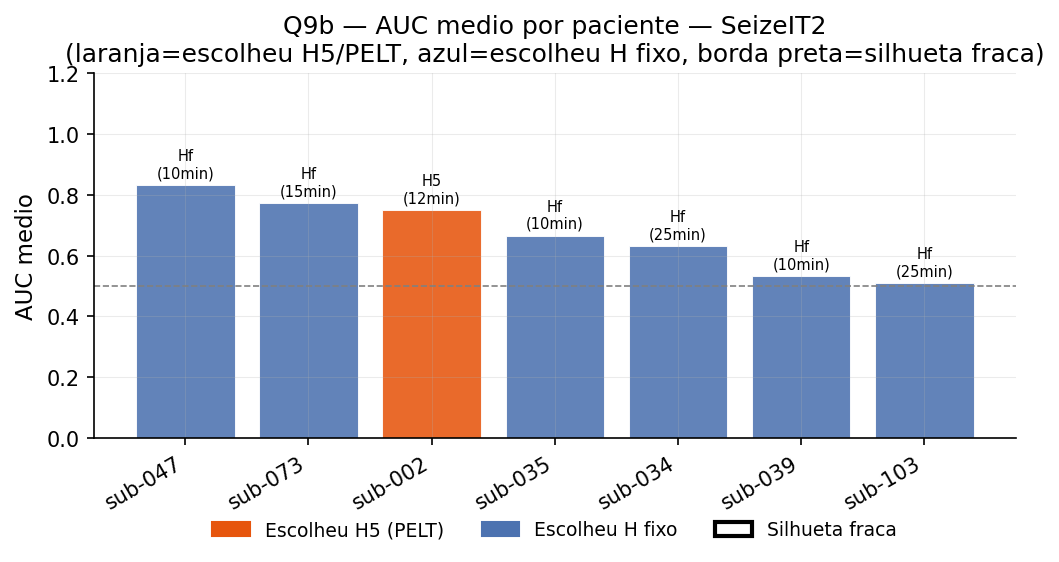

  -> q9b_auc_SeizeIT2.png


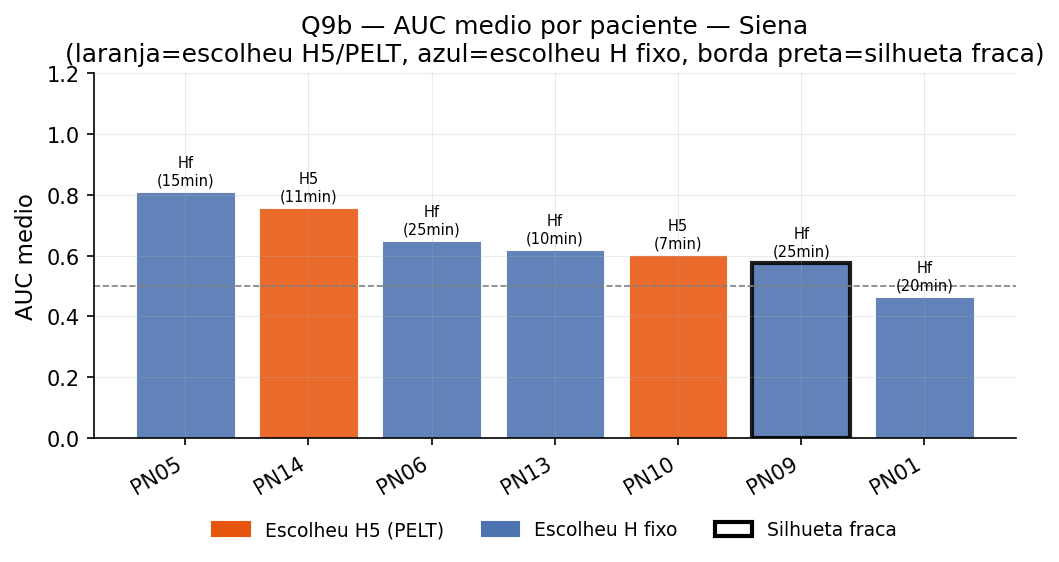

  -> q9b_auc_Siena.png

Q9b — Pacientes que escolheram H5  (N=5): AUC medio = 0.739 ± 0.092
Q9b — Pacientes que escolheram Hfixo (N=21): AUC medio = 0.621 ± 0.157

Q9b — Tabela completa
 dataset paciente  is_h5  auc_medio  pre_sec_min  flag
  CHBMIT    chb03  False      0.807       15.617 False
  CHBMIT    chb05   True      0.858       28.367  True
  CHBMIT    chb06   True      0.727       13.733  True
  CHBMIT    chb07  False      0.823          NaN False
  CHBMIT    chb08  False      0.830          NaN False
  CHBMIT    chb10  False      0.622        8.967  True
  CHBMIT    chb14  False      0.430       18.217  True
Mendeley      p10  False      0.268       18.492  True
Mendeley      p11  False      0.665        5.950 False
Mendeley      p12  False      0.607          NaN False
Mendeley      p13  False      0.398          NaN False
Mendeley      p15  False      0.528          NaN False
SeizeIT2  sub-002   True      0.749       12.250 False
SeizeIT2  sub-034  False      0.630        9

In [72]:
if HAS_PRE:
    df_silh = pd.DataFrame([
        {'dataset':k[0],'paciente':k[1],'silh':v['silhouette'],'flag':v['flag_silh']}
        for k,v in pre_est.items()])

    # ── Q9a: Silhouette por paciente, por dataset ─────────────────────────────
    for ds in sorted(df_silh['dataset'].unique()):
        sub9a = df_silh[df_silh['dataset']==ds].sort_values('silh', ascending=False).reset_index(drop=True)
        fig, ax = plt.subplots(figsize=(max(5, len(sub9a)*0.9), 4))
        colors_9 = ['#e6550d' if f else '#4C72B0' for f in sub9a['flag']]
        ax.bar(range(len(sub9a)), sub9a['silh'].values, color=colors_9, alpha=0.88, edgecolor='white')
        ax.axhline(0.25, color='orange', lw=1.2, ls='--')
        ax.axhline(0.50, color='red',    lw=1.2, ls='--')
        ax.set_xticks(range(len(sub9a)))
        ax.set_xticklabels(sub9a['paciente'].values, rotation=30, ha='right')
        ax.set_ylabel('Silhouette Score'); ax.set_ylim(0, 1)
        ax.set_title(f'Q9a — Silhouette do PELT por paciente — {ds}')
        leg(ax, [mpatches.Patch(color='#e6550d', label='Silhueta fraca (flag=True)'),
                 mpatches.Patch(color='#4C72B0', label='Silhueta OK'),
                 mpatches.Patch(color='orange',  label='Limiar operacional (0.25)'),
                 mpatches.Patch(color='red',      label='Limiar sinalizacao (0.5)')], ncol=2)
        fig.tight_layout(); savefig(f'q9a_silhueta_{ds}')
    ptab(df_silh.sort_values(['dataset','silh'], ascending=[True,False]).round(3), 'Q9a — Silhouette')

    # ── Q9b: AUC por paciente colorido por escolha (H5 vs H fixo) ────────────
    # Cada paciente escolhe UM horizonte para todos os seus folds.
    # Comparamos o AUC medio de pacientes que escolheram H5 vs H fixo.
    # Borda preta = silhueta fraca.
    fixos_s = {600, 900, 1200, 1500}
    s1_q9 = s1.copy()
    s1_q9['is_h5'] = ~s1_q9['chosen_W_s'].round().astype(int).isin(fixos_s)
    auc_pp_q9 = s1_q9.groupby(['dataset','paciente']).agg(
        auc_medio=('auc', 'mean'),
        is_h5=('is_h5', 'first'),
        chosen_W_s=('chosen_W_s', 'first')
    ).reset_index()
    auc_pp_q9['flag'] = auc_pp_q9.apply(
        lambda r: pre_est.get((r['dataset'], r['paciente']), {}).get('flag_silh', False), axis=1)
    auc_pp_q9['pre_sec_min'] = auc_pp_q9.apply(
        lambda r: pre_est.get((r['dataset'], r['paciente']), {}).get('pre_sec', np.nan) / 60, axis=1)

    for ds in sorted(auc_pp_q9['dataset'].unique()):
        sub9b = auc_pp_q9[auc_pp_q9['dataset']==ds].sort_values('auc_medio', ascending=False).reset_index(drop=True)
        n_pats = len(sub9b)
        fig, ax = plt.subplots(figsize=(max(5, n_pats*1.0), 4))
        for j, row in sub9b.iterrows():
            clr  = '#e6550d' if row['is_h5'] else '#4C72B0'
            edge = 'black' if row['flag'] else 'white'
            lw_  = 2.0     if row['flag'] else 0.5
            ax.bar(j, row['auc_medio'], color=clr, edgecolor=edge, linewidth=lw_, alpha=0.88)
            if row['is_h5']:
                pre_s = row['pre_sec_min']
                hl = f"H5\n({pre_s:.0f}min)" if not np.isnan(pre_s) else "H5"
            else:
                hl = f"Hf\n({int(round(row['chosen_W_s']))//60}min)"
            ax.text(j, row['auc_medio'] + 0.025, hl, ha='center', fontsize=7)
        ax.axhline(0.5, color='gray', lw=0.8, ls='--')
        ax.set_xticks(range(n_pats))
        ax.set_xticklabels(sub9b['paciente'].values, rotation=30, ha='right')
        ax.set_ylabel('AUC medio'); ax.set_ylim(0, 1.2)
        ax.set_title(f'Q9b — AUC medio por paciente — {ds}\n'
                     f'(laranja=escolheu H5/PELT, azul=escolheu H fixo, borda preta=silhueta fraca)')
        leg(ax, [mpatches.Patch(color='#e6550d', label='Escolheu H5 (PELT)'),
                 mpatches.Patch(color='#4C72B0', label='Escolheu H fixo'),
                 mpatches.Patch(facecolor='white', edgecolor='black', linewidth=2, label='Silhueta fraca')],
            ncol=3)
        fig.tight_layout(); savefig(f'q9b_auc_{ds}')

    # Resumo numerico
    h5_pats  = auc_pp_q9[auc_pp_q9['is_h5']]
    hfx_pats = auc_pp_q9[~auc_pp_q9['is_h5']]
    print(f'\nQ9b — Pacientes que escolheram H5  (N={len(h5_pats)}): '
          f'AUC medio = {h5_pats["auc_medio"].mean():.3f} ± {h5_pats["auc_medio"].std():.3f}')
    print(f'Q9b — Pacientes que escolheram Hfixo (N={len(hfx_pats)}): '
          f'AUC medio = {hfx_pats["auc_medio"].mean():.3f} ± {hfx_pats["auc_medio"].std():.3f}')
    ptab(auc_pp_q9[['dataset','paciente','is_h5','auc_medio','pre_sec_min','flag']].round(3),
         'Q9b — Tabela completa')
else:
    print('preictal_estimate.json nao encontrado em data/.')


## Q10 — Contextos válidos por paciente (N folds LOSO)

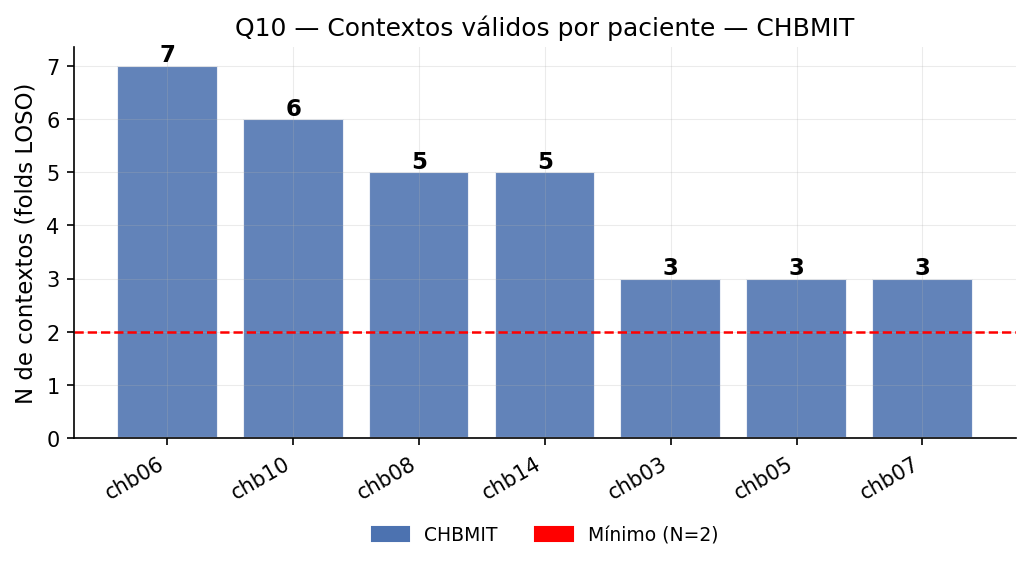

  -> q10_ctx_CHBMIT.png


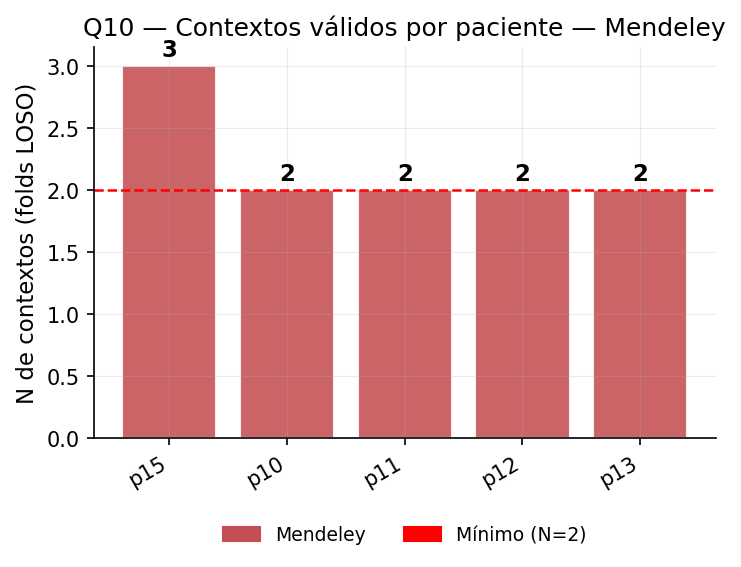

  -> q10_ctx_Mendeley.png


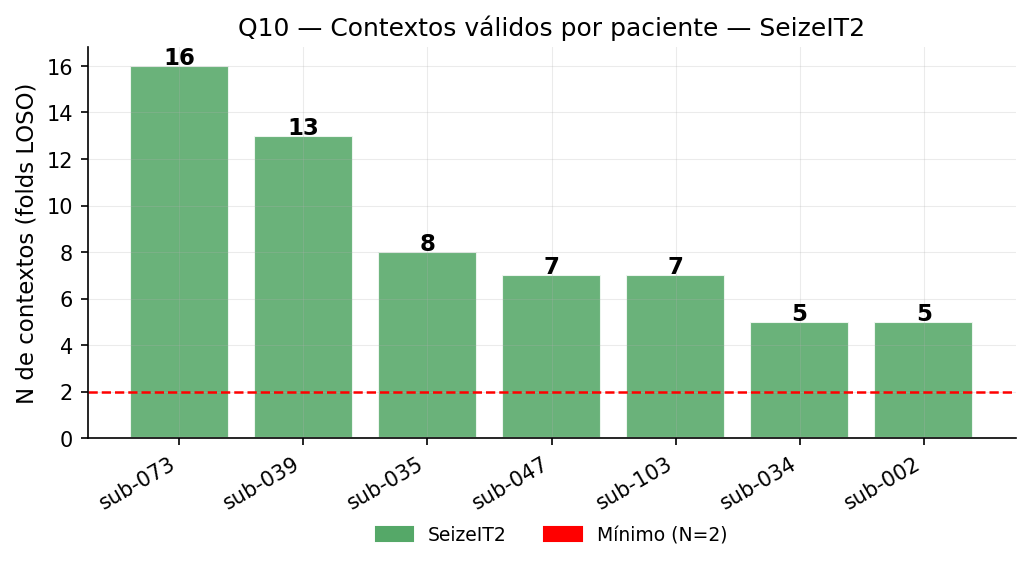

  -> q10_ctx_SeizeIT2.png


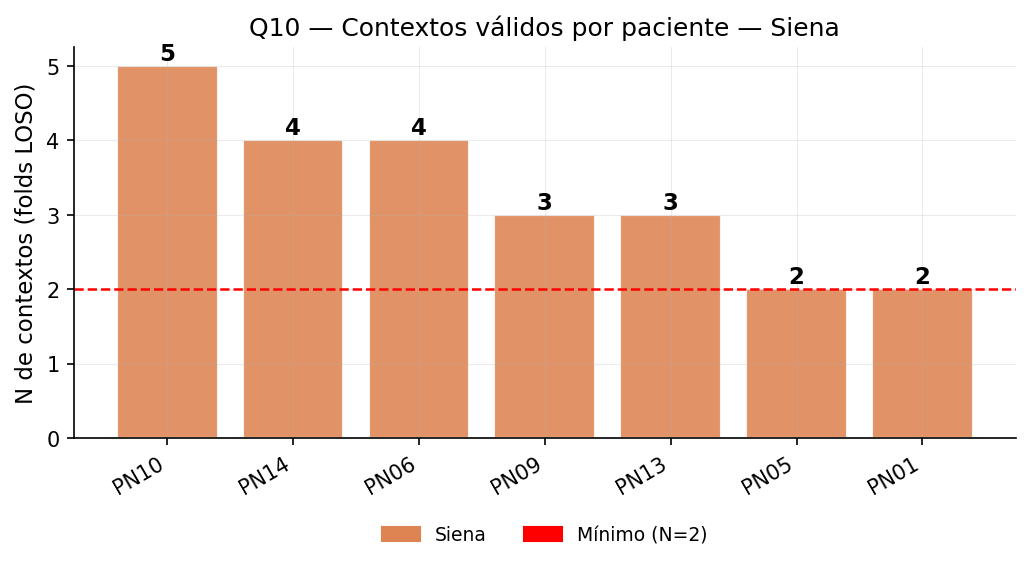

  -> q10_ctx_Siena.png

Q10 — N contextos por paciente
 dataset paciente  n_ctx
  CHBMIT    chb06      7
  CHBMIT    chb10      6
  CHBMIT    chb08      5
  CHBMIT    chb14      5
  CHBMIT    chb03      3
  CHBMIT    chb05      3
  CHBMIT    chb07      3
Mendeley      p15      3
Mendeley      p10      2
Mendeley      p11      2
Mendeley      p12      2
Mendeley      p13      2
SeizeIT2  sub-073     16
SeizeIT2  sub-039     13
SeizeIT2  sub-035      8
SeizeIT2  sub-047      7
SeizeIT2  sub-103      7
SeizeIT2  sub-002      5
SeizeIT2  sub-034      5
   Siena     PN10      5
   Siena     PN06      4
   Siena     PN14      4
   Siena     PN09      3
   Siena     PN13      3
   Siena     PN01      2
   Siena     PN05      2

Q10 — Estatísticas por dataset
 dataset  mean  min  max
  CHBMIT   4.6    3    7
Mendeley   2.2    2    3
SeizeIT2   8.7    5   16
   Siena   3.3    2    5


In [73]:
n_ctx = s3_rf.groupby(['dataset','paciente'])['fold_ctx'].nunique().reset_index(
    ).rename(columns={'fold_ctx':'n_ctx'})
for ds in sorted(n_ctx['dataset'].unique()):
    sub = n_ctx[n_ctx['dataset']==ds].sort_values('n_ctx', ascending=False)
    fig, ax = plt.subplots(figsize=(max(5,len(sub)*1.0),4))
    bars = ax.bar(sub['paciente'], sub['n_ctx'],
                  color=DC.get(ds,'gray'), alpha=0.88, edgecolor='white')
    ax.axhline(2, color='red', lw=1.2, ls='--')
    ax.set_ylabel('N de contextos (folds LOSO)')
    ax.set_title(f'Q10 — Contextos válidos por paciente — {ds}')
    ax.set_xticklabels(sub['paciente'], rotation=30, ha='right')
    for bar,(_, row) in zip(bars, sub.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.08,
                str(int(row['n_ctx'])), ha='center', fontsize=11, fontweight='bold')
    leg(ax,[mpatches.Patch(color=DC.get(ds,'gray'),label=ds),
            mpatches.Patch(color='red',label='Mínimo (N=2)')], ncol=2)
    fig.tight_layout(); savefig(f'q10_ctx_{ds}')
ptab(n_ctx.sort_values(['dataset','n_ctx'],ascending=[True,False]),'Q10 — N contextos por paciente')
stats_ctx = n_ctx.groupby('dataset')['n_ctx'].agg(['mean','min','max']).round(1)
ptab(stats_ctx.reset_index(),'Q10 — Estatísticas por dataset')


## Q11 — N folds vs AUC e Sensibilidade

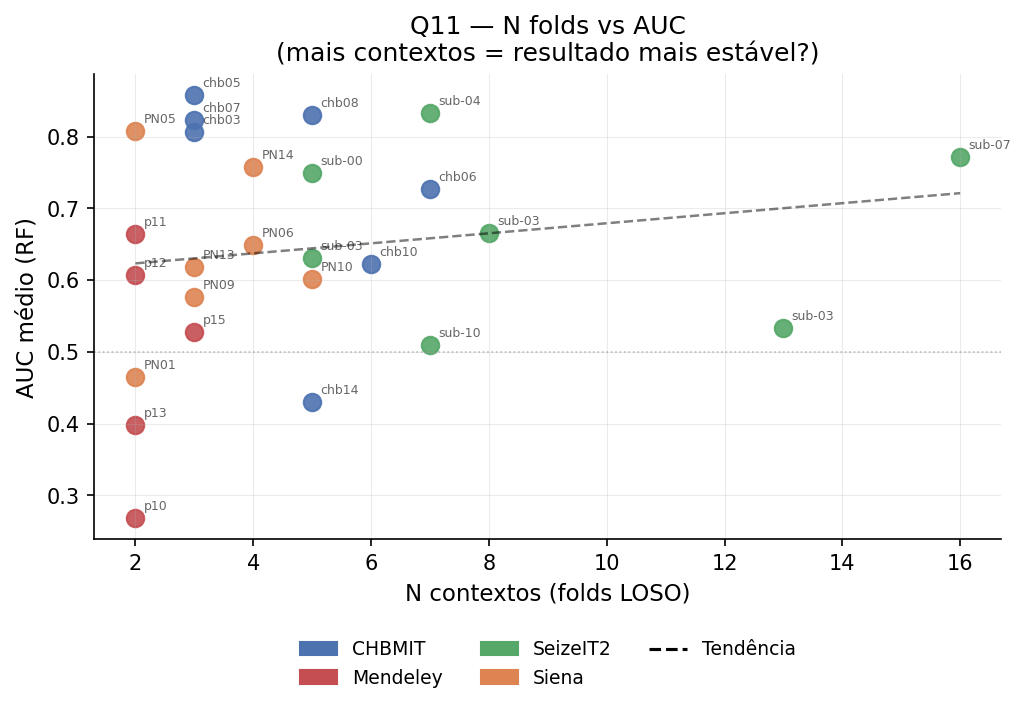

  -> q11a_nfolds_auc.png


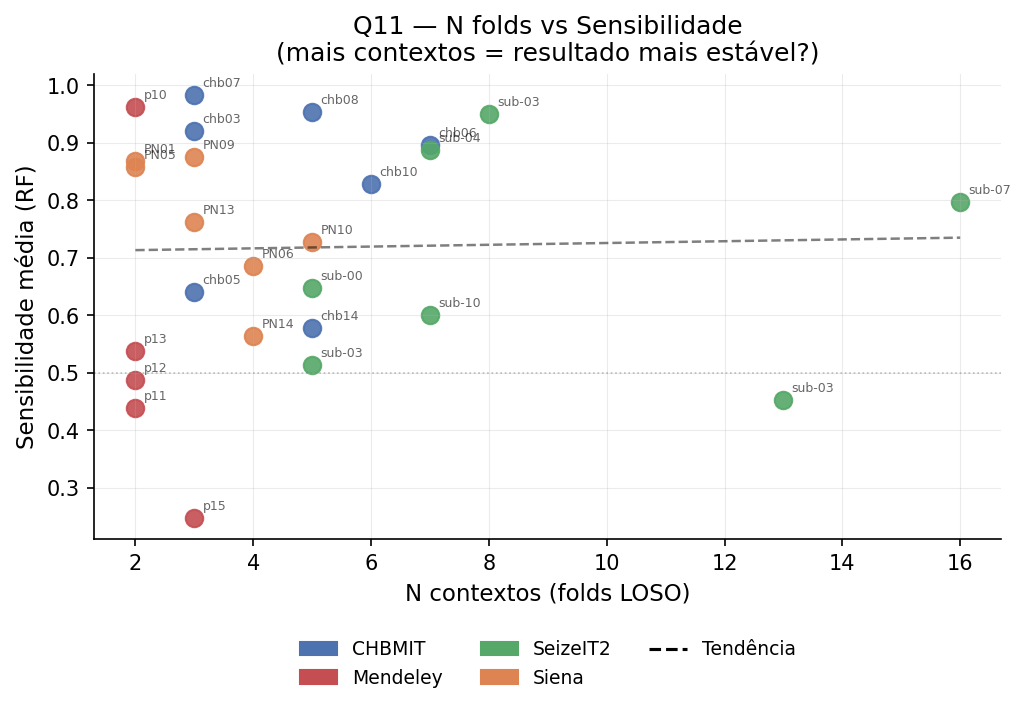

  -> q11b_nfolds_sens.png

Q11
 dataset paciente  n_ctx   auc  sensitivity
  CHBMIT    chb03      3 0.807        0.921
  CHBMIT    chb05      3 0.858        0.641
  CHBMIT    chb06      7 0.727        0.896
  CHBMIT    chb07      3 0.823        0.983
  CHBMIT    chb08      5 0.830        0.954
  CHBMIT    chb10      6 0.622        0.829
  CHBMIT    chb14      5 0.430        0.578
Mendeley      p10      2 0.268        0.962
Mendeley      p11      2 0.665        0.438
Mendeley      p12      2 0.607        0.487
Mendeley      p13      2 0.398        0.537
Mendeley      p15      3 0.528        0.247
SeizeIT2  sub-002      5 0.749        0.648
SeizeIT2  sub-034      5 0.630        0.514
SeizeIT2  sub-035      8 0.666        0.951
SeizeIT2  sub-039     13 0.534        0.453
SeizeIT2  sub-047      7 0.833        0.888
SeizeIT2  sub-073     16 0.772        0.798
SeizeIT2  sub-103      7 0.510        0.601
   Siena     PN01      2 0.464        0.869
   Siena     PN05      2 0.808        0.858
 

In [74]:
n_ctx = s3_rf.groupby(['dataset','paciente'])['fold_ctx'].nunique().reset_index(
    ).rename(columns={'fold_ctx':'n_ctx'})
auc_pp11  = s3_rf.groupby(['dataset','paciente'])['auc'].mean().reset_index()
sens_pp11 = s3_rf.groupby(['dataset','paciente'])['sensitivity'].mean().reset_index()
m11 = n_ctx.merge(auc_pp11,on=['dataset','paciente']).merge(sens_pp11,on=['dataset','paciente'])

for metric, col, ylabel, fname in [
    ('AUC',          'auc',         'AUC médio (RF)',           'q11a_nfolds_auc'),
    ('Sensibilidade', 'sensitivity', 'Sensibilidade média (RF)', 'q11b_nfolds_sens'),
]:
    fig, ax = plt.subplots(figsize=(7,5))
    for ds in sorted(m11['dataset'].unique()):
        s = m11[m11['dataset']==ds]
        ax.scatter(s['n_ctx'], s[col], color=DC.get(ds,'gray'), label=ds, s=70, alpha=0.9)
        for _,row in s.iterrows():
            ax.annotate(row['paciente'][:6],(row['n_ctx'],row[col]),
                        fontsize=6,alpha=0.6,xytext=(4,4),textcoords='offset points')
    if len(m11) >= 3:
        rho,pval = stats.spearmanr(m11['n_ctx'],m11[col])
        mb,bb = np.polyfit(m11['n_ctx'],m11[col],1)
        xs = np.linspace(m11['n_ctx'].min(),m11['n_ctx'].max(),50)
        ax.plot(xs, mb*xs+bb, 'k--', lw=1.2, alpha=0.5,
                label=f'Tendência (rho={rho:.2f}, p={pval:.3f})')
    ax.axhline(0.5, color='gray', lw=0.8, ls=':', alpha=0.5)
    ax.set_xlabel('N contextos (folds LOSO)'); ax.set_ylabel(ylabel)
    ax.set_title(f'Q11 — N folds vs {metric}\n(mais contextos = resultado mais estável?)')
    leg(ax,[mpatches.Patch(color=DC.get(d,'gray'),label=d)
            for d in sorted(m11['dataset'].unique())]+
           [plt.Line2D([0],[0],color='k',ls='--',label='Tendência')], ncol=3)
    fig.tight_layout(); savefig(fname)
ptab(m11[['dataset','paciente','n_ctx','auc','sensitivity']].round(3),'Q11')


## Q12 — Features mais discriminativas (RF)

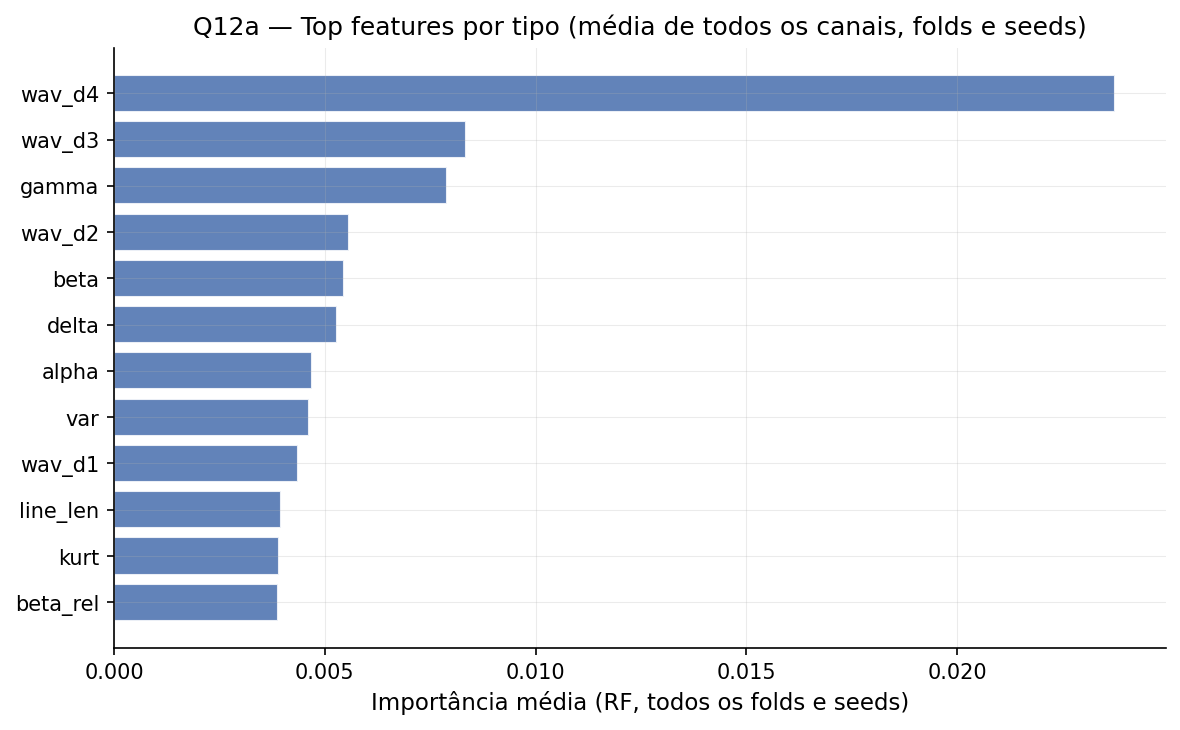

  -> q12a_features_global.png

Q12a — Global
 Feature  Importância
beta_rel       0.0039
    kurt       0.0039
line_len       0.0040
  wav_d1       0.0044
     var       0.0046
   alpha       0.0047
   delta       0.0053
    beta       0.0055
  wav_d2       0.0056
   gamma       0.0079
  wav_d3       0.0084
  wav_d4       0.0238


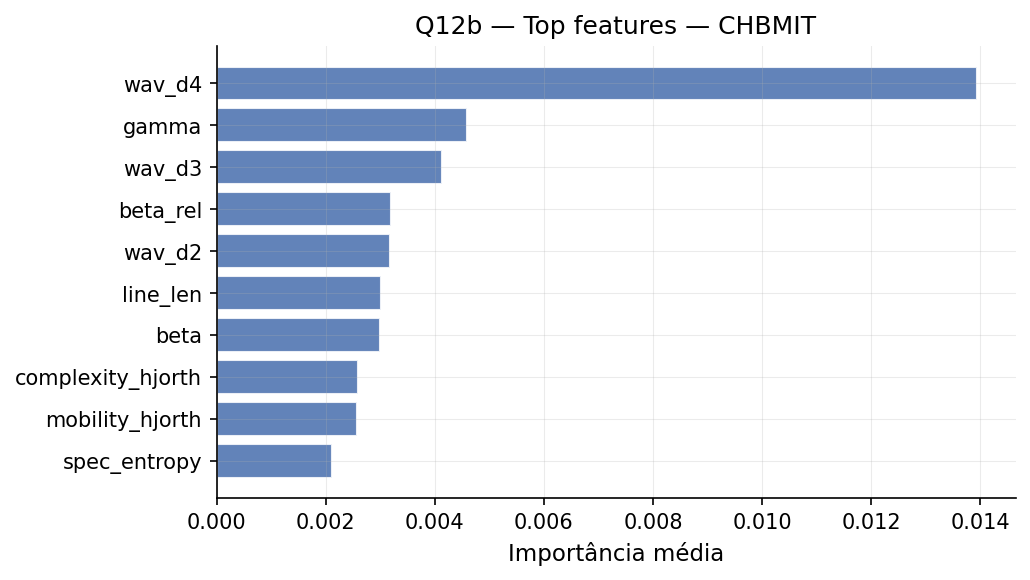

  -> q12b_features_CHBMIT.png

Q12b — CHBMIT
          Feature  Importância
     spec_entropy       0.0021
  mobility_hjorth       0.0026
complexity_hjorth       0.0026
             beta       0.0030
         line_len       0.0030
           wav_d2       0.0032
         beta_rel       0.0032
           wav_d3       0.0041
            gamma       0.0046
           wav_d4       0.0139


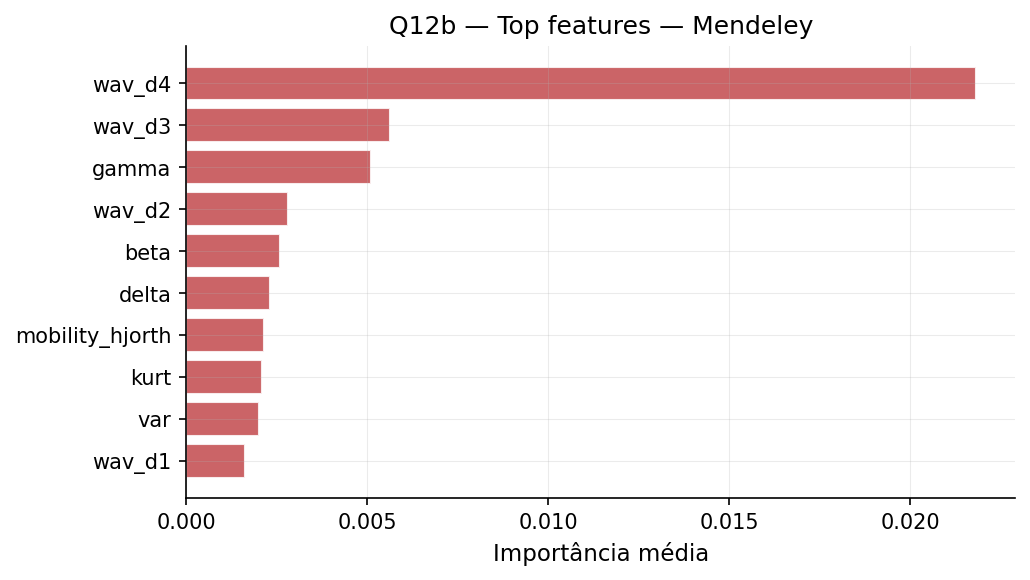

  -> q12b_features_Mendeley.png

Q12b — Mendeley
        Feature  Importância
         wav_d1       0.0016
            var       0.0020
           kurt       0.0021
mobility_hjorth       0.0021
          delta       0.0023
           beta       0.0026
         wav_d2       0.0028
          gamma       0.0051
         wav_d3       0.0056
         wav_d4       0.0218


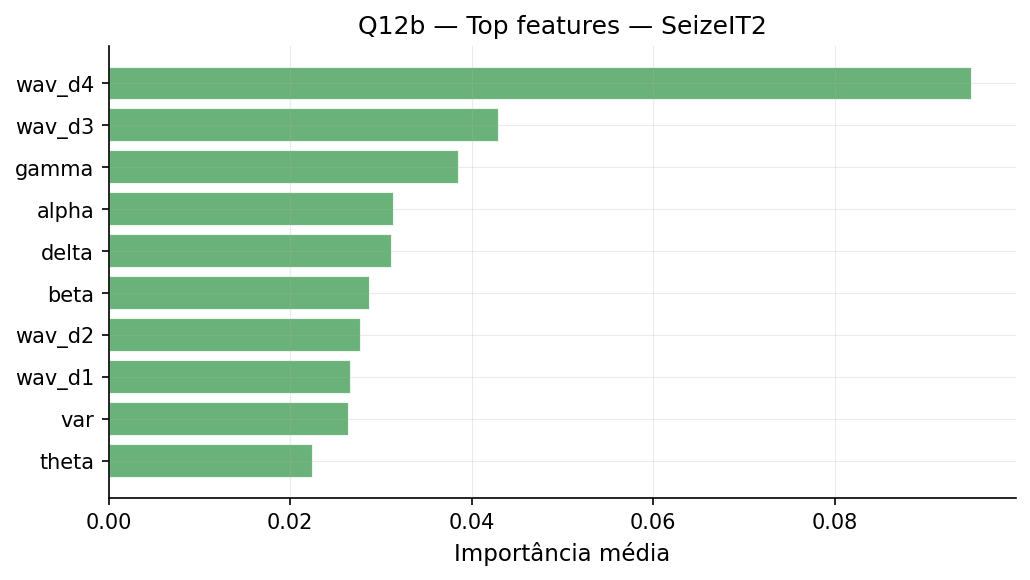

  -> q12b_features_SeizeIT2.png

Q12b — SeizeIT2
Feature  Importância
  theta       0.0225
    var       0.0264
 wav_d1       0.0267
 wav_d2       0.0278
   beta       0.0288
  delta       0.0312
  alpha       0.0314
  gamma       0.0386
 wav_d3       0.0430
 wav_d4       0.0952


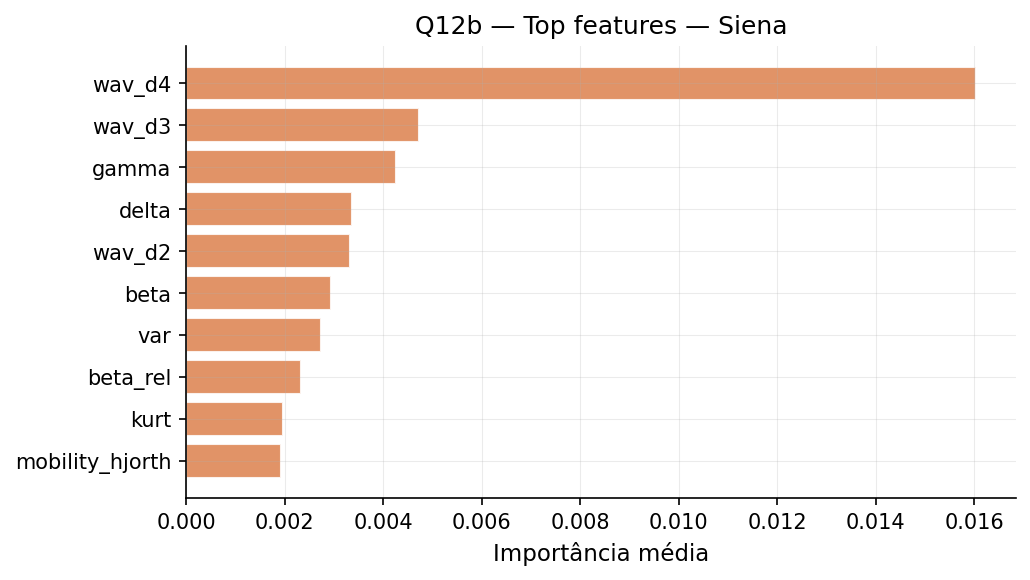

  -> q12b_features_Siena.png

Q12b — Siena
        Feature  Importância
mobility_hjorth       0.0019
           kurt       0.0020
       beta_rel       0.0023
            var       0.0027
           beta       0.0030
         wav_d2       0.0033
          delta       0.0034
          gamma       0.0043
         wav_d3       0.0047
         wav_d4       0.0160


In [75]:
FEAT_NAMES = [
    'std','var','rms','line_len','mobility_hjorth','skew','kurt',
    'delta','theta','alpha','beta','gamma','spec_entropy','beta_rel',
    'wav_d4','wav_d3','wav_d2','wav_d1','complexity_hjorth',
]
def feat_type(code):
    try:
        idx = int(code.replace('f',''))
        return FEAT_NAMES[idx % 19]
    except: return code

if HAS_FI:
    fi_df['feat_type'] = fi_df['feature'].apply(feat_type)

    # Global top-12
    top_g = fi_df.groupby('feat_type')['importance'].mean().nlargest(12).sort_values()
    fig, ax = plt.subplots(figsize=(8,5))
    ax.barh(top_g.index, top_g.values, color='#4C72B0', alpha=0.88, edgecolor='white')
    ax.set_xlabel('Importância média (RF, todos os folds e seeds)')
    ax.set_title('Q12a — Top features por tipo (média de todos os canais, folds e seeds)')
    fig.tight_layout(); savefig('q12a_features_global')
    ptab(top_g.reset_index().rename(columns={'feat_type':'Feature','importance':'Importância'}).round(4),'Q12a — Global')

    # Por dataset
    for ds in sorted(fi_df['dataset'].unique()):
        sub = fi_df[fi_df['dataset']==ds]
        top_ds = sub.groupby('feat_type')['importance'].mean().nlargest(10).sort_values()
        fig, ax = plt.subplots(figsize=(7,4))
        ax.barh(top_ds.index, top_ds.values, color=DC.get(ds,'#4C72B0'), alpha=0.88, edgecolor='white')
        ax.set_xlabel('Importância média'); ax.set_title(f'Q12b — Top features — {ds}')
        fig.tight_layout(); savefig(f'q12b_features_{ds}')
        ptab(top_ds.reset_index().rename(columns={'feat_type':'Feature','importance':'Importância'}).round(4),f'Q12b — {ds}')
else:
    print('Result_feature_importances_rf.csv nao encontrado.')


## Q13 — Consistência da escolha de horizonte entre folds

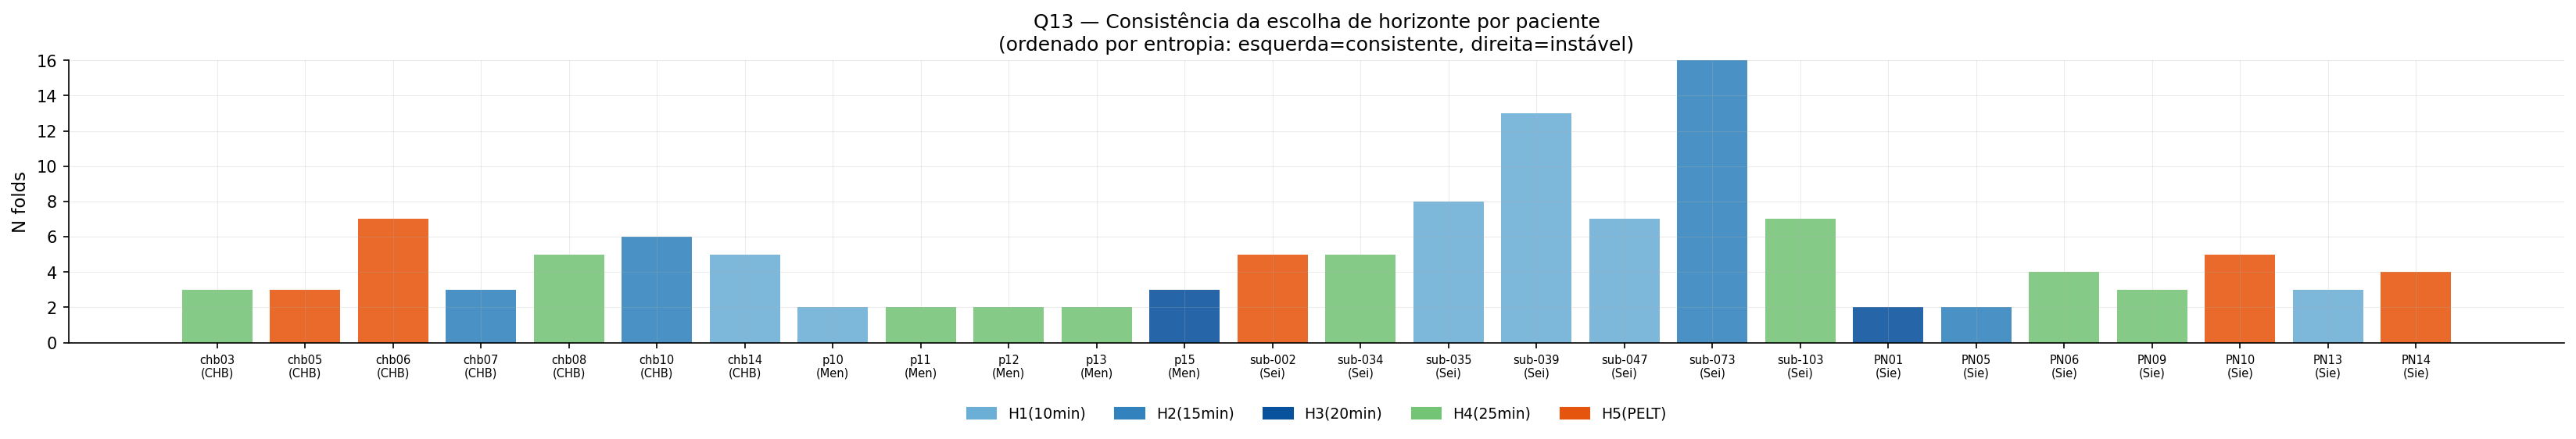

  -> q13_consistencia.png

Q13
      Paciente  Entropia  H1(10min)  H2(15min)  H3(20min)  H4(25min)  H5(PELT)
  chb03\n(CHB)      -0.0          0          0          0          3         0
  chb05\n(CHB)      -0.0          0          0          0          0         3
  chb06\n(CHB)      -0.0          0          0          0          0         7
  chb07\n(CHB)      -0.0          0          3          0          0         0
  chb08\n(CHB)      -0.0          0          0          0          5         0
  chb10\n(CHB)      -0.0          0          6          0          0         0
  chb14\n(CHB)      -0.0          5          0          0          0         0
    p10\n(Men)      -0.0          2          0          0          0         0
    p11\n(Men)      -0.0          0          0          0          2         0
    p12\n(Men)      -0.0          0          0          0          2         0
    p13\n(Men)      -0.0          0          0          0          2         0
    p15\n(Men)      -

In [76]:
s1_q13 = s1.copy()
H6_13 = ['H1(10min)','H2(15min)','H3(20min)','H4(25min)','H5(PELT)']
pivot13 = s1_q13.groupby(['dataset','paciente','horizonte']).size().unstack(fill_value=0).reset_index()
h_cols = [c for c in H6_13 if c in pivot13.columns]
def ent(row):
    v = row[h_cols].values.astype(float); t = v.sum()
    if t==0: return 0.0
    p = v/t; p=p[p>0]; return float(-np.sum(p*np.log2(p)))
pivot13['entropy'] = pivot13.apply(ent, axis=1)
pivot13['label']   = pivot13['paciente'].astype(str)+'\n('+pivot13['dataset'].str[:3]+')'
pivot13 = pivot13.sort_values('entropy').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(max(12,len(pivot13)*0.85),4))
bottom = np.zeros(len(pivot13))
for h in h_cols:
    vals = pivot13[h].values
    ax.bar(range(len(pivot13)), vals, bottom=bottom,
           color=HC6.get(h,'gray'), label=h, alpha=0.88)
    bottom += vals
ax.set_xticks(range(len(pivot13)))
ax.set_xticklabels(pivot13['label'], fontsize=7)
ax.set_ylabel('N folds')
ax.set_title('Q13 — Consistência da escolha de horizonte por paciente\n(ordenado por entropia: esquerda=consistente, direita=instável)')
leg(ax,[mpatches.Patch(color=HC6.get(h,'gray'),label=h) for h in h_cols], ncol=5)
fig.tight_layout(); savefig('q13_consistencia')
ptab(pivot13[['label','entropy']+h_cols].rename(
    columns={'label':'Paciente','entropy':'Entropia'}).round(2),'Q13')


## Q14 — FP/h por janela e por evento

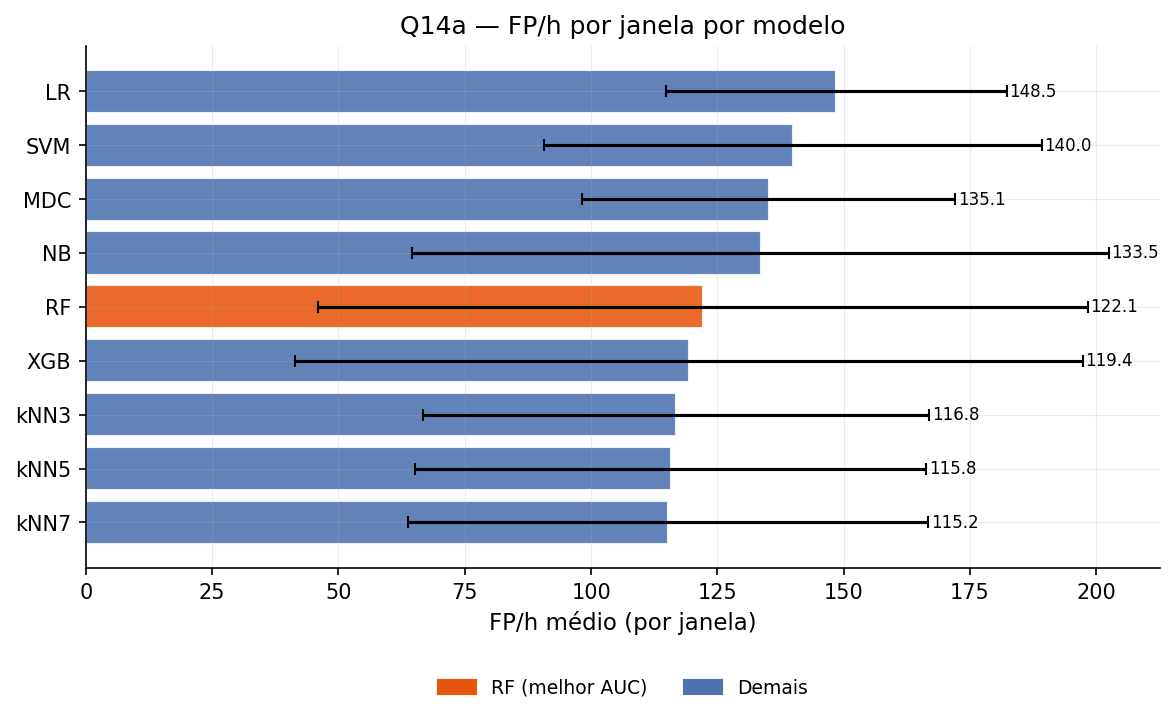

  -> q14a_fph_janela_modelo.png

Q14a
model  FP/h médio   Std
 kNN7      115.22 51.49
 kNN5      115.76 50.62
 kNN3      116.78 50.14
  XGB      119.42 77.93
   RF      122.10 76.21
   NB      133.55 68.92
  MDC      135.12 36.94
  SVM      139.99 49.22
   LR      148.51 33.71


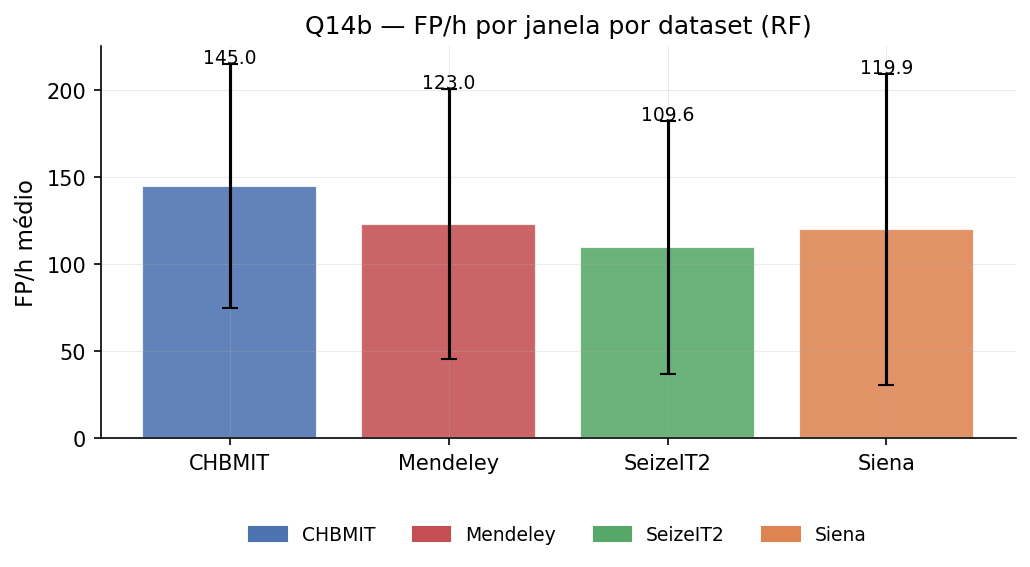

  -> q14b_fph_janela_dataset.png

Q14b
 dataset  FP/h médio   Std
  CHBMIT      145.01 69.97
Mendeley      122.97 77.68
SeizeIT2      109.62 72.91
   Siena      119.94 89.30


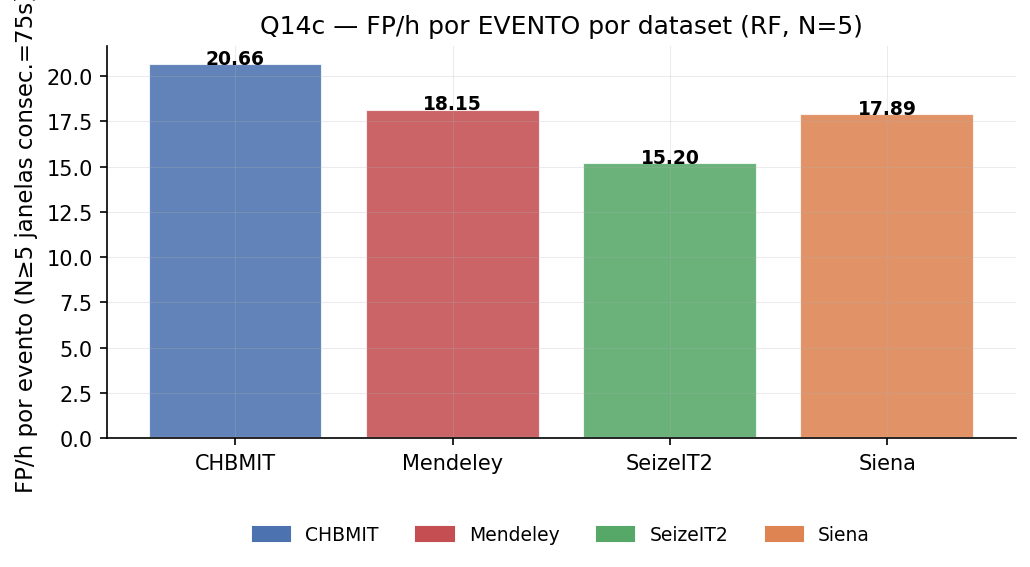

  -> q14c_fph_evento.png

Q14c — FP/h por evento
 dataset  FP/h evento
  CHBMIT       20.664
Mendeley       18.151
SeizeIT2       15.196
   Siena       17.894


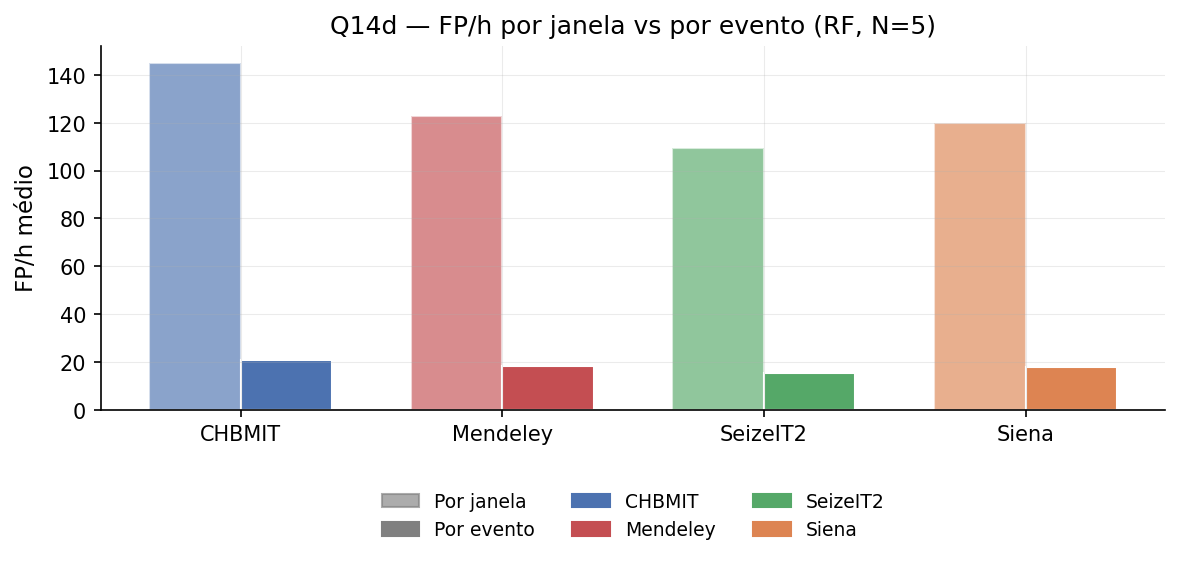

  -> q14d_fph_jan_vs_evento.png


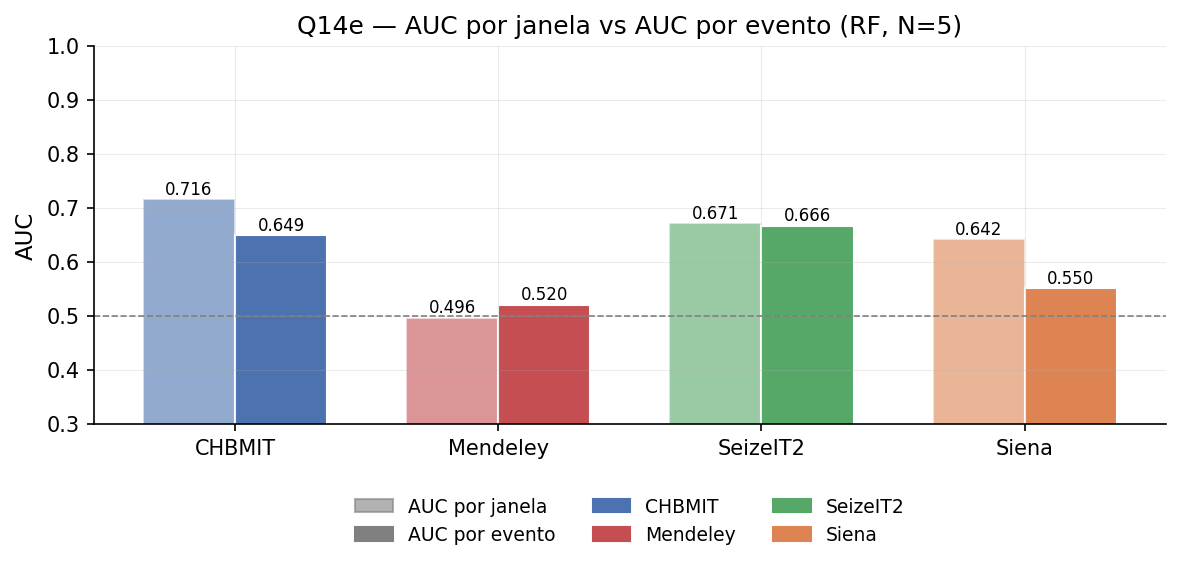

  -> q14e_auc_janela_vs_evento.png

Q14e — AUC por evento
 Dataset  AUC janela  AUC evento
  CHBMIT       0.716       0.649
Mendeley       0.496       0.520
SeizeIT2       0.671       0.666
   Siena       0.642       0.550


In [77]:
# helper: coleta scores maximos de cada evento
def _collect_event_scores(arr_pred, arr_score, N):
    events=[]; run=0; run_sc=[]
    for p,s in zip(arr_pred, arr_score):
        if p==1: run+=1; run_sc.append(s)
        else: run=0; run_sc=[]
        if run==N: events.append(max(run_sc)); run=0; run_sc=[]
    return events

# Q14a — FP/h por janela, por modelo
fph_mod = s3.groupby('model')['fp_h'].agg(['mean','std']).sort_values('mean')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(fph_mod.index, fph_mod['mean'], xerr=fph_mod['std'], capsize=3,
        color=['#e6550d' if m==BEST_MODEL else '#4C72B0' for m in fph_mod.index],
        alpha=0.88, edgecolor='white')
ax.set_xlabel('FP/h médio (por janela)')
ax.set_title('Q14a — FP/h por janela por modelo')
for i,(m,row) in enumerate(fph_mod.iterrows()):
    ax.text(row['mean']+row['std']+0.5, i, f"{row['mean']:.1f}", va='center', fontsize=8)
leg(ax,[mpatches.Patch(color='#e6550d',label=f'{BEST_MODEL} (melhor AUC)'),
        mpatches.Patch(color='#4C72B0',label='Demais')], ncol=2)
fig.tight_layout(); savefig('q14a_fph_janela_modelo')
ptab(fph_mod.rename(columns={'mean':'FP/h médio','std':'Std'}).round(2).reset_index(),'Q14a')

# Q14b — FP/h por janela, por dataset (RF)
fph_ds = s3_rf.groupby('dataset')['fp_h'].agg(['mean','std'])
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(fph_ds.index, fph_ds['mean'], yerr=fph_ds['std'], capsize=4,
       color=[DC.get(d,'gray') for d in fph_ds.index], alpha=0.88, edgecolor='white')
ax.set_ylabel('FP/h médio')
ax.set_title('Q14b — FP/h por janela por dataset (RF)')
for i,(ds,row) in enumerate(fph_ds.iterrows()):
    ax.text(i, row['mean']+row['std']+0.5, f"{row['mean']:.1f}", ha='center', fontsize=9)
leg(ax,[mpatches.Patch(color=DC.get(d,'gray'),label=d) for d in fph_ds.index], ncol=4)
fig.tight_layout(); savefig('q14b_fph_janela_dataset')
ptab(fph_ds.rename(columns={'mean':'FP/h médio','std':'Std'}).round(2).reset_index(),'Q14b')

# Q14c — FP/h por EVENTO (N_CONSEC janelas consecutivas)
if HAS_PREDS:
    preds_rf = preds[preds['model']=='RF'].copy()
    rows_ev14 = []
    for (ds,pat,fold,seed), grp in preds_rf.groupby(['dataset','paciente','fold_ctx','seed']):
        inter_g = grp[grp['is_pre']==0].sort_values('win_idx')
        fp_ev = detect_events(inter_g['pred'].values)
        dur_h = len(inter_g)*WIN_STEP_S/3600
        rows_ev14.append({'dataset':ds,'paciente':pat,'fold_ctx':fold,'seed':seed,
                          'fp_h_event': fp_ev/dur_h if dur_h>0 else np.nan})
    df_ev14 = pd.DataFrame(rows_ev14)
    fph_ev_ds = df_ev14.groupby('dataset')['fp_h_event'].mean()
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(fph_ev_ds.index, fph_ev_ds.values,
           color=[DC.get(d,'gray') for d in fph_ev_ds.index], alpha=0.88, edgecolor='white')
    ax.set_ylabel(f'FP/h por evento (N≥{N_CONSEC} janelas consec.={N_CONSEC*WIN_STEP_S:.0f}s)')
    ax.set_title(f'Q14c — FP/h por EVENTO por dataset (RF, N={N_CONSEC})')
    for i,(ds,v) in enumerate(fph_ev_ds.items()):
        ax.text(i, v+0.01, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
    leg(ax,[mpatches.Patch(color=DC.get(d,'gray'),label=d) for d in fph_ev_ds.index], ncol=4)
    fig.tight_layout(); savefig('q14c_fph_evento')
    ptab(fph_ev_ds.reset_index().rename(columns={'fp_h_event':'FP/h evento'}).round(3),'Q14c — FP/h por evento')

    # Comparativo janela vs evento (RF)
    fph_jan_ds = s3_rf.groupby('dataset')['fp_h'].mean()
    ds_list = sorted(set(fph_jan_ds.index) | set(fph_ev_ds.index))
    x14 = np.arange(len(ds_list)); w14 = 0.35
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(x14-w14/2, [fph_jan_ds.get(d,np.nan) for d in ds_list], w14,
           color=[DC.get(d,'gray') for d in ds_list], alpha=0.65, edgecolor='white', label='Por janela')
    ax.bar(x14+w14/2, [fph_ev_ds.get(d,np.nan)  for d in ds_list], w14,
           color=[DC.get(d,'gray') for d in ds_list], alpha=1.0,  edgecolor='white', label='Por evento')
    ax.set_xticks(x14); ax.set_xticklabels(ds_list)
    ax.set_ylabel('FP/h médio')
    ax.set_title(f'Q14d — FP/h por janela vs por evento (RF, N={N_CONSEC})')
    leg(ax,[mpatches.Patch(color='gray',alpha=0.65,label='Por janela'),
            mpatches.Patch(color='gray',alpha=1.0, label='Por evento')]+
           [mpatches.Patch(color=DC.get(d,'gray'),label=d) for d in ds_list], ncol=3)
    fig.tight_layout(); savefig('q14d_fph_jan_vs_evento')

    # Q14e — AUC por evento
    # Score do evento = max(score das janelas do evento pre-ictal)
    # vs score maximo de cada evento interictal (FP)
    rows_auc_ev = []
    for (ds, pat, fold, seed), grp in preds_rf.groupby(['dataset','paciente','fold_ctx','seed']):
        pre_g   = grp[grp['is_pre']==1].sort_values('win_idx')
        inter_g = grp[grp['is_pre']==0].sort_values('win_idx')
        # Coleta scores de eventos pre-ictais (positivos)
        pre_evs  = _collect_event_scores(pre_g['pred'].values,   pre_g['score'].values,   N_CONSEC)
        inter_evs= _collect_event_scores(inter_g['pred'].values, inter_g['score'].values, N_CONSEC)
        if len(pre_evs) + len(inter_evs) < 2: continue
        y_ev     = [1]*len(pre_evs)  + [0]*len(inter_evs)
        score_ev = pre_evs + inter_evs
        if len(set(y_ev)) < 2: continue
        from sklearn.metrics import roc_auc_score as _ras
        auc_ev = _ras(y_ev, score_ev)
        rows_auc_ev.append({'dataset':ds,'paciente':pat,'fold_ctx':fold,'seed':seed,'auc_event':auc_ev})
    if rows_auc_ev:
        df_auc_ev = pd.DataFrame(rows_auc_ev)
        auc_ev_ds = df_auc_ev.groupby('dataset')['auc_event'].mean()
        auc_jan_ds = s3_rf.groupby('dataset')['auc'].mean()
        ds_list_e = sorted(set(auc_ev_ds.index)|set(auc_jan_ds.index))
        x_e = np.arange(len(ds_list_e)); w_e = 0.35
        fig, ax = plt.subplots(figsize=(8,4))
        ax.bar(x_e-w_e/2, [auc_jan_ds.get(d,np.nan) for d in ds_list_e], w_e,
               color=[DC.get(d,'gray') for d in ds_list_e], alpha=0.6, edgecolor='white', label='AUC por janela')
        ax.bar(x_e+w_e/2, [auc_ev_ds.get(d,np.nan)  for d in ds_list_e], w_e,
               color=[DC.get(d,'gray') for d in ds_list_e], alpha=1.0, edgecolor='white', label='AUC por evento')
        for i,(j,e) in enumerate(zip([auc_jan_ds.get(d,np.nan) for d in ds_list_e],
                                      [auc_ev_ds.get(d,np.nan)  for d in ds_list_e])):
            if not np.isnan(j): ax.text(i-w_e/2, j+0.01, f'{j:.3f}', ha='center', fontsize=8)
            if not np.isnan(e): ax.text(i+w_e/2, e+0.01, f'{e:.3f}', ha='center', fontsize=8)
        ax.set_xticks(x_e); ax.set_xticklabels(ds_list_e)
        ax.axhline(0.5, color='gray', lw=0.8, ls='--')
        ax.set_ylim(0.3,1.0); ax.set_ylabel('AUC')
        ax.set_title(f'Q14e — AUC por janela vs AUC por evento (RF, N={N_CONSEC})')
        ax.legend(handles=[mpatches.Patch(color='gray',alpha=0.6,label='AUC por janela'),
                            mpatches.Patch(color='gray',alpha=1.0,label='AUC por evento')]+
                           [mpatches.Patch(color=DC.get(d,'gray'),label=d) for d in ds_list_e],
                  loc='upper center', bbox_to_anchor=(0.5,-0.15), ncol=3, fontsize=9, frameon=False)
        fig.tight_layout(); savefig('q14e_auc_janela_vs_evento')
        ptab(pd.DataFrame({'Dataset':ds_list_e,
             'AUC janela':[auc_jan_ds.get(d,np.nan) for d in ds_list_e],
             'AUC evento':[auc_ev_ds.get(d,np.nan)  for d in ds_list_e]}).round(3),'Q14e — AUC por evento')

else:
    print('Result_predictions_per_window.csv nao encontrado.')


## Q15 — Sensibilidade: por janela e por evento

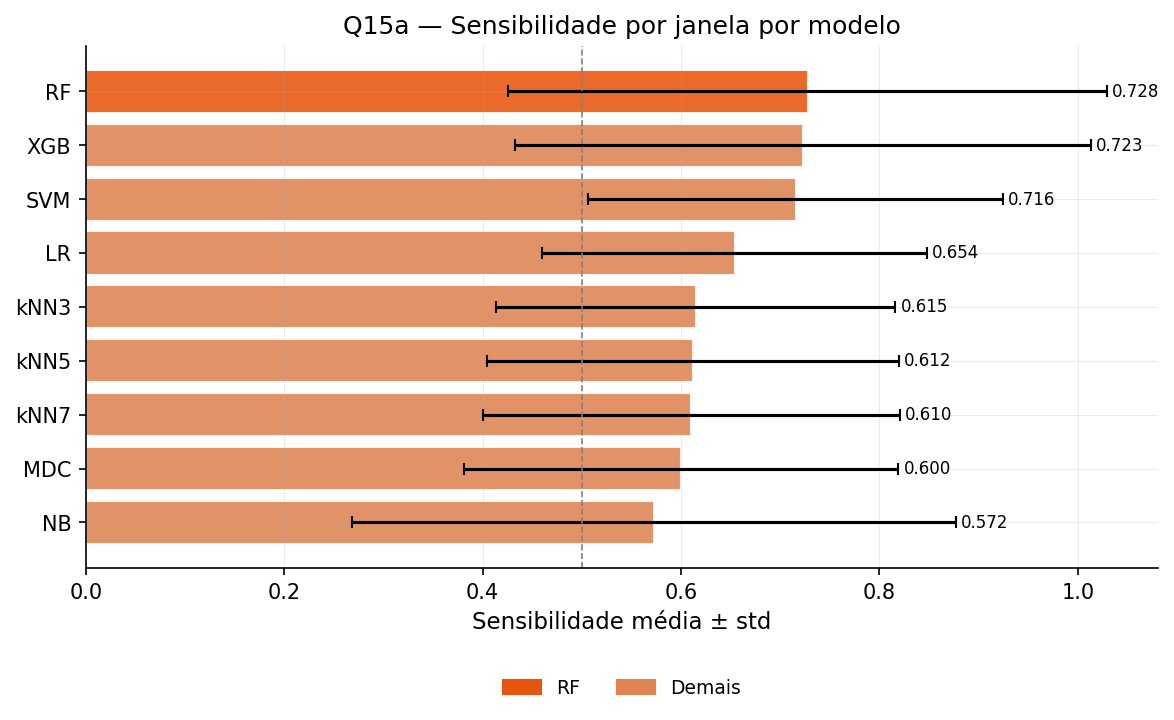

  -> q15a_sens_janela_modelo.png

Q15a
model  Sensib. média   Std
   NB          0.572 0.305
  MDC          0.600 0.219
 kNN7          0.610 0.210
 kNN5          0.612 0.208
 kNN3          0.615 0.202
   LR          0.654 0.194
  SVM          0.716 0.209
  XGB          0.723 0.291
   RF          0.728 0.302


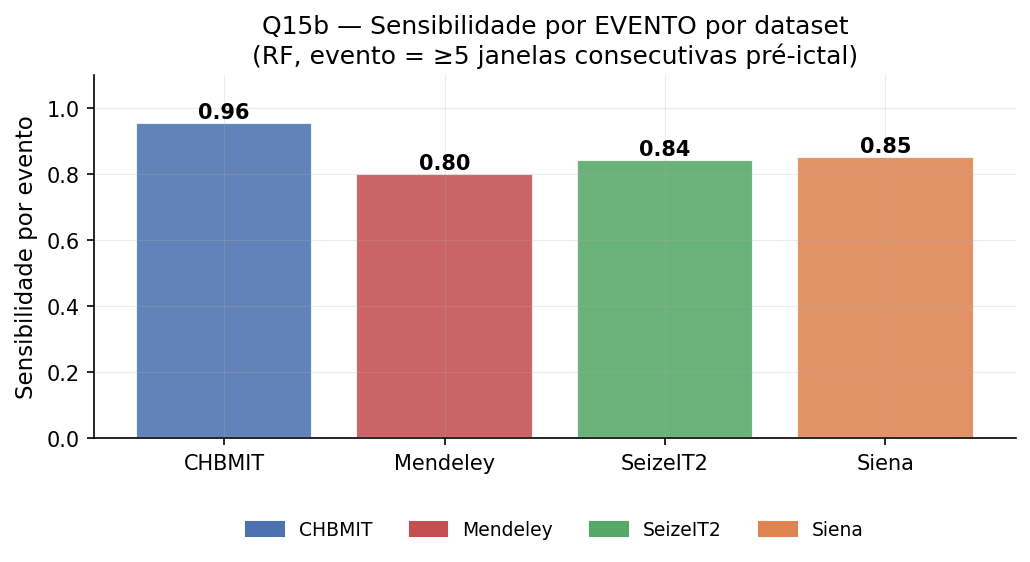

  -> q15b_sens_evento_dataset.png


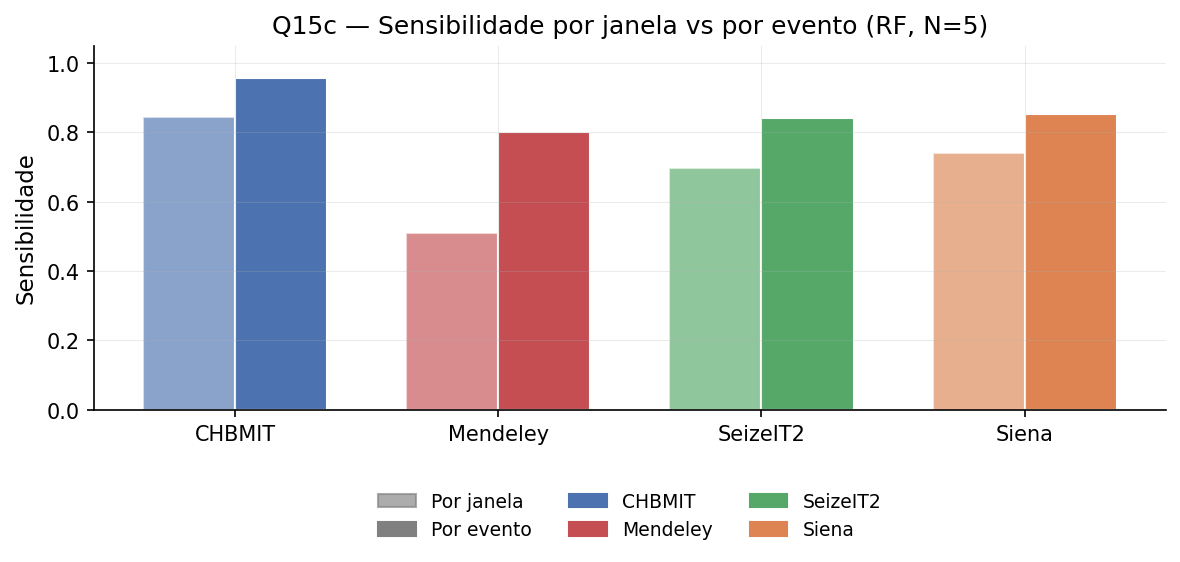

  -> q15c_sens_jan_vs_evento.png

Q15 — Sensibilidade janela vs evento
 Dataset  Sens janela  Sens evento
  CHBMIT        0.843        0.956
Mendeley        0.508        0.800
SeizeIT2        0.697        0.843
   Siena        0.739        0.852


In [78]:
# Q15a — Sensibilidade por janela, por modelo
sens_mod2 = s3.groupby('model')['sensitivity'].agg(['mean','std']).sort_values('mean')
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(sens_mod2.index, sens_mod2['mean'], xerr=sens_mod2['std'], capsize=3,
        color=['#e6550d' if m==BEST_MODEL else '#DD8452' for m in sens_mod2.index],
        alpha=0.88, edgecolor='white')
ax.axvline(0.5, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Sensibilidade média ± std')
ax.set_title('Q15a — Sensibilidade por janela por modelo')
for i,(m,row) in enumerate(sens_mod2.iterrows()):
    ax.text(row['mean']+row['std']+0.005, i, f"{row['mean']:.3f}", va='center', fontsize=8)
leg(ax,[mpatches.Patch(color='#e6550d',label=f'{BEST_MODEL}'),
        mpatches.Patch(color='#DD8452',label='Demais')], ncol=2)
fig.tight_layout(); savefig('q15a_sens_janela_modelo')
ptab(sens_mod2.rename(columns={'mean':'Sensib. média','std':'Std'}).round(3).reset_index(),'Q15a')

if HAS_PREDS:
    # Q15b — Sensibilidade por evento: pelo menos 1 evento detectado no pre-ictal
    rows_se = []
    for (ds,pat,fold,seed), grp in preds[preds['model']=='RF'].groupby(
            ['dataset','paciente','fold_ctx','seed']):
        pre_g = grp[grp['is_pre']==1].sort_values('win_idx')
        detected = int(detect_events(pre_g['pred'].values) >= 1)
        rows_se.append({'dataset':ds,'paciente':pat,'fold_ctx':fold,'seed':seed,'detected':detected})
    df_se = pd.DataFrame(rows_se)
    sens_ev_ds = df_se.groupby('dataset')['detected'].mean()

    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(sens_ev_ds.index, sens_ev_ds.values,
           color=[DC.get(d,'gray') for d in sens_ev_ds.index], alpha=0.88, edgecolor='white')
    ax.set_ylim(0,1.1); ax.set_ylabel('Sensibilidade por evento')
    ax.set_title(f'Q15b — Sensibilidade por EVENTO por dataset\n(RF, evento = ≥{N_CONSEC} janelas consecutivas pré-ictal)')
    for i,(ds,v) in enumerate(sens_ev_ds.items()):
        ax.text(i, v+0.015, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
    leg(ax,[mpatches.Patch(color=DC.get(d,'gray'),label=d) for d in sens_ev_ds.index], ncol=4)
    fig.tight_layout(); savefig('q15b_sens_evento_dataset')

    # Q15c — Comparativo janela vs evento por dataset
    sens_jan_ds = s3_rf.groupby('dataset')['sensitivity'].mean()
    ds_list15 = sorted(set(sens_jan_ds.index)|set(sens_ev_ds.index))
    x15 = np.arange(len(ds_list15)); w15 = 0.35
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(x15-w15/2, [sens_jan_ds.get(d,np.nan) for d in ds_list15], w15,
           color=[DC.get(d,'gray') for d in ds_list15], alpha=0.65, edgecolor='white', label='Por janela')
    ax.bar(x15+w15/2, [sens_ev_ds.get(d,np.nan)  for d in ds_list15], w15,
           color=[DC.get(d,'gray') for d in ds_list15], alpha=1.0,  edgecolor='white', label='Por evento')
    ax.set_xticks(x15); ax.set_xticklabels(ds_list15)
    ax.set_ylim(0,1.05); ax.set_ylabel('Sensibilidade')
    ax.set_title(f'Q15c — Sensibilidade por janela vs por evento (RF, N={N_CONSEC})')
    leg(ax,[mpatches.Patch(color='gray',alpha=0.65,label='Por janela'),
            mpatches.Patch(color='gray',alpha=1.0, label='Por evento')]+
           [mpatches.Patch(color=DC.get(d,'gray'),label=d) for d in ds_list15], ncol=3)
    fig.tight_layout(); savefig('q15c_sens_jan_vs_evento')
    t15 = pd.DataFrame({'Dataset':ds_list15,
        'Sens janela':[sens_jan_ds.get(d,np.nan) for d in ds_list15],
        'Sens evento':[sens_ev_ds.get(d,np.nan)  for d in ds_list15]}).round(3)
    ptab(t15,'Q15 — Sensibilidade janela vs evento')
else:
    print('Result_predictions_per_window.csv nao encontrado.')


## Q16 — Estabilidade do undersample (5 seeds)

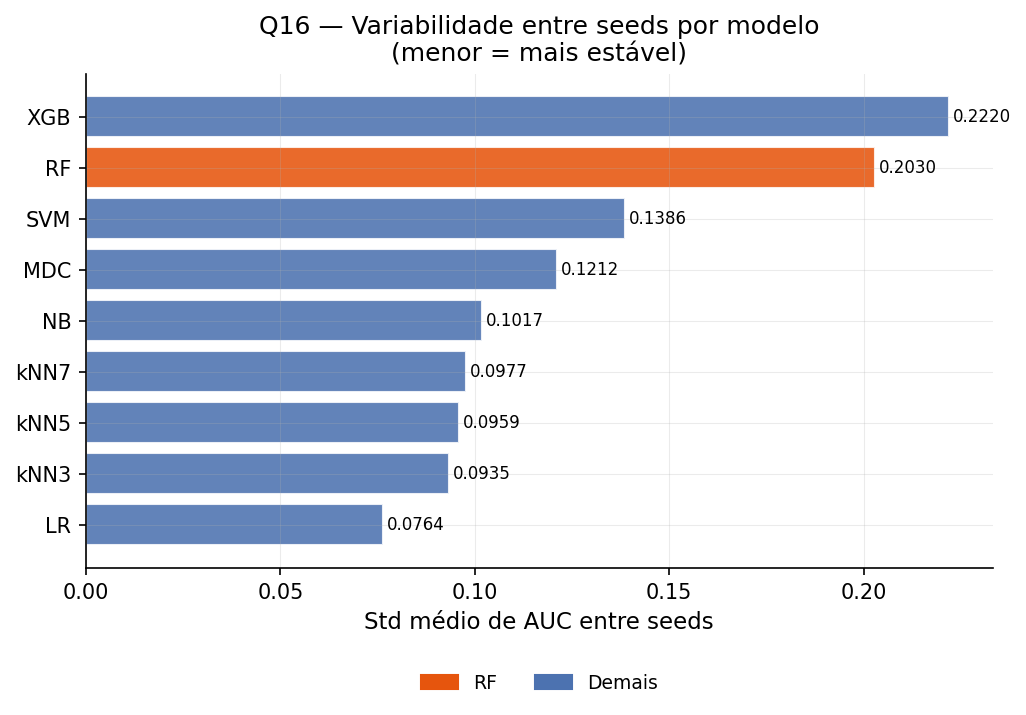

  -> q16_seeds.png

Q16
model    auc
   LR 0.0764
 kNN3 0.0935
 kNN5 0.0959
 kNN7 0.0977
   NB 0.1017
  MDC 0.1212
  SVM 0.1386
   RF 0.2030
  XGB 0.2220


In [79]:
if 'seed' in s3.columns:
    std_s = s3.groupby(['dataset','paciente','model','fold_ctx'])['auc'].std()
    std_mod = std_s.groupby('model').mean().sort_values()
else:
    std_mod = s3.groupby(['dataset','paciente','model'])['auc'].std().groupby('model').mean().sort_values()
fig, ax = plt.subplots(figsize=(7,5))
ax.barh(std_mod.index, std_mod.values,
        color=['#e6550d' if m==BEST_MODEL else '#4C72B0' for m in std_mod.index],
        alpha=0.88, edgecolor='white')
ax.set_xlabel('Std médio de AUC entre seeds')
ax.set_title('Q16 — Variabilidade entre seeds por modelo\n(menor = mais estável)')
for i,(m,v) in enumerate(std_mod.items()):
    ax.text(v+0.001, i, f'{v:.4f}', va='center', fontsize=8)
leg(ax,[mpatches.Patch(color='#e6550d',label=f'{BEST_MODEL}'),
        mpatches.Patch(color='#4C72B0',label='Demais')], ncol=2)
fig.tight_layout(); savefig('q16_seeds')
ptab(std_mod.reset_index().rename(columns={0:'Std médio entre seeds'}).round(4),'Q16')


## Q17 — Variabilidade intra-paciente (entre contextos de crise)

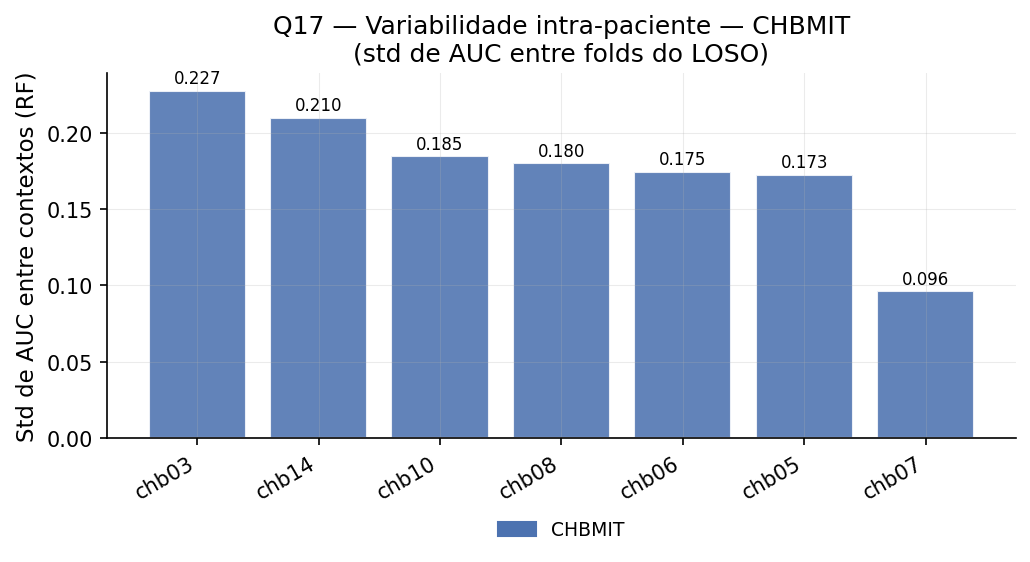

  -> q17_intra_CHBMIT.png

Q17 — CHBMIT
dataset paciente  std_intra
 CHBMIT    chb03      0.227
 CHBMIT    chb14      0.210
 CHBMIT    chb10      0.185
 CHBMIT    chb08      0.180
 CHBMIT    chb06      0.175
 CHBMIT    chb05      0.173
 CHBMIT    chb07      0.096


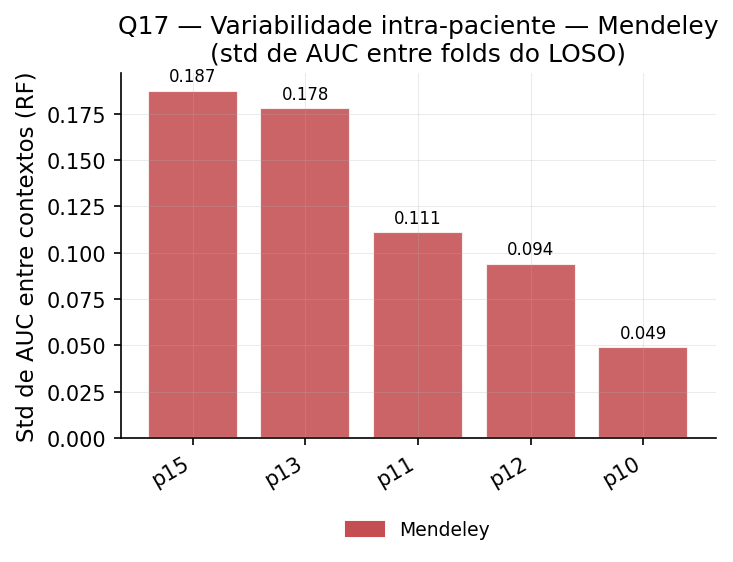

  -> q17_intra_Mendeley.png

Q17 — Mendeley
 dataset paciente  std_intra
Mendeley      p15      0.187
Mendeley      p13      0.178
Mendeley      p11      0.111
Mendeley      p12      0.094
Mendeley      p10      0.049


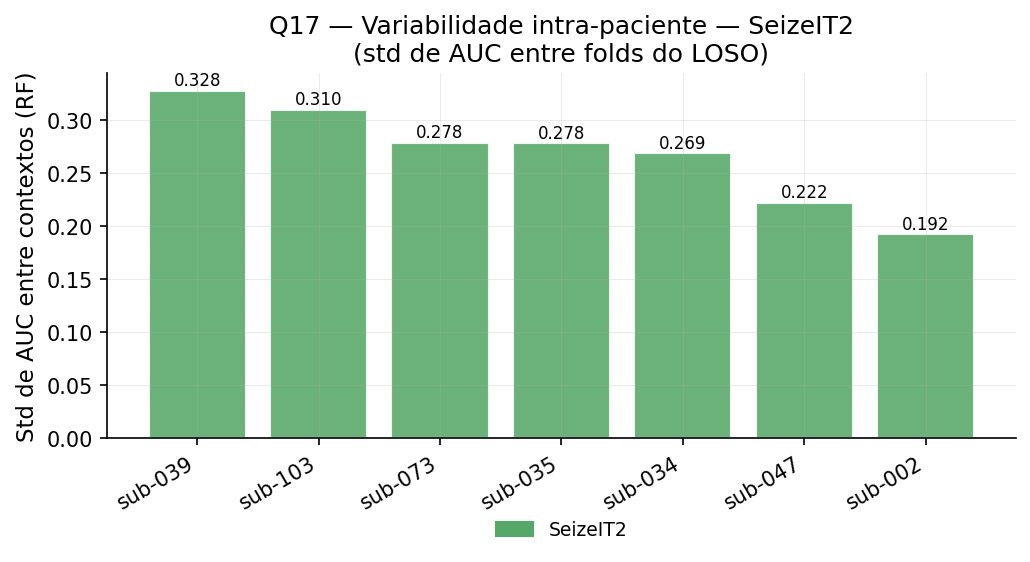

  -> q17_intra_SeizeIT2.png

Q17 — SeizeIT2
 dataset paciente  std_intra
SeizeIT2  sub-039      0.328
SeizeIT2  sub-103      0.310
SeizeIT2  sub-073      0.278
SeizeIT2  sub-035      0.278
SeizeIT2  sub-034      0.269
SeizeIT2  sub-047      0.222
SeizeIT2  sub-002      0.192


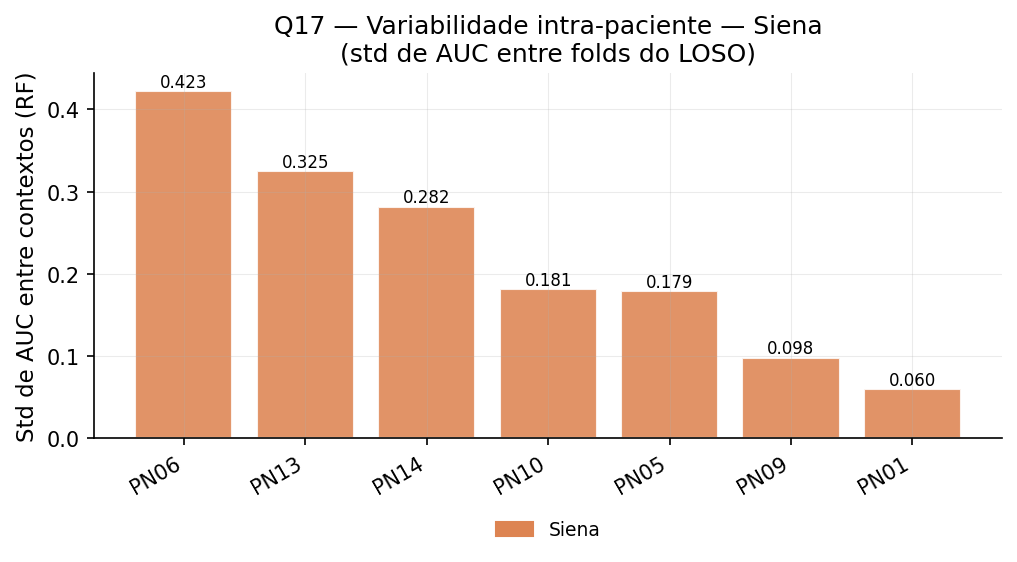

  -> q17_intra_Siena.png

Q17 — Siena
dataset paciente  std_intra
  Siena     PN06      0.423
  Siena     PN13      0.325
  Siena     PN14      0.282
  Siena     PN10      0.181
  Siena     PN05      0.179
  Siena     PN09      0.098
  Siena     PN01      0.060

Q17 — Estatísticas por dataset
 dataset  mean   std   min   max
  CHBMIT 0.178 0.041 0.096 0.227
Mendeley 0.124 0.058 0.049 0.187
SeizeIT2 0.268 0.047 0.192 0.328
   Siena 0.221 0.129 0.060 0.423


In [80]:
auc_fold = s3_rf.groupby(['dataset','paciente','fold_ctx'])['auc'].mean().reset_index()
std_intra = auc_fold.groupby(['dataset','paciente'])['auc'].std().reset_index(
    ).rename(columns={'auc':'std_intra'})
for ds in sorted(std_intra['dataset'].unique()):
    sub = std_intra[std_intra['dataset']==ds].sort_values('std_intra',ascending=False)
    fig, ax = plt.subplots(figsize=(max(5,len(sub)*1.0),4))
    ax.bar(sub['paciente'], sub['std_intra'],
           color=DC.get(ds,'gray'), alpha=0.88, edgecolor='white')
    ax.set_ylabel('Std de AUC entre contextos (RF)')
    ax.set_title(f'Q17 — Variabilidade intra-paciente — {ds}\n(std de AUC entre folds do LOSO)')
    ax.set_xticklabels(sub['paciente'], rotation=30, ha='right')
    for _,row in sub.iterrows():
        idx = list(sub['paciente']).index(row['paciente'])
        ax.text(idx, row['std_intra']+0.005, f"{row['std_intra']:.3f}", ha='center', fontsize=8)
    leg(ax,[mpatches.Patch(color=DC.get(ds,'gray'),label=ds)], ncol=1)
    fig.tight_layout(); savefig(f'q17_intra_{ds}')
    ptab(sub.round(3),'Q17 — '+ds)
ptab(std_intra.groupby('dataset')['std_intra'].agg(['mean','std','min','max']).round(3).reset_index(),
     'Q17 — Estatísticas por dataset')


## Q18 — PRE_SEC estimado pelo PELT varia por dataset?

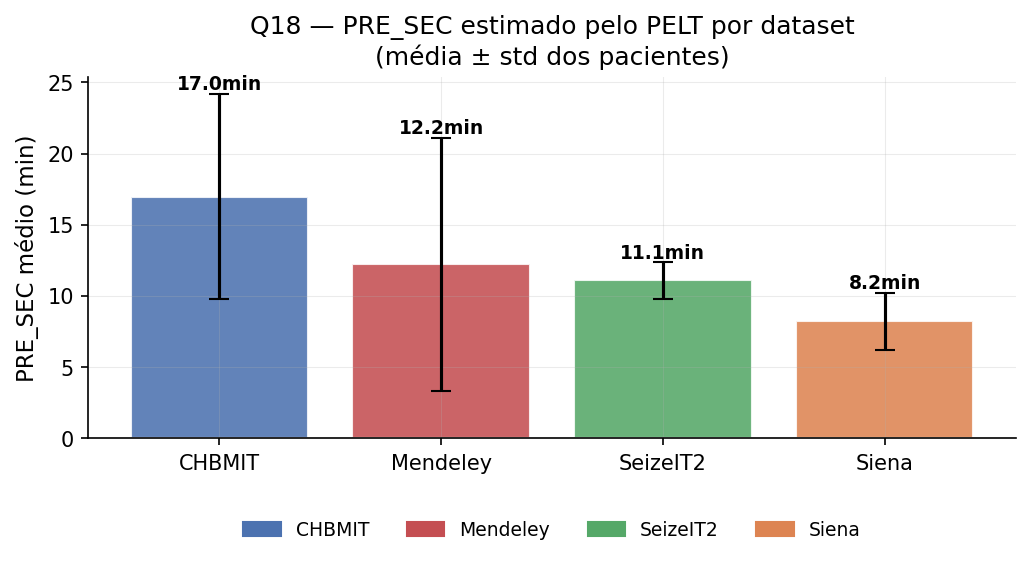

  -> q18_presec_dataset.png

Q18 — PRE_SEC por dataset
 dataset  Média (min)  Std
  CHBMIT        16.98 7.21
Mendeley        12.22 8.87
SeizeIT2        11.09 1.27
   Siena         8.22 2.01

Q18 — PRE_SEC por paciente
 dataset paciente  pre_sec_min
  CHBMIT    chb10          9.0
  CHBMIT    chb06         13.7
  CHBMIT    chb03         15.6
  CHBMIT    chb14         18.2
  CHBMIT    chb05         28.4
Mendeley      p11          6.0
Mendeley      p10         18.5
SeizeIT2  sub-034          9.1
SeizeIT2  sub-073          9.8
SeizeIT2  sub-047         11.0
SeizeIT2  sub-103         11.0
SeizeIT2  sub-002         12.2
SeizeIT2  sub-035         12.2
SeizeIT2  sub-039         12.2
   Siena     PN06          6.2
   Siena     PN10          7.2
   Siena     PN09          8.5
   Siena     PN14         10.9


In [81]:
if HAS_PRE:
    df18 = pd.DataFrame([{'dataset':k[0],'paciente':k[1],
                           'pre_sec_min':v['pre_sec']/60}
                          for k,v in pre_est.items()])
    agg18 = df18.groupby('dataset')['pre_sec_min'].agg(['mean','std'])
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(agg18.index, agg18['mean'], yerr=agg18['std'], capsize=5,
           color=[DC.get(d,'gray') for d in agg18.index], alpha=0.88, edgecolor='white')
    ax.set_ylabel('PRE_SEC médio (min)')
    ax.set_title('Q18 — PRE_SEC estimado pelo PELT por dataset\n(média ± std dos pacientes)')
    for i,(ds,row) in enumerate(agg18.iterrows()):
        ax.text(i, row['mean']+row['std']+0.3, f"{row['mean']:.1f}min",
                ha='center', fontsize=9, fontweight='bold')
    leg(ax,[mpatches.Patch(color=DC.get(d,'gray'),label=d) for d in agg18.index], ncol=4)
    fig.tight_layout(); savefig('q18_presec_dataset')
    ptab(agg18.rename(columns={'mean':'Média (min)','std':'Std'}).round(2).reset_index(),'Q18 — PRE_SEC por dataset')
    ptab(df18.sort_values(['dataset','pre_sec_min']).round(1),'Q18 — PRE_SEC por paciente')
else:
    print('preictal_estimate.json nao encontrado.')


## Q19 — Pacientes não-preditíveis (AUC ≈ 0.5)

Separado por dataset. Barras agrupadas: AUC e Sensibilidade. Regiões coloridas: <0.5 vermelho, 0.5–0.7 laranja, >0.7 verde.

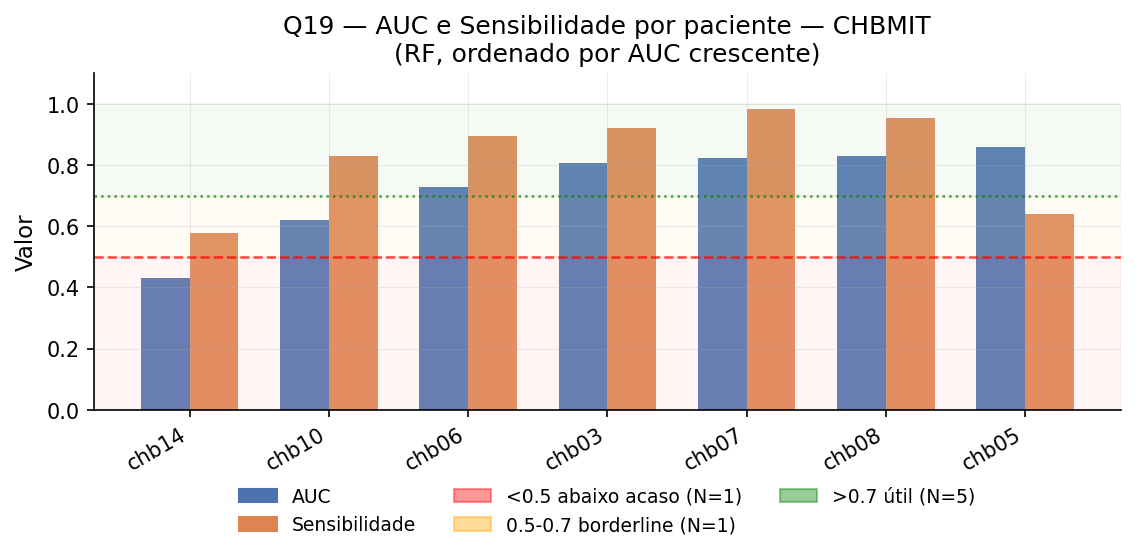

  -> q19_preditividade_CHBMIT.png

Q19 — CHBMIT
paciente   auc  sensitivity Categoria
   chb14 0.430        0.578      <0.5
   chb10 0.622        0.829   0.5-0.7
   chb06 0.727        0.896      >0.7
   chb03 0.807        0.921      >0.7
   chb07 0.823        0.983      >0.7
   chb08 0.830        0.954      >0.7
   chb05 0.858        0.641      >0.7


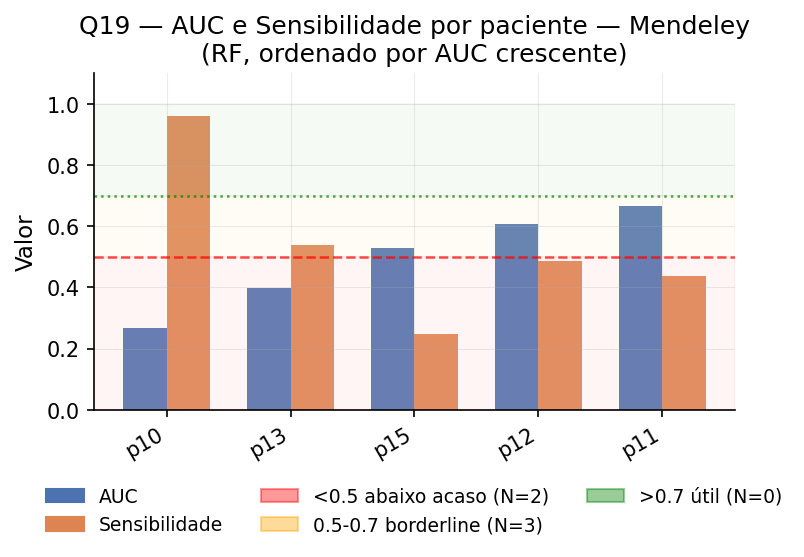

  -> q19_preditividade_Mendeley.png

Q19 — Mendeley
paciente   auc  sensitivity Categoria
     p10 0.268        0.962      <0.5
     p13 0.398        0.537      <0.5
     p15 0.528        0.247   0.5-0.7
     p12 0.607        0.487   0.5-0.7
     p11 0.665        0.438   0.5-0.7


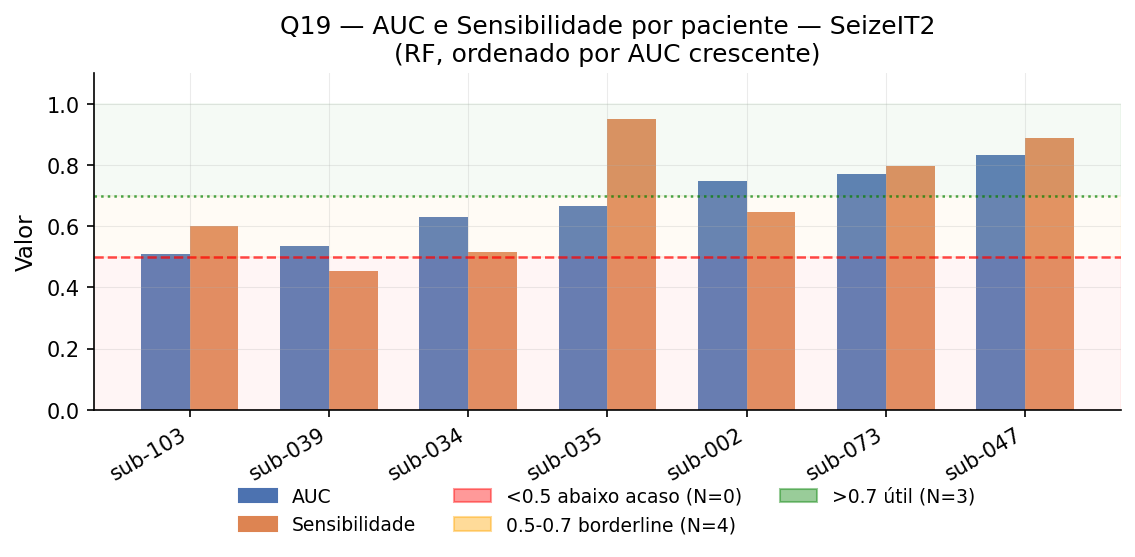

  -> q19_preditividade_SeizeIT2.png

Q19 — SeizeIT2
paciente   auc  sensitivity Categoria
 sub-103 0.510        0.601   0.5-0.7
 sub-039 0.534        0.453   0.5-0.7
 sub-034 0.630        0.514   0.5-0.7
 sub-035 0.666        0.951   0.5-0.7
 sub-002 0.749        0.648      >0.7
 sub-073 0.772        0.798      >0.7
 sub-047 0.833        0.888      >0.7


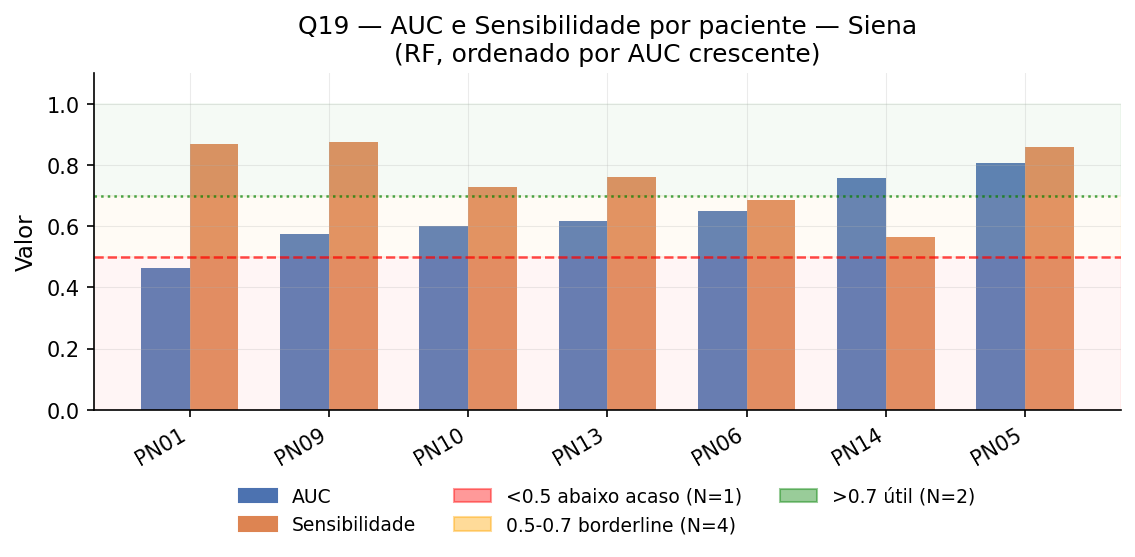

  -> q19_preditividade_Siena.png

Q19 — Siena
paciente   auc  sensitivity Categoria
    PN01 0.464        0.869      <0.5
    PN09 0.576        0.875   0.5-0.7
    PN10 0.601        0.727   0.5-0.7
    PN13 0.618        0.762   0.5-0.7
    PN06 0.649        0.686   0.5-0.7
    PN14 0.757        0.564      >0.7
    PN05 0.808        0.858      >0.7


In [82]:
auc_pp19  = s3_rf.groupby(['dataset','paciente'])['auc'].mean().reset_index()
sens_pp19 = s3_rf.groupby(['dataset','paciente'])['sensitivity'].mean().reset_index()
pp19 = auc_pp19.merge(sens_pp19, on=['dataset','paciente'])

for ds in sorted(pp19['dataset'].unique()):
    sub = pp19[pp19['dataset']==ds].sort_values('auc')
    pats = sub['paciente'].tolist()
    x19 = np.arange(len(pats)); w19 = 0.35
    fig, ax = plt.subplots(figsize=(max(5,len(pats)*1.1),4))
    ax.bar(x19-w19/2, sub['auc'].values,         w19, color='#4C72B0', alpha=0.88, label='AUC')
    ax.bar(x19+w19/2, sub['sensitivity'].values,  w19, color='#DD8452', alpha=0.88, label='Sensibilidade')
    ax.axhline(0.5, color='red',   lw=1.2, ls='--', alpha=0.7)
    ax.axhline(0.7, color='green', lw=1.2, ls=':',  alpha=0.7)
    ax.axhspan(0,   0.5, alpha=0.04, color='red')
    ax.axhspan(0.5, 0.7, alpha=0.04, color='orange')
    ax.axhspan(0.7, 1.0, alpha=0.04, color='green')
    ax.set_xticks(x19); ax.set_xticklabels(pats, rotation=30, ha='right')
    ax.set_ylim(0, 1.1); ax.set_ylabel('Valor')
    ax.set_title(f'Q19 — AUC e Sensibilidade por paciente — {ds}\n(RF, ordenado por AUC crescente)')
    n_ab = (sub['auc']<0.5).sum(); n_bo = ((sub['auc']>=0.5)&(sub['auc']<0.7)).sum()
    n_ut = (sub['auc']>=0.7).sum()
    handles19 = [
        mpatches.Patch(color='#4C72B0',label='AUC'),
        mpatches.Patch(color='#DD8452',label='Sensibilidade'),
        mpatches.Patch(color='red',alpha=0.4,   label=f'<0.5 abaixo acaso (N={n_ab})'),
        mpatches.Patch(color='orange',alpha=0.4, label=f'0.5-0.7 borderline (N={n_bo})'),
        mpatches.Patch(color='green',alpha=0.4,  label=f'>0.7 útil (N={n_ut})'),
    ]
    leg(ax, handles19, ncol=3)
    fig.tight_layout(); savefig(f'q19_preditividade_{ds}')
    t19 = sub[['paciente','auc','sensitivity']].round(3).copy()
    t19['Categoria'] = t19['auc'].apply(lambda v: '<0.5' if v<0.5 else ('0.5-0.7' if v<0.7 else '>0.7'))
    ptab(t19, 'Q19 — '+ds)


## Q20 — Degradação de canais afeta mais pacientes difíceis?

Um gráfico por dataset: queda AUC (R5−R0) por paciente, com linha do AUC em R5 sobreposta.

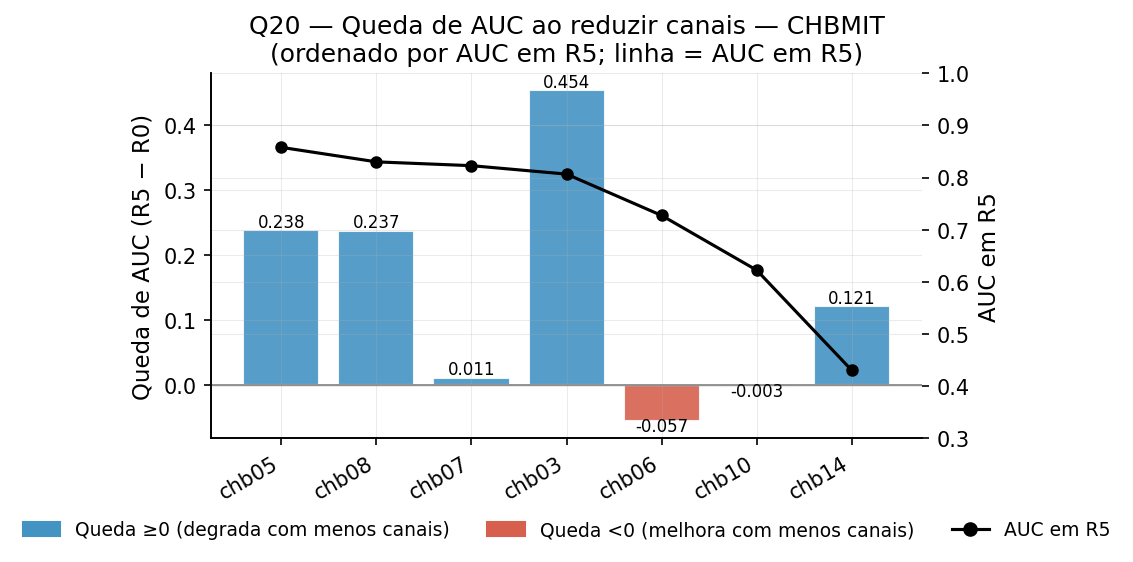

  -> q20_degradacao_CHBMIT.png

Q20 — CHBMIT
paciente  auc_r5  auc_r0  queda
   chb05   0.858   0.620  0.238
   chb08   0.830   0.593  0.237
   chb07   0.823   0.812  0.011
   chb03   0.807   0.352  0.454
   chb06   0.727   0.784 -0.057
   chb10   0.622   0.625 -0.003
   chb14   0.430   0.308  0.121


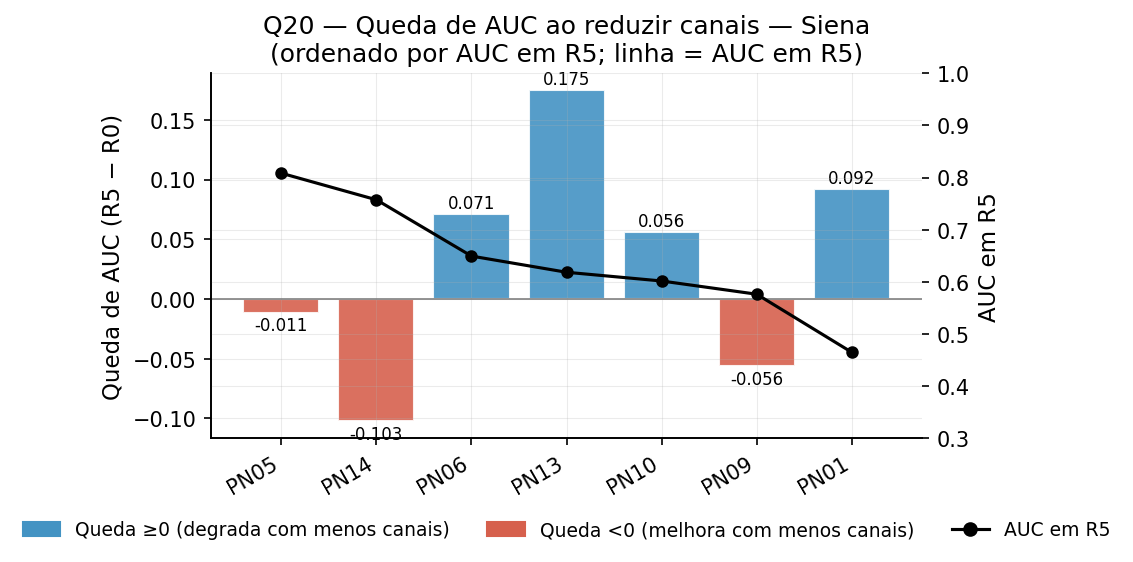

  -> q20_degradacao_Siena.png

Q20 — Siena
paciente  auc_r5  auc_r0  queda
    PN05   0.808   0.820 -0.011
    PN14   0.757   0.860 -0.103
    PN06   0.649   0.578  0.071
    PN13   0.618   0.443  0.175
    PN10   0.601   0.545  0.056
    PN09   0.576   0.632 -0.056
    PN01   0.464   0.373  0.092


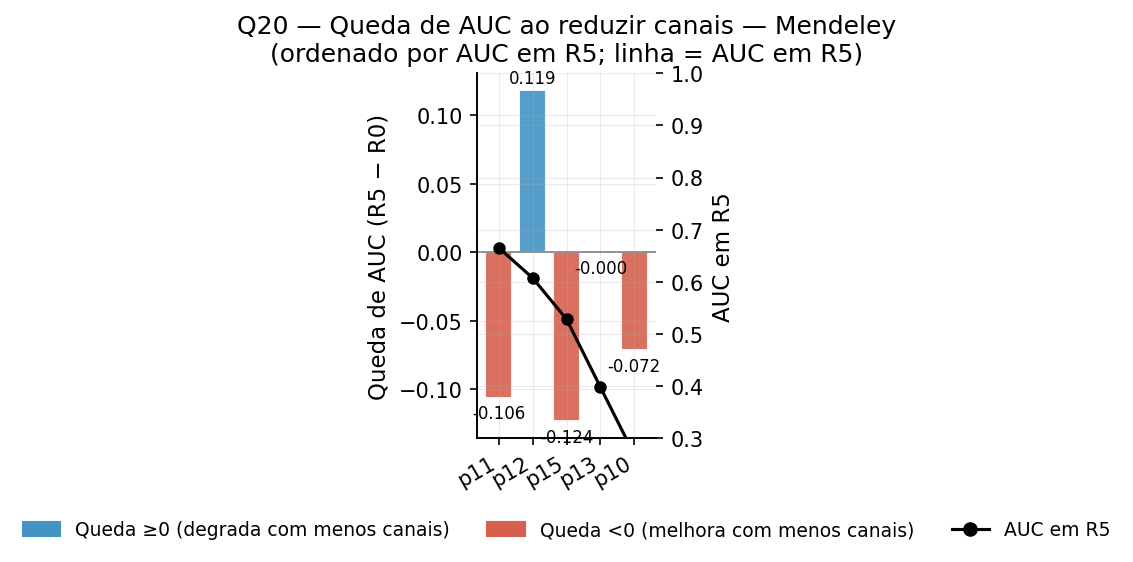

  -> q20_degradacao_Mendeley.png

Q20 — Mendeley
paciente  auc_r5  auc_r0  queda
     p11   0.665   0.771 -0.106
     p12   0.607   0.488  0.119
     p15   0.528   0.652 -0.124
     p13   0.398   0.398 -0.000
     p10   0.268   0.340 -0.072


In [83]:
for ds in CLINICAL:
    r5_pp = s2[(s2['dataset']==ds)&(s2['level']=='R5')].groupby('paciente')['auc'].mean()
    r0_pp = s2[(s2['dataset']==ds)&(s2['level']=='R0')].groupby('paciente')['auc'].mean()
    df20 = pd.DataFrame({'auc_r5':r5_pp,'auc_r0':r0_pp}).dropna()
    df20['queda'] = df20['auc_r5']-df20['auc_r0']
    df20 = df20.sort_values('auc_r5',ascending=False).reset_index()
    fig, ax = plt.subplots(figsize=(max(5,len(df20)*1.0),4))
    bar_colors = ['#4393c3' if q>=0 else '#d6604d' for q in df20['queda']]
    ax.bar(df20['paciente'], df20['queda'], color=bar_colors, alpha=0.9, edgecolor='white')
    ax.axhline(0, color='gray', lw=0.8)
    ax.set_ylabel('Queda de AUC (R5 − R0)')
    ax.set_title(f'Q20 — Queda de AUC ao reduzir canais — {ds}\n(ordenado por AUC em R5; linha = AUC em R5)')
    ax.set_xticklabels(df20['paciente'], rotation=30, ha='right')
    for bar,(_,row) in zip(ax.patches, df20.iterrows()):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+(0.005 if bar.get_height()>=0 else -0.015),
                f"{row['queda']:.3f}", ha='center', fontsize=8)
    ax2 = ax.twinx()
    ax2.plot(range(len(df20)), df20['auc_r5'].values, 'ko-', ms=5, lw=1.5, label='AUC em R5')
    ax2.set_ylabel('AUC em R5'); ax2.set_ylim(0.3,1.0)
    leg(ax,[mpatches.Patch(color='#4393c3',label='Queda ≥0 (degrada com menos canais)'),
            mpatches.Patch(color='#d6604d',label='Queda <0 (melhora com menos canais)'),
            plt.Line2D([0],[0],color='k',marker='o',label='AUC em R5')], ncol=3)
    fig.tight_layout(); savefig(f'q20_degradacao_{ds}')
    ptab(df20[['paciente','auc_r5','auc_r0','queda']].round(3),'Q20 — '+ds)


## Exportação de tabelas CSV para o TCC

In [84]:
tables = {}

# t1 — AUC por horizonte
tables['t1_horizontes.csv'] = s1.groupby('horizonte')['auc'].agg(
    ['mean','std','count']).reindex(H_ORDER).round(3).reset_index()

# t2 — AUC por nível (clínicos)
tables['t2_niveis_clinicos.csv'] = s2[s2['dataset'].isin(CLINICAL)].groupby(
    ['dataset','level'])['auc'].mean().unstack('level').round(3).reset_index()

# t3 — modelos global
tables['t3_modelos_global.csv'] = s3.groupby('model')[
    ['auc','sensitivity','specificity','fp_h']].mean().round(3).sort_values(
    'auc',ascending=False).reset_index()

# t4 — modelos x dataset
tables['t4_modelos_dataset.csv'] = s3.groupby(['dataset','model'])['auc'].mean(
    ).unstack('model').round(3).reset_index()

# t5 — por paciente (RF)
tables['t5_pacientes_rf.csv'] = s3_rf.groupby(['dataset','paciente'])[
    ['auc','sensitivity','specificity','fp_h']].mean().round(3).reset_index()

for fname, df_t in tables.items():
    p = OUT_DIR / fname
    df_t.to_csv(p, index=False)
    print(f'Salvo: {p.name}  ({len(df_t)} linhas)')

try:
    from google.colab import files
    for fn in tables:
        p = OUT_DIR / fn
        if p.exists(): files.download(str(p))
except ImportError:
    print(f'Tabelas em: {OUT_DIR.resolve()}')


Salvo: t1_horizontes.csv  (5 linhas)
Salvo: t2_niveis_clinicos.csv  (3 linhas)
Salvo: t3_modelos_global.csv  (9 linhas)
Salvo: t4_modelos_dataset.csv  (4 linhas)
Salvo: t5_pacientes_rf.csv  (26 linhas)
Tabelas em: D:\TCC\data\results
